# NHS Healthcare: Appointment, Utilisation and Capacity Analysis


## Andrew Willacy - August 2025

# Files & Datasets used in Analysis
**actual_duration.csv**\
Details of appointments made by patients. For example, the regional information, date, duration, and number of appointments pertaining to a certain class\
**appointments_regional.csv**\
Details on the type of appointments made by patients. For example, regional information, the month of appointment, appointment status, healthcare professional, appointment mode, the time between booking and the appointment, as well as the number of appointments pertaining to a certain class\
**national_categories.xlsx**\
Details of the national categories of appointments made by patients. For example, the regional information, date of appointment, service setting, type of context, national category, and the number of appointments pertaining to a certain class\
**tweets.csv**\
Data related to healthcare in the UK scraped from Twitter (X)\
**NHS-ICB_names.csv**\
Lists official NHS Integrated Care Board (ICB) names\
**sub_icb_boundaries_geojson.geojson**\
The geospatial data file that maps the geographic boundaries of Sub-Integrated Care Board (Sub-ICB) Locations within the National Health Service (NHS) in England

**Note:**
These files must be available in the operating directory for the notebook to run

# Index
**0. Business Context**\
**1. Import Python Libraries**\
**2. Import & Clean 'actual_duration.csv' Dataset**\
**3. Exploratory Data Analysis (EDA) - actual_duration**
>**3a Number of Appointments**\
**3b Appointment Duration**\
**Notes/Summary**

**4. Import & Clean 'appointments_regional.csv' Dataset**
>**4a Merge the 'appointments_regional dataset with NHS-ICB names**

**5. Exploratory Data Analysis (EDA) - appointments_regional**
>**5a Appointment modes: In person, telephone etc**\
**Notes/Summary**

**6. Import & Clean 'national_categories.csv' Dataset**\
**7. Exploratory Data Analysis (EDA) - National_categories**
>**7a Appointments by Month**\
**Notes/Summary**

**8. Exploratory Data Analysis (EDA) - All Datasets**
>**8a How many locations are there in the datasets**\
**8b What are the five locations with the highest number of appointments**\
**8c Reviewing service settings, context types, national categories, and appointment status**\
**8d GP Appointments by Mode**\
**8e Time to Wait for Appointment - Time from booking to actual appointment**\
**8f Appointment Duration**\
**Notes/Summary**

**9. Further Exploratory Data Analysis - All Datasets**
>**9a What is the time period of the analysis - using 'actual_duration' and 'national_categories' Datasets**\
**9b Which service setting was used the most in the NHS North West London from 1 January to 1 June 2022**\
**9c Service Setting by month - All national categories**\
**9d Total Appointments by Month**\
**9e Records per month count**

**10. Health Care Provider HCP Analysis - Who provides the medical care**
>**10a Number of Appointments by HCP**\
**Notes/Summary**

**11. Daily / Monthly Trends**
>**11a Appointment Count by Month**\
**11b Appointment Count by National Category - August 2021 -June 2022**\
**11c Daily Appointment Count by Date - August 2021 -June 2022 - All Settings**\
**11d Appointment Count per Month by Service Setting**\
**11e Appointment Count per Month by Service Setting - GP Removed**\
**11f Appointment Distribution by Service Setting**\
**11g Context Type: Number of Monthly Appoitments**\
**11h National Categoies: Number of Monthly / Daily Appointments**\
**11i Number of Appointments by ICB Location**\
**11j Monthly Appointments by Wait Time - Jan 2020 - June 2022 - COVID period**

**12. Capacity Trends**
>**12a Which days tend to have the  highest number of appointments**\
**12b Which days tend to have the  highest number of appointments - How does this compare to capacity of 1.2M per day**\
**12c Appointments by Each Individual Day for the period**\
**12d Appointment Wait Time by Month**

**13 Seasonal Trends**
>**13a Summer: June to August**\
**13b Autumn: September to November**\
**13c Autum: September to November - GP Removed**\
**13d Winter: December to February**\
**13e Spring: March to May**

**14. Appointments by Mode - In person, telephone etc**
>**14a Appointments by mode: Face to face and Telephone Only**

**15. Appointments: Non attendance**
>**15a Total monthly Appointments by Attendance Status**\
**15b Missed Appointments by Wait Time - % of Booked Appointments**\
**15c Missed Appointments by Wait Time - Analysis over the time period of the data**\
**15d Missed Appointments by Service Setting**\
**15e Missed Appointments by Sub-ICB Region**\
**15f Missed Appointments by Sub-ICB Region: Geographic**\
**Notes/Summary**

**16. Can Social Meida Help in Understanding Sentiment around the NHS**
>**16a Load the 'tweets.csv' file to analyse Social Media - Twitter (X) Data**\
**16b Do Retweets and Favourite tweets inparticular provide insights**\
**16c How often are tweets retweeted**\
**16d How often are tweets liked**\
**16e The top trending Hashtags in the Dataset**\
**Summary/Notes**

**17. Capacity & Utilisation**
>**17a Filtering the dataset**\
**17b Capacity & Utilisation Analysis - Appointments by month**\
**17c Capacity & Utilisation Analysis - Utilisation by Month**\
**17d Capacity & Utilisation Analysis - Days where capacity is breached**\
**17e Capacity & Utilisation Analysis - Appointments, Capacity & Utilisation**\
**17f Capacity & Utilisation Analysis - HCP Trends**

**18. Core Analytical Findings & Business Recommendations**
>**Finding 1: Operational Demand Continued to Increase**\
**Finding 2: Data Quality Issues Limited Operational Insight**\
**Finding 3: Missed Appointments Represented Significant Operational Waste**\
**Finding 4: Capacity Reporting Did Not Reflect Real Operational Conditions**\
**Finding 5: Social Media Could Support Public Engagement Analysis**

**19. Core Analytical Findings & Resource Utilisation**
>**19.1 Was there adequate staff and capacity in the networks**\
**19.2 What was the actual utilisation of resources**\
**19.3 What insights can be gained by looking at missed appointments**

**20. Executive Conclusion**
>**20.1 A System Operating Beyond Structural Capacity**\
**20.2 Key Patterns Visible in the Data**\
**20.3 Strategic Recommendations for the NHS**



# 0. Business Context
The NHS faces increasing demand against constrained resources. With an ageing population and post-Covid recovery pressures, understanding how capacity is being used - and where appointments are being missed - is essential for budget planning and infrastructure decisions.

**Healthcare stakeholders need to better understand:**

* Whether current staffing and network capacity were sufficient
* How healthcare resources were actually being utilised
* Where operational bottlenecks and inefficiencies existed
* What trends could be identified in missed appointments
* Whether external data sources such as social media could support operational insight and public engagement

### **The NHS have posed two questions:**
>1, Has there been adequate staff & capacity in the networks?\
2. What was the actual utilisation of resources?

# 1. Import Python Libaries

In [1]:
# Import the necessary libraries.
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.patheffects as path_effects
import seaborn as sns
import pandas as pd
import numpy as np
import re
import geopandas as gpd
from shapely.geometry import Point

# Ignore warnings.

import warnings
warnings.filterwarnings('ignore')

# 2. Import & Clean 'actual_duration.csv' Dataset

#### Import actual_duration.csv file , view & describe dataframe

In [2]:
# Import and sense-check the actual_duration.csv data set as dataframe ad.
ad = pd.read_csv('actual_duration.csv')

# View the DataFrame.
# Print the shape and columns of the Ad dataframe
print(ad.shape)
print(ad.columns)

(137793, 8)
Index(['sub_icb_location_code', 'sub_icb_location_ons_code',
       'sub_icb_location_name', 'icb_ons_code', 'region_ons_code',
       'appointment_date', 'actual_duration', 'count_of_appointments'],
      dtype='object')


In [3]:
# Determine whether there are missing values.
# There are 137,793 rows with no nulls
print(ad.info())

# Can also use:
ad.isna().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 137793 entries, 0 to 137792
Data columns (total 8 columns):
 #   Column                     Non-Null Count   Dtype 
---  ------                     --------------   ----- 
 0   sub_icb_location_code      137793 non-null  object
 1   sub_icb_location_ons_code  137793 non-null  object
 2   sub_icb_location_name      137793 non-null  object
 3   icb_ons_code               137793 non-null  object
 4   region_ons_code            137793 non-null  object
 5   appointment_date           137793 non-null  object
 6   actual_duration            137793 non-null  object
 7   count_of_appointments      137793 non-null  int64 
dtypes: int64(1), object(7)
memory usage: 8.4+ MB
None


sub_icb_location_code        0
sub_icb_location_ons_code    0
sub_icb_location_name        0
icb_ons_code                 0
region_ons_code              0
appointment_date             0
actual_duration              0
count_of_appointments        0
dtype: int64

In [4]:
# Using the head() function to return the first 5 rows of the dataset to sense check
ad.head()

,sub_icb_location_code,sub_icb_location_ons_code,sub_icb_location_name,icb_ons_code,region_ons_code,appointment_date,actual_duration,count_of_appointments
0,00L,E38000130,NHS North East and North Cumbria ICB - 00L,E54000050,E40000012,01-Dec-21,31-60 Minutes,364
1,00L,E38000130,NHS North East and North Cumbria ICB - 00L,E54000050,E40000012,01-Dec-21,21-30 Minutes,619
2,00L,E38000130,NHS North East and North Cumbria ICB - 00L,E54000050,E40000012,01-Dec-21,6-10 Minutes,1698
3,00L,E38000130,NHS North East and North Cumbria ICB - 00L,E54000050,E40000012,01-Dec-21,Unknown / Data Quality,1277
4,00L,E38000130,NHS North East and North Cumbria ICB - 00L,E54000050,E40000012,01-Dec-21,16-20 Minutes,730


In [5]:
# Using the tail() function to return the last 5 rows of the dataset
ad.tail()

,sub_icb_location_code,sub_icb_location_ons_code,sub_icb_location_name,icb_ons_code,region_ons_code,appointment_date,actual_duration,count_of_appointments
137788,X2C4Y,E38000254,NHS West Yorkshire ICB - X2C4Y,E54000054,E40000012,30-Jun-22,31-60 Minutes,430
137789,X2C4Y,E38000254,NHS West Yorkshire ICB - X2C4Y,E54000054,E40000012,30-Jun-22,21-30 Minutes,751
137790,X2C4Y,E38000254,NHS West Yorkshire ICB - X2C4Y,E54000054,E40000012,30-Jun-22,16-20 Minutes,921
137791,X2C4Y,E38000254,NHS West Yorkshire ICB - X2C4Y,E54000054,E40000012,30-Jun-22,11-15 Minutes,1439
137792,X2C4Y,E38000254,NHS West Yorkshire ICB - X2C4Y,E54000054,E40000012,30-Jun-22,1-5 Minutes,1739


In [6]:
# Determine the metadata of the data set.
ad.dtypes

sub_icb_location_code        object
sub_icb_location_ons_code    object
sub_icb_location_name        object
icb_ons_code                 object
region_ons_code              object
appointment_date             object
actual_duration              object
count_of_appointments         int64
dtype: object

In [7]:
# Determine the descriptive statistics of the data set - The 'round()' creates an integer rather than sa decimal figure
print(ad.describe().round())

       count_of_appointments
count               137793.0
mean                  1219.0
std                   1547.0
min                      1.0
25%                    194.0
50%                    696.0
75%                   1621.0
max                  15400.0


In [8]:
# Check for duplicate rows in the dataset
print("Number of duplicate records in ad:",ad.duplicated().sum())

Number of duplicate records in ad: 0


#### No duplicate records or Null values found - Dataset clean and ready for analysis

# 3. Exploratory Data Analysis (EDA) - actual_duration
A first look at the dataset to gather initial insights

## 3a Number of Appointments

In [9]:
# This shows the total appointments per region from highest to lowest by icb location name
groupby_icb_ad = ad.groupby('sub_icb_location_name')['count_of_appointments'].sum()

groupby_icb_ad.sort_values(ascending=False)

sub_icb_location_name
NHS North West London ICB - W2U3Z              6976986
NHS North East London ICB - A3A8R              5341883
NHS Kent and Medway ICB - 91Q                  5209641
NHS Hampshire and Isle Of Wight ICB - D9Y0V    4712737
NHS South East London ICB - 72Q                4360079
                                                ...   
NHS Greater Manchester ICB - 00V                362242
NHS Cheshire and Merseyside ICB - 01V           358060
NHS Cheshire and Merseyside ICB - 01F           348396
NHS Cheshire and Merseyside ICB - 01T           340895
NHS Lancashire and South Cumbria ICB - 02G      311713
Name: count_of_appointments, Length: 106, dtype: int64

## 3b Appointment Duration

In [10]:
# List all unique values for appointment_duration
ad['actual_duration'].unique()

array(['31-60 Minutes', '21-30 Minutes', '6-10 Minutes',
       'Unknown / Data Quality', '16-20 Minutes', '11-15 Minutes',
       '1-5 Minutes'], dtype=object)

In [11]:
# Calculate the total numbert of appointments by duration
duration_counts = ad.groupby('actual_duration')['count_of_appointments'].sum()
duration_counts.sort_values(ascending=False)


actual_duration
Unknown / Data Quality    40284086
6-10 Minutes              33800815
1-5 Minutes               28600865
11-15 Minutes             25160882
16-20 Minutes             16004247
21-30 Minutes             15026365
31-60 Minutes              9103432
Name: count_of_appointments, dtype: int64

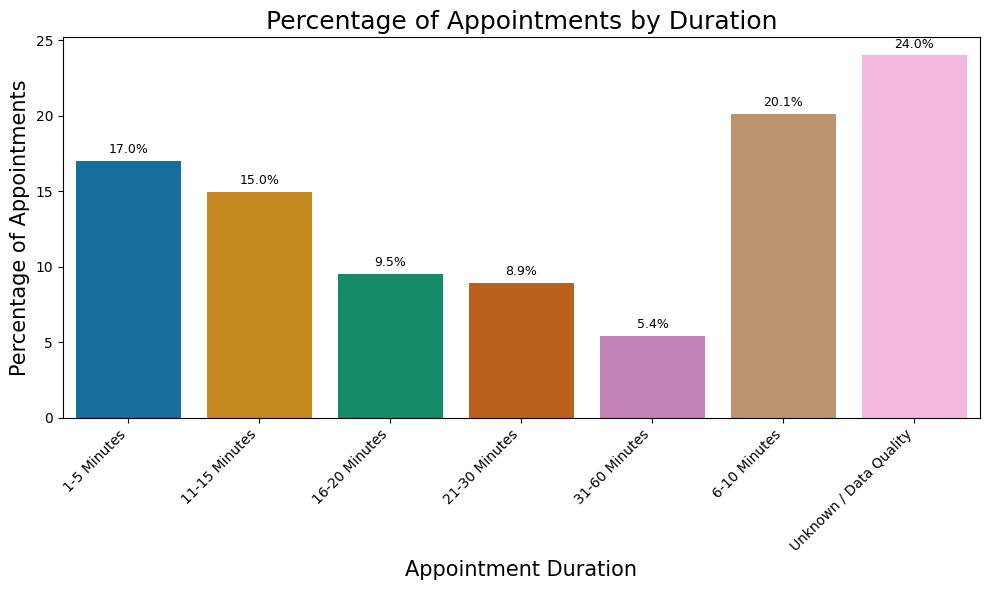

In [12]:
# Create barplot of appointment duration by % of appointments
# Convert Series to DataFrame if needed
if isinstance(duration_counts, pd.Series):
    duration_counts = duration_counts.reset_index()
    duration_counts.columns = ['actual_duration', 'Appointment count']

# Calculate percentages
total = duration_counts['Appointment count'].sum()
duration_counts['Percentage'] = (duration_counts['Appointment count'] / total) * 100

# Plot graph
plt.figure(figsize=(10, 6))
ax = sns.barplot(
    data=duration_counts, 
    x='actual_duration', 
    y='Percentage', 
    palette='colorblind'
)

# Annotate each bar with percentage
for i, row in duration_counts.iterrows():
    ax.text(i, row['Percentage'] + 0.5, f"{row['Percentage']:.1f}%", ha='center', fontsize=9)

# Title, labels
plt.title('Percentage of Appointments by Duration', fontsize=18)
plt.xlabel('Appointment Duration', fontsize=15)
plt.ylabel('Percentage of Appointments', fontsize=15)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


## Notes/Summary

Shape shows there are 137,793 rows and 8 columns with no nan values
The column names are:
'sub_icb_location_code', 'sub_icb_location_ons_code', 'sub_icb_location_name', 'icb_ons_code', 'region_ons_code',
       'appointment_date', 'actual_duration', 'count_of_appointments'

Sense checking of the dataframe confirms there is no mnetadata in the last row
There are no duplocates in the data so the data is ready to go

We can see that unknown/data quality makes up thye highest number of records counted for the 'actual_duration' of the appointments.
This is an issue as it shows the data already has quality issues.
1-5 minute duration is has the highest count of appointments with 31-60 coming in as the lowest. This is probably to be expected
although where appointment duration has been recorded the different durations are fairly similar

# 4. Import & Clean 'appointments_regional.csv' Dataset


In [13]:
# Import and sense-check the appointments_regional.csv data set as ar.
ar = pd.read_csv('appointments_regional.csv')

# View the DataFrame.
print(ar.shape)

# Print the columns
print(ar.columns)



(596821, 7)
Index(['icb_ons_code', 'appointment_month', 'appointment_status', 'hcp_type',
       'appointment_mode', 'time_between_book_and_appointment',
       'count_of_appointments'],
      dtype='object')


In [14]:
# Using the head() function to return the first 5 rows of the dataset to sense check
ar.head()

,icb_ons_code,appointment_month,appointment_status,hcp_type,appointment_mode,time_between_book_and_appointment,count_of_appointments
0,E54000034,2020-01,Attended,GP,Face-to-Face,1 Day,8107
1,E54000034,2020-01,Attended,GP,Face-to-Face,15 to 21 Days,6791
2,E54000034,2020-01,Attended,GP,Face-to-Face,2 to 7 Days,20686
3,E54000034,2020-01,Attended,GP,Face-to-Face,22 to 28 Days,4268
4,E54000034,2020-01,Attended,GP,Face-to-Face,8 to 14 Days,11971


In [15]:
# Using the tail() function to return the last 5 rpws of the dataset to sense check
ar.tail()

,icb_ons_code,appointment_month,appointment_status,hcp_type,appointment_mode,time_between_book_and_appointment,count_of_appointments
596816,E54000050,2022-06,Unknown,Unknown,Unknown,2 to 7 Days,21
596817,E54000050,2022-06,Unknown,Unknown,Unknown,22 to 28 Days,8
596818,E54000050,2022-06,Unknown,Unknown,Unknown,8 to 14 Days,28
596819,E54000050,2022-06,Unknown,Unknown,Unknown,More than 28 Days,17
596820,E54000050,2022-06,Unknown,Unknown,Unknown,Same Day,10


In [16]:
# Determine whether there are missing values.
print(ar.info())

# Can also use
ar.isna().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 596821 entries, 0 to 596820
Data columns (total 7 columns):
 #   Column                             Non-Null Count   Dtype 
---  ------                             --------------   ----- 
 0   icb_ons_code                       596821 non-null  object
 1   appointment_month                  596821 non-null  object
 2   appointment_status                 596821 non-null  object
 3   hcp_type                           596821 non-null  object
 4   appointment_mode                   596821 non-null  object
 5   time_between_book_and_appointment  596821 non-null  object
 6   count_of_appointments              596821 non-null  int64 
dtypes: int64(1), object(6)
memory usage: 31.9+ MB
None


icb_ons_code                         0
appointment_month                    0
appointment_status                   0
hcp_type                             0
appointment_mode                     0
time_between_book_and_appointment    0
count_of_appointments                0
dtype: int64

In [17]:
# Determine the metadata of the data set.
ar.dtypes

icb_ons_code                         object
appointment_month                    object
appointment_status                   object
hcp_type                             object
appointment_mode                     object
time_between_book_and_appointment    object
count_of_appointments                 int64
dtype: object

In [18]:
# Determine the descriptive statistics of the data set.
# round(2) rounds the figure to two decimal places
ar.describe().round(2)

,count_of_appointments
count,596821.00
mean,1244.60
std,5856.89
min,1.00
25%,7.00
50%,47.00
75%,308.00
max,211265.00


In [19]:
# Check for duplicate rows in thed dataset
print("Number of duplicate records in ar:",ar.duplicated().sum())

Number of duplicate records in ar: 21604


In [20]:
# Duplictes being removed and new dataframe ar_dupl made
ar_dupl = ar.drop_duplicates()

# Confirming the removal of duplicate entries
ar_dupl.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 575217 entries, 0 to 596819
Data columns (total 7 columns):
 #   Column                             Non-Null Count   Dtype 
---  ------                             --------------   ----- 
 0   icb_ons_code                       575217 non-null  object
 1   appointment_month                  575217 non-null  object
 2   appointment_status                 575217 non-null  object
 3   hcp_type                           575217 non-null  object
 4   appointment_mode                   575217 non-null  object
 5   time_between_book_and_appointment  575217 non-null  object
 6   count_of_appointments              575217 non-null  int64 
dtypes: int64(1), object(6)
memory usage: 35.1+ MB


#### 21604 Duplicates removed and no null values found - Dataset clean and ready for analysis

## 4a Merge the appointments_regional dataset with NHS-ICB names

#### For ease of use, and clarity the file NHS_ICB_names was downloaded from the NHS website and merged with ar.csv by 'icb_ons_code'. Instead of just code numbers this will give the actual ICB names making analysis easier.

In [21]:
# Merge ad with NHS-ICB_names to add columns for icb_name and region_names
# This file was downloaded form NHS website to add region names to the ar dataset as it may make analysis easier later
# Merged using a left join by 'icb_ons_code'
nhs_names = pd.read_csv('NHS-ICB_names.csv')
ar_merged = pd.merge(ar_dupl, nhs_names[['icb_ons_code','code', 'name', 'region_no']], how='left', on='icb_ons_code')

# The resulting merged dataframe ar_merged
ar_merged.head()


,icb_ons_code,appointment_month,appointment_status,hcp_type,appointment_mode,time_between_book_and_appointment,count_of_appointments,code,name,region_no
0,E54000034,2020-01,Attended,GP,Face-to-Face,1 Day,8107,QNQ,NHS Frimley Integrated Care Board,19.0
1,E54000034,2020-01,Attended,GP,Face-to-Face,15 to 21 Days,6791,QNQ,NHS Frimley Integrated Care Board,19.0
2,E54000034,2020-01,Attended,GP,Face-to-Face,2 to 7 Days,20686,QNQ,NHS Frimley Integrated Care Board,19.0
3,E54000034,2020-01,Attended,GP,Face-to-Face,22 to 28 Days,4268,QNQ,NHS Frimley Integrated Care Board,19.0
4,E54000034,2020-01,Attended,GP,Face-to-Face,8 to 14 Days,11971,QNQ,NHS Frimley Integrated Care Board,19.0


In [22]:
# Check for duplicates in ar_merged dataset
print("Number of duplicate records in ar_merged:",ar_merged.duplicated().sum())

Number of duplicate records in ar_merged: 0


# 5. Exploratory Data Analysis (EDA) - appointments_regional
A first look at the dataset to gather initial insights

## 5a Appointment modes (In person ,telephone etc)

Appointment Mode Counts (in millions):

Appointment Mode  Appointment Count (Millions)
    Face-to-Face                       176.411
       Telephone                       161.225
      Home Visit                       102.909
         Unknown                        77.918
    Video/Online                        56.754


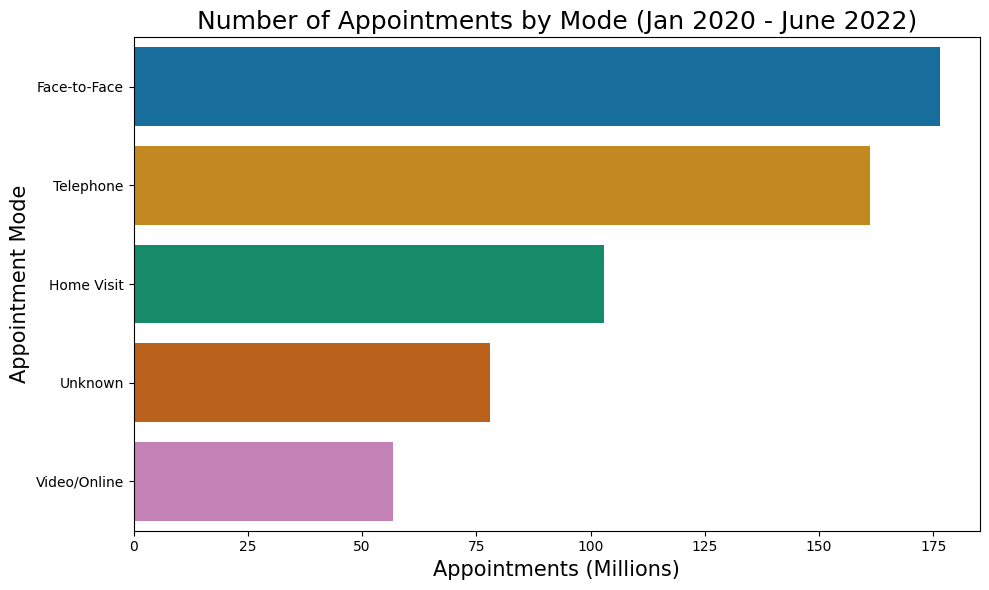

In [23]:
# Count appointment modes & plot
duration_counts = ar_merged['appointment_mode'].value_counts().reset_index()
duration_counts.columns = ['Appointment Mode', 'Appointment Count']

# Convert to millions
duration_counts['Appointment Count (Millions)'] = duration_counts['Appointment Count'] / 1000

# Sort for better visual order
duration_counts = duration_counts.sort_values(by='Appointment Count (Millions)', ascending=False)

# Print table
print("Appointment Mode Counts (in millions):\n")
print(duration_counts[['Appointment Mode', 'Appointment Count (Millions)']].to_string(index=False))

# Plot horizontal bar chart
plt.figure(figsize=(10, 6))
ax = sns.barplot(data=duration_counts,
    x='Appointment Count (Millions)', 
    y='Appointment Mode', 
    palette='colorblind'
)

plt.title('Number of Appointments by Mode (Jan 2020 - June 2022)', fontsize=18)
plt.xlabel('Appointments (Millions)', fontsize=15)
plt.ylabel('Appointment Mode', fontsize=15)
plt.tight_layout()
plt.show()


In [24]:
print("Total number of appointments in ar:",ar_merged['count_of_appointments'].sum())

Total number of appointments in ar: 742529759


## Notes/Summary

Shape shows there are 596.821 rows and 7 columns

The column names are:
'icb_ons_code', 'appointment_month', 'appointment_status', 'hcp_type', 'appointment_mode', 'time_between_book_and_appointment',
       'count_of_appointments'

Sense checking of the dataframe confirms there is no mnetadata in the last row. 
There are 21604 duplocates in the data. I was intwo minds whether or not to remove or leave these. I decided to remove them and have a clean dataset. 

There are 596821 appointments recorded in the dataset
NHS ICB names downloaded from a third party into a datframe called 'NHS-ICB_names.csv' and a dataframe called 'nhs_names' made containing this file

The 'ar_dupl' was then merged with 'nhs_names' into anew dataframe called 'ar_merged'

A count of the appouintment mode (eg face to face, telephone etc) was made and a bar graph plotted. Face to face made up the highest count., but telephone wasn't far behind. Telephone appointments increased during the covid pandemic, a period covered by the data in this analysis (January 2020 - June 2022)

Appointment Mode  Appointment Count
    Face-to-Face             176411
       Telephone             161225
      Home Visit             102909
         Unknown              77918
    Video/Online              56754

The total number of appointments in the dataset is 742529759

# 6. Import & Clean 'national_categories.csv' Dataset

The original Excel file was converted to ,csv file for ease of use and consistency across all data

In [25]:
# Import and sense-check the national_categories.xlsx data set as nc.
# This dataset was changed to a .csv file In Excel to maintain unifromity across all the datasets by file type
# and avoid any potential conflict issues
nc = pd.read_csv('national_categories.csv')

# View the DataFrame.
print(nc.shape)

# Print the columns
print(nc.columns)


(817394, 8)
Index(['appointment_date', 'icb_ons_code', 'sub_icb_location_name',
       'service_setting', 'context_type', 'national_category',
       'count_of_appointments', 'appointment_month'],
      dtype='object')


In [26]:
nc.head()

,appointment_date,icb_ons_code,sub_icb_location_name,service_setting,context_type,national_category,count_of_appointments,appointment_month
0,02/08/2021,E54000050,NHS North East and North Cumbria ICB - 00L,Primary Care Network,Care Related Encounter,Patient contact during Care Home Round,3,2021-08
1,02/08/2021,E54000050,NHS North East and North Cumbria ICB - 00L,Other,Care Related Encounter,Planned Clinics,7,2021-08
2,02/08/2021,E54000050,NHS North East and North Cumbria ICB - 00L,General Practice,Care Related Encounter,Home Visit,79,2021-08
3,02/08/2021,E54000050,NHS North East and North Cumbria ICB - 00L,General Practice,Care Related Encounter,General Consultation Acute,725,2021-08
4,02/08/2021,E54000050,NHS North East and North Cumbria ICB - 00L,General Practice,Care Related Encounter,Structured Medication Review,2,2021-08


In [27]:
nc.tail()

,appointment_date,icb_ons_code,sub_icb_location_name,service_setting,context_type,national_category,count_of_appointments,appointment_month
817389,30/06/2022,E54000054,NHS West Yorkshire ICB - X2C4Y,Extended Access Provision,Care Related Encounter,Unplanned Clinical Activity,12,2022-06
817390,30/06/2022,E54000054,NHS West Yorkshire ICB - X2C4Y,Extended Access Provision,Care Related Encounter,Planned Clinics,4,2022-06
817391,30/06/2022,E54000054,NHS West Yorkshire ICB - X2C4Y,Extended Access Provision,Care Related Encounter,Planned Clinical Procedure,92,2022-06
817392,30/06/2022,E54000054,NHS West Yorkshire ICB - X2C4Y,Extended Access Provision,Care Related Encounter,General Consultation Routine,4,2022-06
817393,30/06/2022,E54000054,NHS West Yorkshire ICB - X2C4Y,Extended Access Provision,Care Related Encounter,General Consultation Acute,19,2022-06


In [28]:
# Determine whether there are missing values.
nc.info()

#  alternatively use
nc.isna().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 817394 entries, 0 to 817393
Data columns (total 8 columns):
 #   Column                 Non-Null Count   Dtype 
---  ------                 --------------   ----- 
 0   appointment_date       817394 non-null  object
 1   icb_ons_code           817394 non-null  object
 2   sub_icb_location_name  817394 non-null  object
 3   service_setting        817394 non-null  object
 4   context_type           817394 non-null  object
 5   national_category      817394 non-null  object
 6   count_of_appointments  817394 non-null  int64 
 7   appointment_month      817394 non-null  object
dtypes: int64(1), object(7)
memory usage: 49.9+ MB


appointment_date         0
icb_ons_code             0
sub_icb_location_name    0
service_setting          0
context_type             0
national_category        0
count_of_appointments    0
appointment_month        0
dtype: int64

In [29]:
# Determine the metadata of the data set.
nc.dtypes

appointment_date         object
icb_ons_code             object
sub_icb_location_name    object
service_setting          object
context_type             object
national_category        object
count_of_appointments     int64
appointment_month        object
dtype: object

In [30]:
# Determine the descriptive statistics of the data set.
nc.describe()

,count_of_appointments
count,817394.000000
mean,362.183684
std,1084.576600
min,1.000000
25%,7.000000
50%,25.000000
75%,128.000000
max,16590.000000


In [31]:
# There are no duplicate records in national_categories:
print("Number of duplicate records in nc:",nc.duplicated().sum())

Number of duplicate records in nc: 0


#### No duplicates or null values found - Dataset clean and ready for analysis

# 7. Exploratory Data Analysis (EDA) - National_categories
A first look at the dataset to gather initial insights

## 7a Appointments by Month

In [32]:
# Which month had the highest number of appointments?

# Group by month and sum the appointments
month_count = nc.groupby('appointment_month')['count_of_appointments'].sum().reset_index()

# Sort the result to find the month with the highest number of appointments
month_count_sorted = month_count.sort_values(by='count_of_appointments', ascending=False).reset_index(drop=True)

# Set the index to start at 1
month_count_sorted.index = range(1, len(month_count_sorted) + 1)

# Display the sorted DataFrame
print("Appointments by Month (Descending):")
print(month_count_sorted)

# Print the total number of appointments across all months
total_appointments = month_count['count_of_appointments'].sum()
print(f"\nTotal number of appointments: {total_appointments:,}")



Appointments by Month (Descending):
   appointment_month  count_of_appointments
1            2021-11               30405070
2            2021-10               30303834
3            2022-03               29595038
4            2021-09               28522501
5            2022-05               27495508
6            2022-06               25828078
7            2022-01               25635474
8            2022-02               25355260
9            2021-12               25140776
10           2022-04               23913060
11           2021-08               23852171

Total number of appointments: 296,046,770


## Notes/Summary

Shape shows there are 817394 rows and 8 columns in the dataset 

The column names are:
'appointment_date', 'icb_ons_code', 'sub_icb_location_name', 'service_setting', 'context_type', 'national_category',
       'count_of_appointments', 'appointment_month'
       
Sense checking of the dataframe confirms there is no mnetadata in the last row. There are no duplocates or nan values in the data, so its ready to go.

November 2021 had the highest number of appopintment at 30,405,070
August 2021 had the lowest number of appointments at 23,852,171

#### All datasets were renamed with suffix '*_clean' to signify the dataset has been cleaned and redy for use

In [33]:
# Renaming all datasets in a uniform way to ease identification and uniformity after cleaning
ar_clean = ar_merged
ad_clean = ad
nc_clean = nc

# 8. Exploratory Data Analysis (EDA) - All Datasets 

Looking at some exploratory data analysis to get a feel for the data and answering some questions

## 8a How many locations are there in the datasets?

In [34]:
# Determine the number of locations.
# Using nunique to return a value rather than a list
print("Number of locations:", nc['sub_icb_location_name'].nunique())
print("Number of ICB locations:",ad['icb_ons_code'].nunique())
print("Number of regions:",ad['region_ons_code'].nunique())

Number of locations: 106
Number of ICB locations: 42
Number of regions: 7


## 8b What are the five locations with the highest number of appointments?

In [35]:
# Top 5 Sub ICB locations based on the number of appointments from nc_clean
top_five_locs_nc = nc_clean.groupby('sub_icb_location_name')[['count_of_appointments']]\
        .sum().sort_values('count_of_appointments', ascending=False).head()\
        .reset_index()\
        .rename(columns={'sub_icb_location_name':'Sub ICB Location', 'count_of_appointments':'Total Appointments'})

# Calculate and print the sum of appointments in nc_clean
total_nc = nc_clean['count_of_appointments'].sum()
print(f"Total appointments in nc:{total_nc}")

# Calculating the total number of appointments for each of the top 5 sub ICB locations as a % of the total 
# all Sub ICB locations in top_five_locs_nc
top_five_locs_nc['% of Total'] = top_five_locs_nc['Total Appointments']/total_nc * 100

# Round to 1 decimal place
top_five_locs_nc.round(1)

Total appointments in nc:296046770


,Sub ICB Location,Total Appointments,% of Total
0,NHS North West London ICB - W2U3Z,12142390,4.1
1,NHS North East London ICB - A3A8R,9588891,3.2
2,NHS Kent and Medway ICB - 91Q,9286167,3.1
3,NHS Hampshire and Isle Of Wight ICB - D9Y0V,8288102,2.8
4,NHS South East London ICB - 72Q,7850170,2.7


In [36]:
# Top 5 ICB locations based on the number of appointments from dataset ar_clean
top_five_locs_ar = ar_clean.groupby('name')[['count_of_appointments']]\
        .sum().sort_values('count_of_appointments', ascending=False).head()\
        .reset_index().rename(columns={'name':'ICB Name','count_of_appointments':'Total Appointments in ar'})

# Calculate and print the sum of appointments in ar_clean
total_ar_clean = ar_clean['count_of_appointments'].sum()
print("Total appointments in ar:",total_ar_clean)

# Calculating the total number of appointments for each of the top 5 ICB location as a % of the total 
top_five_locs_ar['% of Total'] = top_five_locs_ar['Total Appointments in ar']/total_ar_clean * 100

# Round to 1 decimal place
top_five_locs_ar.round(1)

Total appointments in ar: 742529759


,ICB Name,Total Appointments in ar,% of Total
0,NHS North East and North Cumbria Integrated Ca...,43054121,5.8
1,NHS West Yorkshire Integrated Care Board,36075020,4.9
2,NHS Greater Manchester Integrated Care Board,34003953,4.6
3,NHS Cheshire and Merseyside Integrated Care Board,33064205,4.5
4,NHS North West London Integrated Care Board,29380767,4.0


## 8c Reviewing service settings, context types, national categories, and appointment status

In [37]:
# Top five locations from  ad_clean based on number of appointments using ad_clean
top_five_locs_ad = ad_clean.groupby('sub_icb_location_name')[['count_of_appointments']]\
        .sum().sort_values('count_of_appointments', ascending=False).head()\
        .reset_index()\
        .rename(columns={'sub_icb_location_name':'Sub ICB Location', 'count_of_appointments':'Total Appointments in ad'})

# Calculate and print the sum of appointments in ad_clean
total_ad_clean = ad_clean['count_of_appointments'].sum()
print("Total appointments in ad:",total_ad_clean)

# Calculating the total number of appointments for each of the top 5 sub ICB locations as a % of the total 
top_five_locs_ad['% of Total'] = top_five_locs_ad['Total Appointments in ad']/total_ad_clean * 100

# Round total to 1 decimal place
top_five_locs_ad.round(1)

Total appointments in ad: 167980692


,Sub ICB Location,Total Appointments in ad,% of Total
0,NHS North West London ICB - W2U3Z,6976986,4.2
1,NHS North East London ICB - A3A8R,5341883,3.2
2,NHS Kent and Medway ICB - 91Q,5209641,3.1
3,NHS Hampshire and Isle Of Wight ICB - D9Y0V,4712737,2.8
4,NHS South East London ICB - 72Q,4360079,2.6


Appointment Modes by Service Setting:

          service_setting  Appointments (Millions)  % of Total
         General Practice                   270.81        91.5
                 Unmapped                    11.08         3.7
     Primary Care Network                     6.56         2.2
                    Other                     5.42         1.8
Extended Access Provision                     2.18         0.7


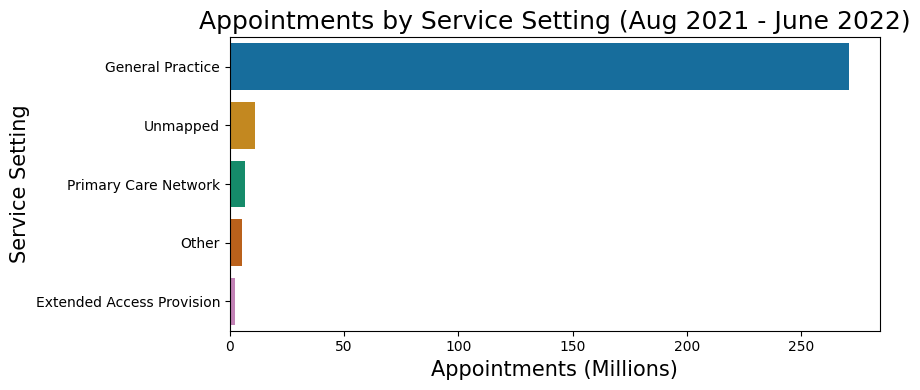

In [38]:
# Calculating the number of appointments for each service setting
# Group and compute totals and percentages
service = nc_clean.groupby('service_setting')[['count_of_appointments']]\
    .sum().sort_values('count_of_appointments', ascending=False)

# Calculating the total number of appointments by service setting as a % of the total
service['% of Total'] = service['count_of_appointments'] / total_nc * 100
service = service.reset_index()

# Scale counts to millions
service['Appointments (Millions)'] = service['count_of_appointments'] / 1_000_000
service = service.round({'Appointments (Millions)': 2, '% of Total': 1})

# Print table
print("Appointment Modes by Service Setting:\n")
print(service[['service_setting', 'Appointments (Millions)', '% of Total']].to_string(index=False))

# Plot horizontal bar chart
plt.figure(figsize=(9, 4))
ax = sns.barplot(
    data=service, 
    x='Appointments (Millions)', 
    y='service_setting', 
    palette='colorblind'
)

plt.title('Appointments by Service Setting (Aug 2021 - June 2022)', fontsize=18)
plt.xlabel('Appointments (Millions)', fontsize=15)
plt.ylabel('Service Setting', fontsize=15)

plt.tight_layout()
plt.show()


In [39]:
# Determine the number appointments by context type
context = nc_clean.groupby('context_type')[['count_of_appointments']]\
        .sum().sort_values('count_of_appointments', ascending=False)

# Calculating the total number of appointments by context type as a % of the total 
context['% of Total'] = context['count_of_appointments']/total_nc * 100

# Round the result to 1 decimal place
context.round(1)


,count_of_appointments,% of Total
context_type,,
Care Related Encounter,257075158,86.8
Inconsistent Mapping,27890802,9.4
Unmapped,11080810,3.7


In [40]:
# Determine the number of national categories
nat_cat = nc_clean.groupby('national_category')[['count_of_appointments']]\
        .sum().sort_values('count_of_appointments', ascending=False)\
# Calculating the total number of appointments for each national category as a % of the total 
nat_cat['% of Total'] = nat_cat['count_of_appointments']/total_nc * 100

# Round the result to 1 decimal place
nat_cat.round(1)

,count_of_appointments,% of Total
national_category,,
General Consultation Routine,97271522,32.9
General Consultation Acute,53691150,18.1
Clinical Triage,41546964,14.0
Planned Clinics,28019748,9.5
Inconsistent Mapping,27890802,9.4
Planned Clinical Procedure,25702694,8.7
Unmapped,11080810,3.7
Unplanned Clinical Activity,3055794,1.0
Home Visit,2144452,0.7


In [41]:
# Determine the number of appointment statuses.
status = ar_clean.groupby('appointment_status')[['count_of_appointments']]\
        .sum().sort_values('count_of_appointments', ascending=False)\

total_ar = ar_clean['count_of_appointments'].sum()

# Calculating the total number of appointments by appointment status (whether an appointment was attended or not)  as a % of the total 
status['% of Total'] = status['count_of_appointments']/total_ar * 100

# Round to 1 decimal place
status.round(1)


,count_of_appointments,% of Total
appointment_status,,
Attended,677646088,91.3
Unknown,34050656,4.6
DNA,30833015,4.2


## 8d GP Appointments by Mode

Appointments by Appointment Mode (in millions):

appointment_mode  Appointments (Millions)
    Face-to-Face                   439.88
       Telephone                   267.75
         Unknown                    26.44
      Home Visit                     4.85
    Video/Online                     3.61


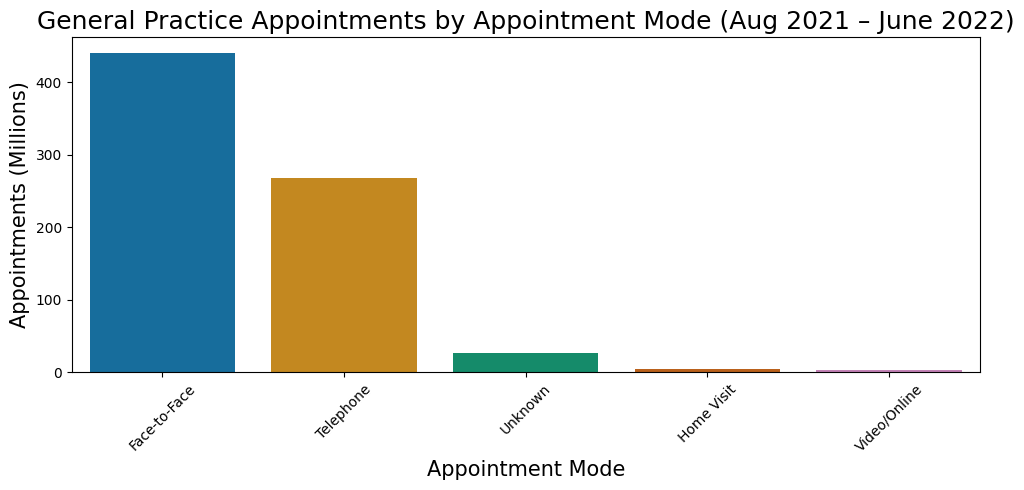

In [42]:
# Group by appointment mode and apppointment totals
appoint_mode_plot = ar_clean.groupby('appointment_mode')[['count_of_appointments']]\
    .sum().sort_values('count_of_appointments', ascending=False).reset_index()

# Scale counts 
appoint_mode_plot['Appointments (Millions)'] = appoint_mode_plot['count_of_appointments'] / 1000000
appoint_mode_plot = appoint_mode_plot.round({'Appointments (Millions)': 2})

# Print table
print("Appointments by Appointment Mode (in millions):\n")
print(appoint_mode_plot[['appointment_mode', 'Appointments (Millions)']].to_string(index=False))

# Plot bar chart
plt.figure(figsize=(10, 5))
ax = sns.barplot(
    data=appoint_mode_plot, 
    x='appointment_mode', 
    y='Appointments (Millions)', 
    palette='colorblind'
)

# Set title, axis labels,sticks
plt.title("General Practice Appointments by Appointment Mode (Aug 2021 – June 2022)", fontsize=18)
plt.xlabel("Appointment Mode", fontsize=15)
plt.ylabel("Appointments (Millions)", fontsize=15)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## 8e Time to Wait for Appointment - Time from booking to actual appointment

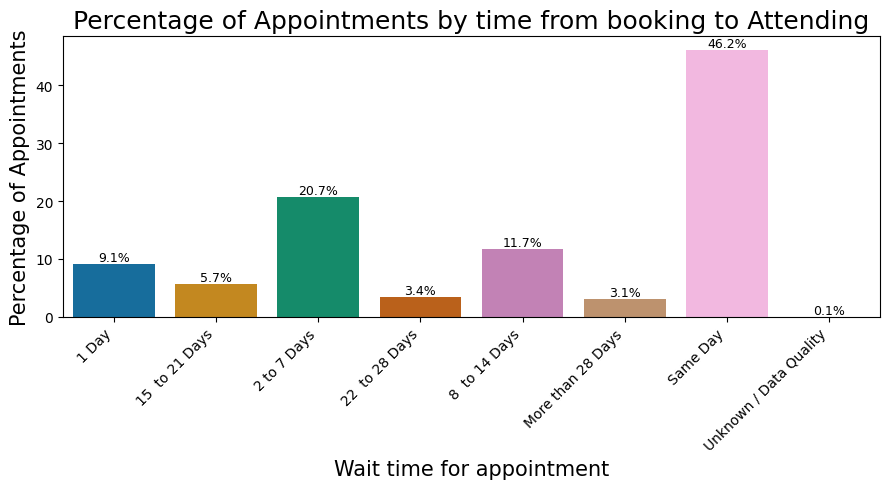

In [43]:
# Calculate the total numbert of appointments by time between booking and plot a bar chart
time_book = ar_clean.groupby('time_between_book_and_appointment')['count_of_appointments'].sum()
time_book.sort_values(ascending=False)

# Create barplot of appointment duration by % of appointments
# Convert Series to DataFrame if needed
if isinstance(time_book, pd.Series):
    time_book = time_book.reset_index()
    time_book.columns = ['time_between_book_and_appointment', 'Appointment count']

# Calculate percentages
total = time_book['Appointment count'].sum()
time_book['Percentage'] = (time_book['Appointment count'] / total) * 100

# Plot graph@
plt.figure(figsize=(9, 5))
ax = sns.barplot(
    data=time_book, 
    x='time_between_book_and_appointment', 
    y='Percentage', 
    palette='colorblind'
)

# Annotate each bar with percentagetime_book
for i, row in time_book.iterrows():
    ax.text(i, row['Percentage'] + 0.5, f"{row['Percentage']:.1f}%", ha='center', fontsize=9)

# Title, labels and sticks
plt.title('Percentage of Appointments by time from booking to Attending', fontsize=18)
plt.xlabel('Wait time for appointment', fontsize=15)
plt.ylabel('Percentage of Appointments', fontsize=15)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


#### Time between booking and apopointment over the time period

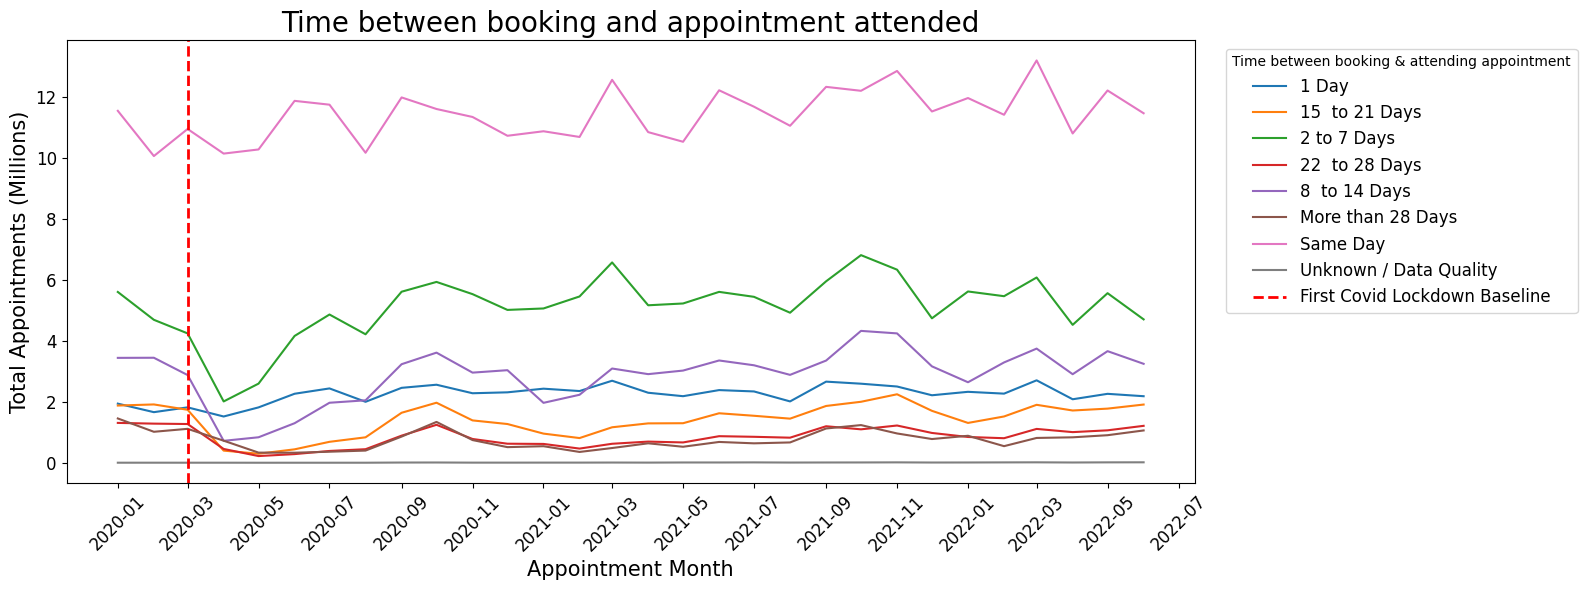

In [44]:
# plot patient wait time as a timeline series
# Ensure the plot window size is enlarged
plt.figure(figsize=(16, 6))

# Enforce proper datetime tracking right before grouping 
ar_clean["appointment_month"] = pd.to_datetime(ar_clean["appointment_month"])

# Group by month and time between booking and appointment
ar_book_appoint = (
    ar_clean.groupby(
        ["appointment_month", "time_between_book_and_appointment"]
    )[["count_of_appointments"]]
    .sum()
    .reset_index()
)

# Scale appointments for readability (millions)
ar_book_appoint["appointments_millions"] = (
    ar_book_appoint["count_of_appointments"] / 1000000
)


# Plot the data
ax = sns.lineplot(
    x="appointment_month",
    y="appointments_millions",
    hue="time_between_book_and_appointment",
    data=ar_book_appoint,
)


# Use an accurate datetime Timestamp to position the line chronologically 
plt.axvline(
    x=pd.to_datetime("2020-03-01"),
    color="red",
    linestyle="--",
    linewidth=2,
    label="First Covid Lockdown Baseline",
)

# Clean up horizontal axis formatting for true datetime values 
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))

# Set title, axis labels, ticks and legend
plt.title("Time between booking and appointment attended", fontsize=20)
plt.xlabel("Appointment Month", fontsize=15)
plt.ylabel("Total Appointments (Millions)", fontsize=15)
plt.xticks(rotation=45, fontsize=12)
plt.yticks(fontsize=12)  # Lowered from 20 to 12 so numbers scale cleanly

# Position legend cleanly outside the margins
plt.legend(
    title="Time between booking & attending appointment",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    fontsize=12,
)
plt.tight_layout()

# Save the plot
plt.savefig("time_between.png")
plt.show()

#### Removed 'same day' from the graph for more clarity - This is the most common. Removing it will allow the other times to become clearer

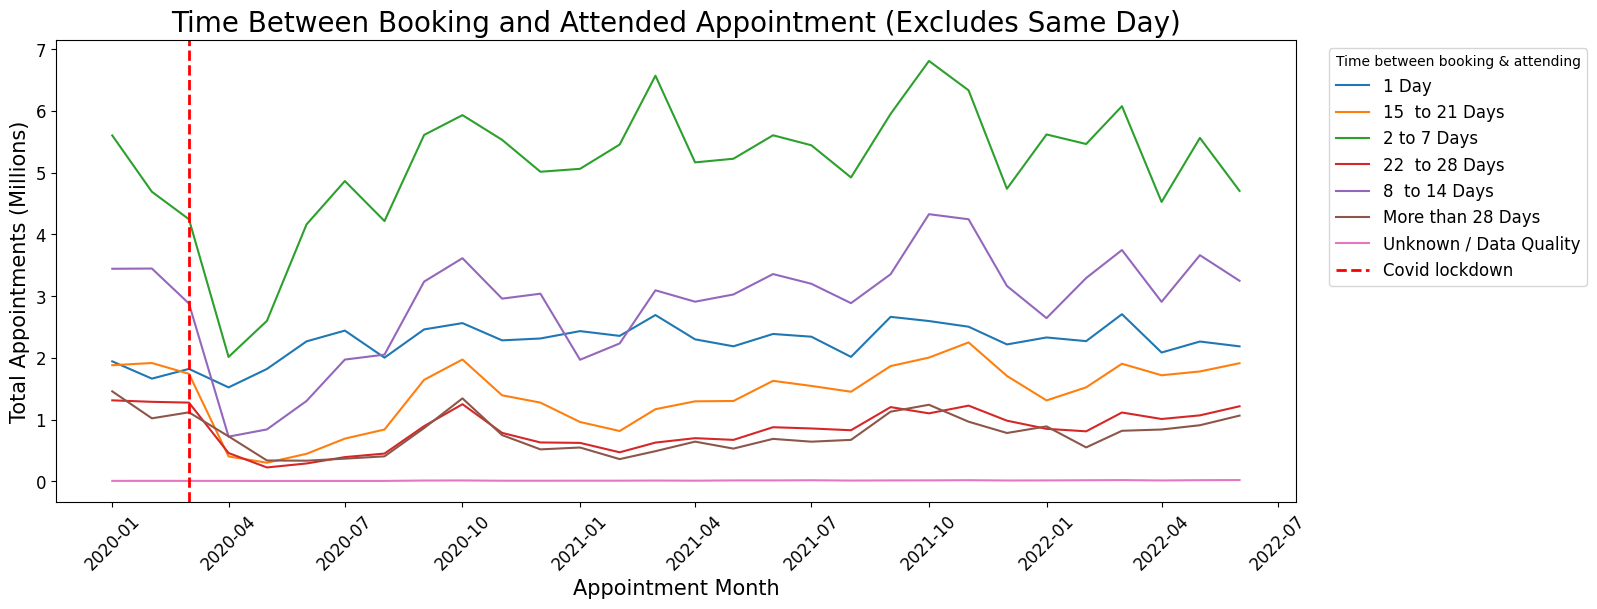

In [45]:
# Time between booking and appointment ex same day for more clarity

# Ensure 'appointment_month' is datetime format
ar_clean['appointment_month'] = pd.to_datetime(ar_clean['appointment_month'])

# Group by month and time between booking and appointment
ar_book_appoint = ar_clean.groupby(['appointment_month', 'time_between_book_and_appointment'])[['count_of_appointments']].sum().reset_index()

# Remove "Same Day" appointments
ar_book_appoint = ar_book_appoint[ar_book_appoint['time_between_book_and_appointment'] != 'Same Day']

# Scale appointment counts to millions
ar_book_appoint['appointments_millions'] = ar_book_appoint['count_of_appointments'] / 1000000

# Plot
plt.figure(figsize=(16, 6))
sns.lineplot(
    x='appointment_month', 
    y='appointments_millions', 
    hue='time_between_book_and_appointment', 
    data=ar_book_appoint
)

# Add lockdown reference line
plt.axvline(
    x=pd.to_datetime('2020-03-01'), 
    color='red', 
    linestyle='--', 
    linewidth=2, 
    label='Covid lockdown'
)

# Set title, axis labels, sticks and legend
plt.title('Time Between Booking and Attended Appointment (Excludes Same Day)', fontsize=20)
plt.xlabel('Appointment Month', fontsize=15)
plt.ylabel('Total Appointments (Millions)', fontsize=15)
plt.xticks(rotation=45, fontsize=12)
plt.yticks(fontsize=12)
plt.legend(title='Time between booking & attending', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=12)
plt.tight_layout

# Save graph
plt.savefig('time_between_ex_same_day.png')

#### The graph shows that the a 2 - 7 day wait between booking and attending anappointment is the second most common, 22 - 28 days the least ommon

#### The 'Unknown/Data Quality' category for booking-to-appointment times remains flat at zero across the entire 2020–2022 timeline on these graphs due to a mismatch in axis scale. So the 'unknown/Data quality' has been extracted and plotted in it's own graph.

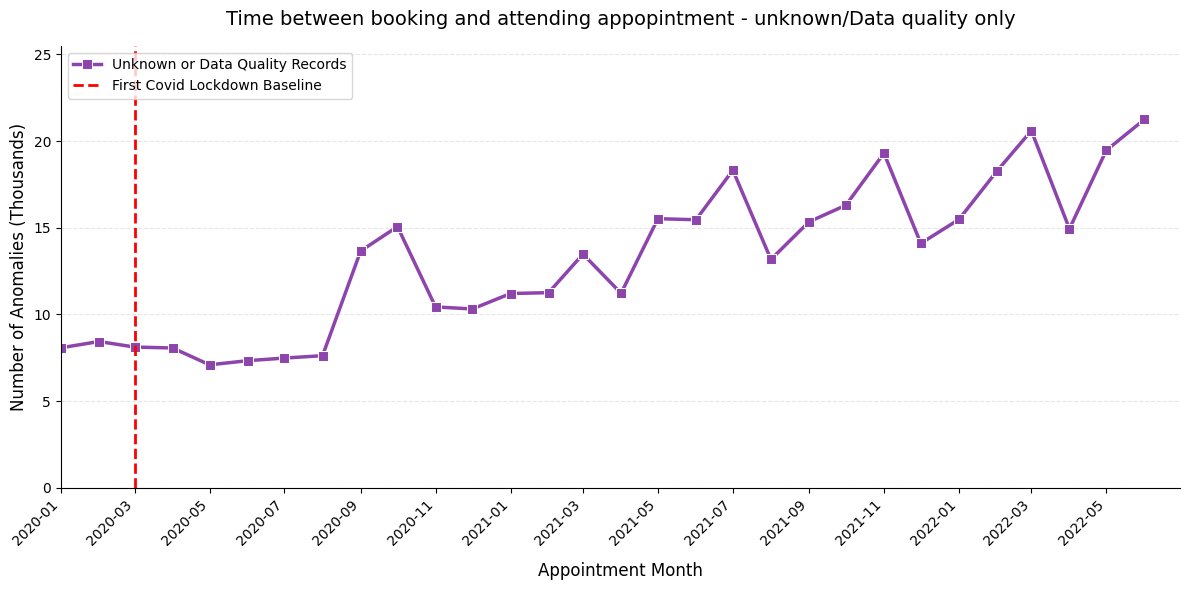

In [46]:
# Time between booking and appointment - 'unknown/data quality' only

# Data Preparation
ar_clean["appointment_month"] = pd.to_datetime(ar_clean["appointment_month"])

# Clean strings on the source dataframe (ar_clean)
ar_clean["time_between_book_and_appointment"] = (
    ar_clean["time_between_book_and_appointment"].astype(str).str.strip()
)
ar_clean["time_between_book_and_appointment"] = ar_clean[
    "time_between_book_and_appointment"
].str.replace(r"\s*/\s*", " or ", regex=True)
ar_clean["time_between_book_and_appointment"] = ar_clean[
    "time_between_book_and_appointment"
].str.replace(r"\s+", " ", regex=True)

# Group by month and clean up the label structure
ar_book_appoint = (
    ar_clean.groupby(
        ["appointment_month", "time_between_book_and_appointment"]
    )[["count_of_appointments"]]
    .sum()
    .reset_index()
)

# Isolate only the Data Quality category
data_qual_df = ar_book_appoint[
    ar_book_appoint["time_between_book_and_appointment"]
    == "Unknown or Data Quality"
].copy()

# Scale the metrics to Thousands (Not millions as other charts) so the axis labels stay clean and legible
data_qual_df["appointments_thousands"] = (
    data_qual_df["count_of_appointments"] / 1000
)

# Plot the line graph    
plt.figure(figsize=(12, 6))

# Plot the data quality trend line
sns.lineplot(
    x="appointment_month",
    y="appointments_thousands",
    data=data_qual_df,
    color="#8e44ad",  # Distinct deep purple line
    marker="s",  # Square markers to indicate individual data points clearly
    linewidth=2.5,
    markersize=7,
    label="Unknown or Data Quality Records",
)

# Add first Covid lockdown context line
plt.axvline(
    x=pd.to_datetime("2020-03-01"),
    color="red",
    linestyle="--",
    linewidth=2,
    label="First Covid Lockdown Baseline",
)

# Set title, axis labels and format
plt.title(
    "Time between booking and attending appopintment - unknown/Data quality only",
    fontsize=14,
    pad=15
)
plt.xlabel("Appointment Month", fontsize=12, labelpad=10)
plt.ylabel("Number of Anomalies (Thousands)", fontsize=12)

# Set the horizontal date limits to lock onto the correct timeline span
plt.xlim(pd.to_datetime("2020-01-01"), pd.to_datetime("2022-06-30"))

# Format the dates on the baseline axis
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
plt.gca().xaxis.set_major_locator(
    mdates.MonthLocator(interval=2)
)  # Shows a label every 2 months for clarity
plt.xticks(rotation=45, ha="right")

# Ensure y-axis starts at zero to accurately represent scale changes
plt.ylim(0, data_qual_df["appointments_thousands"].max() * 1.2)

# Subtle minimalist background styling properties
plt.grid(axis="y", linestyle="--", alpha=0.3)
plt.legend(loc="upper left", frameon=True)

# Remove unnecessary outer box borders
sns.despine()

plt.tight_layout()
plt.savefig("data_quality_anomalies_trend.png", dpi=300)
plt.show()


#### Now it can be seen that rather than being zero or close to it, 'unknown/data quality has in fact increased in regards to reporting of time between booking and a patient attending an appointment

## 8f Appointment Duration (minutes)

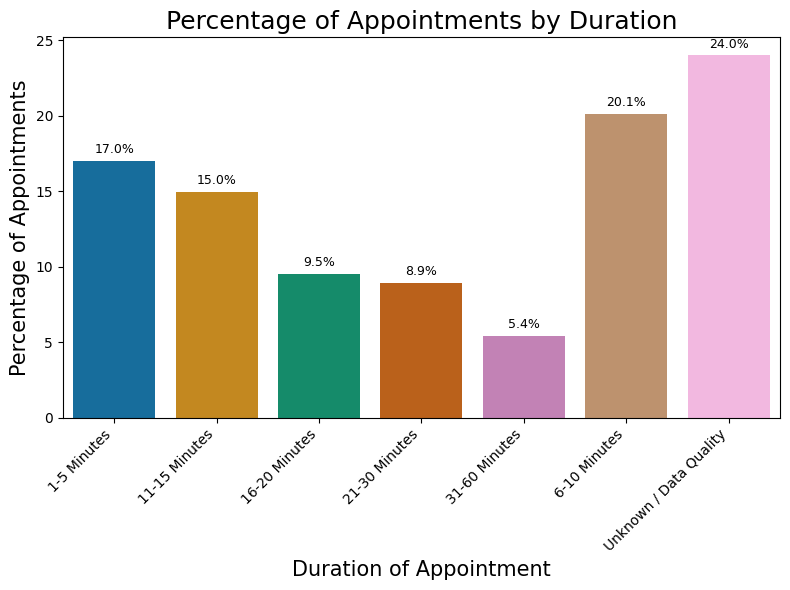

In [47]:
# Calculate the total numbert of appointments by duration
duration = ad_clean.groupby('actual_duration')['count_of_appointments'].sum()
duration.sort_values(ascending=False)

# Create barplot of appointment duration by % of appointments
# Convert Series to DataFrame if needed
if isinstance(duration, pd.Series):
    duration = duration.reset_index()
    duration.columns = ['Appointment Duration', 'Appointment count']

# Calculate percentages
total = duration['Appointment count'].sum()
duration['Percentage'] = (duration['Appointment count'] / total) * 100

# Plot graph
plt.figure(figsize=(8, 6))
ax = sns.barplot(
    data=duration, 
    x='Appointment Duration', 
    y='Percentage', 
    palette='colorblind'
)

# Annotate each bar with percentagetime_book
for i, row in duration.iterrows():
    ax.text(i, row['Percentage'] + 0.5, f"{row['Percentage']:.1f}%", ha='center', fontsize=9)

# Title, labels and sticks
plt.title('Percentage of Appointments by Duration', fontsize=18)
plt.xlabel('Duration of Appointment', fontsize=15)
plt.ylabel('Percentage of Appointments', fontsize=15)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [48]:
ad_clean  # View ad_clean dataset

,sub_icb_location_code,sub_icb_location_ons_code,sub_icb_location_name,icb_ons_code,region_ons_code,appointment_date,actual_duration,count_of_appointments
0,00L,E38000130,NHS North East and North Cumbria ICB - 00L,E54000050,E40000012,01-Dec-21,31-60 Minutes,364
1,00L,E38000130,NHS North East and North Cumbria ICB - 00L,E54000050,E40000012,01-Dec-21,21-30 Minutes,619
2,00L,E38000130,NHS North East and North Cumbria ICB - 00L,E54000050,E40000012,01-Dec-21,6-10 Minutes,1698
3,00L,E38000130,NHS North East and North Cumbria ICB - 00L,E54000050,E40000012,01-Dec-21,Unknown / Data Quality,1277
4,00L,E38000130,NHS North East and North Cumbria ICB - 00L,E54000050,E40000012,01-Dec-21,16-20 Minutes,730
...,...,...,...,...,...,...,...,...
137788,X2C4Y,E38000254,NHS West Yorkshire ICB - X2C4Y,E54000054,E40000012,30-Jun-22,31-60 Minutes,430
137789,X2C4Y,E38000254,NHS West Yorkshire ICB - X2C4Y,E54000054,E40000012,30-Jun-22,21-30 Minutes,751
137790,X2C4Y,E38000254,NHS West Yorkshire ICB - X2C4Y,E54000054,E40000012,30-Jun-22,16-20 Minutes,921
137791,X2C4Y,E38000254,NHS West Yorkshire ICB - X2C4Y,E54000054,E40000012,30-Jun-22,11-15 Minutes,1439


## Notes/Summary

Number of locations: 106
Number of ICB locations: 42
Number of regions: 7

The top 5 ICB sub locations based on count of appointments using the nc_clean dataframe are:

1. NHS North West London ICB - W2U3Z with 12142390 appointments at 4.1%
2. NHS North East London ICB - A3A8R	 with 9588891 appointments at 3.2%
3. NHS Kent and Medway ICB - 91Q	 with 9286167 appointments at 3.1%
4. NHS Hampshire and Isle Of Wight ICB - D9Y0V with 8288102 appointments at 2.8%
5. NHS South East London ICB - 72Q with 7850170 appointments at 2.7%

Top 5 ICB locations based on the number of appointments from the ar_clean dataframe:

1. NHS North East and North Cumbria Integrated Care board with	43054121 appointments at 5.8%
2. NHS West Yorkshire Integrated Care Board	           with 36075020 appointments at 4.9%
3. NHS Greater Manchester Integrated Care Board	       with 34003953 appointments at 4.6%
4. NHS Cheshire and Merseyside Integrated Care Board	   with 33064205 appointments at 4.5%
5. NHS North West London Integrated Care Board	           with 29380767 appointments at 4.0%

Top five SUB ICB locations from ad_clean based on number of appointments

1. NHS North West London ICB - W2U3Z	         with 6976986 appointments at 4.2%
2. NHS North East London ICB - A3A8R	         with 5341883 appointments at 3.2%
3. NHS Kent and Medway ICB - 91Q	             with 5209641 appointments at 3.1%
4. NHS Hampshire and Isle Of Wight ICB - D9Y0V  with 4712737 appointments at 2.8%
5. NHS South East London ICB - 72Q	             with 4360079 appointments at 2.6%

Appointment Modes by Service Setting:

              service_setting  Appointments (Millions)  % of Total
             General Practice                   270.81        91.5
                     Unmapped                    11.08         3.7
         Primary Care Network                     6.56         2.2
                        Other                     5.42         1.8
    Extended Access Provision                     2.18         0.7

context types and number of appointments:
Care Related Encounter	257075158	86.8%
Inconsistent Mapping	27890802	9.4%
Unmapped	11080810	3.7%

A significant issue is that of unmapped data and data that is inconsistently mapped. If the data is inconsistently mapped then this may be down to different sources not using the same data collection and recording methods. This is certainly something which needs to be addressed and it becomes an issue when trying to perform an analysis

There are 18 national categories, of which General Consultation Routine makes up the largest proportion at 32.9%
Unmapped data accounts for 3% of the total, again resulting in lowering the data quality

When it comes to the numbers of appointments attended as expected we see the majority are at 91.3%. 4.2% were not attended which equates to 30,833,015 appointments over the period covered by the data. At a cost of £30 per missed appointment thats £924.9 Million pounds wated. 4.6% of appoinmtments have an unknown status so we don't know whether they were attended or not, limiting the use of the data and reducing data quality.

Taking only GP appointments we can see face to face appointments make the bulk, with telephone being second. The other modes barely register with again an unknown amount of 2.64 million
Appointments by Appointment Mode (in millions):

appointment_mode  Appointments (Millions)
    Face-to-Face                    43.99
       Telephone                    26.78
         Unknown                     2.64
      Home Visit                     0.48
    Video/Online                     0.36

Same day appoinments make up approximately a third of all appointments, more than 28 days is the lowest, although again we meet the unknown/data quality category.

In terms of the duration of appointments it can be seen that there is an issue recording this as the unknown/data quality makes up the highest at 24%. 6-10 minutes as the longest duration of appointments. Unsuprisingly 31-60 minutes accounted for the lowest amount.


# 9. Further Exploratory Data Analysis - All Datasets

## 9a What is the time period of the analysis - using 'actual_duration' and 'national_categories' Datasets

In [49]:
# View the first five rows of appointment_date for the ad_clean DataFrame to determine the date format
print(ad_clean['appointment_date'].head())

0    01-Dec-21
1    01-Dec-21
2    01-Dec-21
3    01-Dec-21
4    01-Dec-21
Name: appointment_date, dtype: object


In [50]:
# View the first five rows of appointment_date for the nc_clean DataFrame to determine the date format.
print(nc_clean['appointment_date'].head())

0    02/08/2021
1    02/08/2021
2    02/08/2021
3    02/08/2021
4    02/08/2021
Name: appointment_date, dtype: object


#### It can be seen that the two datasets have different date formats. These need to be standarised 

In [51]:
# Change the date format of ad_clean['appointment_date']
# Usinf format to set the date to dd/mm/yyyy
ad_clean['appointment_date'] = pd.to_datetime(ad_clean['appointment_date'], format='%d-%b-%y').dt.strftime('%d/%m/%Y')

# View the DateFrame.
ad_clean['appointment_date'].head()

0    01/12/2021
1    01/12/2021
2    01/12/2021
3    01/12/2021
4    01/12/2021
Name: appointment_date, dtype: object

In [52]:
# Determine the minimum and maximum dates in the ad_clean DataFrame.
ad_clean['appointment_date'] = pd.to_datetime(ad_clean['appointment_date'], format='%d/%m/%Y')
min_date = ad_clean['appointment_date'].dt.date.min()
max_date = ad_clean['appointment_date'].dt.date.max()

print("Minimum date:", min_date)
print("Maximum date:", max_date)



Minimum date: 2021-12-01
Maximum date: 2022-06-30


In [53]:
# Determine the minimum and maximum dates in the nc_clean DataFrame.
nc_clean['appointment_date'] = pd.to_datetime(nc_clean['appointment_date'], format='%d/%m/%Y')
min_date_nc = nc_clean['appointment_date'].dt.date.min()
max_date_nc = nc_clean['appointment_date'].dt.date.max()

print("Minimum date:", min_date_nc)
print("Maximum date:", max_date_nc)


Minimum date: 2021-08-01
Maximum date: 2022-06-30


In [54]:
# Convert 'appointment_month' to datetime using only year and month
ar_clean['appointment_month'] = pd.to_datetime(ar_clean['appointment_month'], format='%Y-%m')

# Determine the minimum and maximum dates
min_date_ar = ar_clean['appointment_month'].min()
max_date_ar = ar_clean['appointment_month'].max()

# Display the results
print("Minimum date:", min_date_ar.strftime('%Y-%m'))
print("Maximum date:", max_date_ar.strftime('%Y-%m'))


Minimum date: 2020-01
Maximum date: 2022-06


## 9b Which service setting was used the most in the NHS North West London from 1 January to 1 June 2022?

In [55]:
# For each of these service settings, determine the number of records available for the period and the location. 

nwl = nc_clean[nc_clean['sub_icb_location_name'] == 'NHS North West London ICB - W2U3Z']

nwl = nwl.loc[(nwl['appointment_date'] >= '2022-01-01')\
                         & (nwl['appointment_date'] <= '2022-06-01')]

nwl_total = nwl['count_of_appointments'].sum()

nwl_l = nwl.groupby('service_setting')[['count_of_appointments']].sum().sort_values('count_of_appointments', ascending=False)\
      
nwl_l['% of Total'] = nwl_l['count_of_appointments']/nwl_total * 100
nwl_l.round(1)


,count_of_appointments,% of Total
service_setting,,
General Practice,4804239,86.5
Unmapped,391106,7.0
Other,152897,2.8
Primary Care Network,109840,2.0
Extended Access Provision,98159,1.8


## 9c Service Setting by month (All national categories)

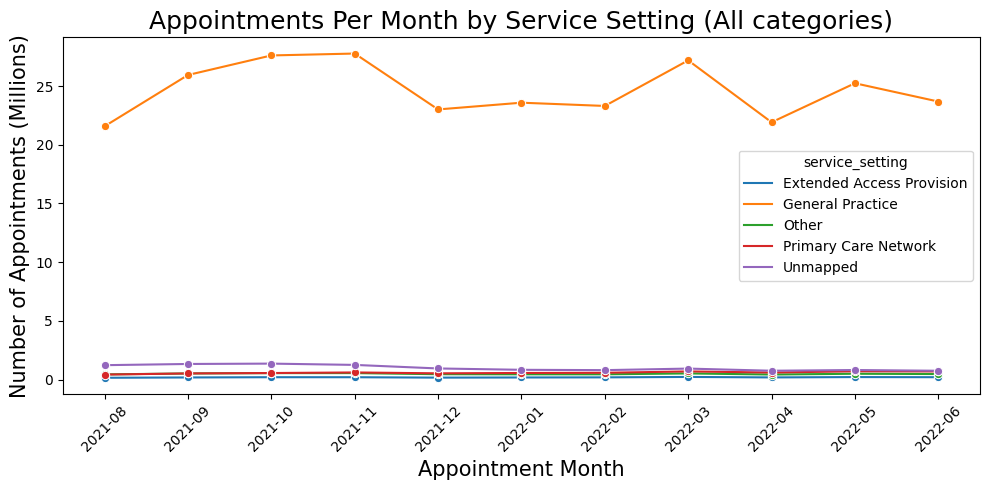

In [56]:
# Group by month and service setting
monthly_service_counts = nc_clean.groupby(['appointment_month', 'service_setting'])['count_of_appointments']\
                                 .sum().reset_index(name='appointment_count')

# Convert counts to millions
monthly_service_counts['appointment_count'] = monthly_service_counts['appointment_count'] / 1_000_000

# Plot line chart
plt.figure(figsize=(10, 5))
sns.lineplot(data=monthly_service_counts, x='appointment_month', y='appointment_count',
    hue='service_setting', marker='o')

# Add titles labels and sticks
plt.title('Appointments Per Month by Service Setting (All categories)', fontsize=18)
plt.ylabel('Number of Appointments (Millions)', fontsize=15)
plt.xlabel('Appointment Month', fontsize=15)
plt.xticks(rotation=45)
plt.tight_layout()

# Show the plot
plt.show()

## 9d Total Appointments by Month

In [57]:
# Number of appointments per month == sum of count_of_appointments by month.
# Use the groupby() and sort_values() functions.
month_count = nc_clean.groupby('appointment_month')
month_count.agg({'count_of_appointments': ['sum']})\
           .sort_values(by=('count_of_appointments', 'sum'), ascending=False)

,count_of_appointments
,sum
appointment_month,
2021-11,30405070
2021-10,30303834
2022-03,29595038
2021-09,28522501
2022-05,27495508
2022-06,25828078
2022-01,25635474
2022-02,25355260


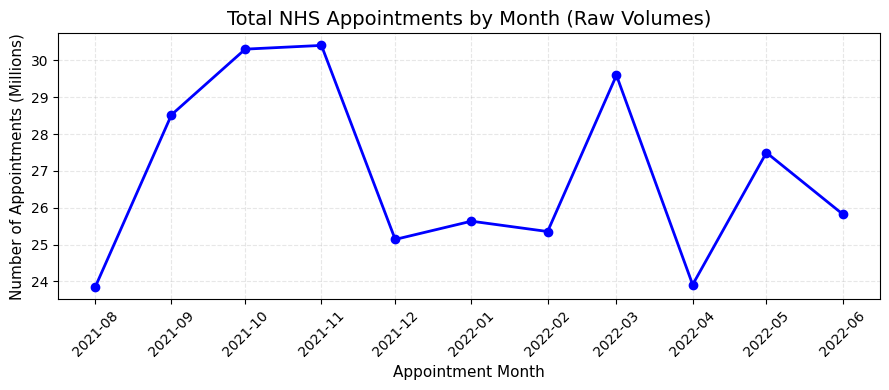

In [58]:
# Plot a line graph to show the variation in number of appointments over the period
# Clean the date column to ensure proper chronological order
nc_clean["appointment_month"] = pd.to_datetime(
    nc_clean["appointment_month"]
)

# Aggregation: Sum total appointments by month
monthly_totals = (
    nc_clean.groupby("appointment_month", as_index=False)[
        "count_of_appointments"
    ]
    .sum()
)
monthly_totals = monthly_totals.sort_values("appointment_month").reset_index(
    drop=True
)

# Create a line plot
fig, ax = plt.subplots(figsize=(9, 4))

ax.plot(monthly_totals["appointment_month"],
    monthly_totals["count_of_appointments"] / 1000000,  # Scale to Millions
    marker="o",
    color="blue",
    linewidth=2,
)

# Set the title and axis labels
plt.title("Total NHS Appointments by Month (Raw Volumes)", fontsize=14)
plt.xlabel("Appointment Month", fontsize=11)
plt.ylabel("Number of Appointments (Millions)", fontsize=11)

# Format the date ticks - and set at 45 degree angle
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
ax.xaxis.set_major_locator(mdates.MonthLocator())
plt.xticks(rotation=45)

plt.grid(True, linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()

#### During the period (08/2021 -06/2022), November 2021 saw the highest number of appointments. This would be the Autumn season so that makes sense.

## 9e Records per month count

In [59]:
# Group by month and count number of records (rows) per month
records_per_month = nc.groupby('appointment_month').size().reset_index(name='record_count')

# Sort by count in descending order
records_per_month_sorted = records_per_month.sort_values(by='record_count', ascending=False)

# Reset index to count from 1, drop the old index
records_per_month_sorted.index = range(1, len(records_per_month_sorted) + 1)

# Display the result
print("Total Number of Records by Month:")
print(records_per_month_sorted)

# Optional: total number of records overall
total_records = nc.shape[0]
print(f"\nTotal number of records in dataset: {total_records:,}")


Total Number of Records by Month:
   appointment_month  record_count
1         2022-03-01         82822
2         2021-11-01         77652
3         2022-05-01         77425
4         2021-09-01         74922
5         2022-06-01         74168
6         2021-10-01         74078
7         2021-12-01         72651
8         2022-01-01         71896
9         2022-02-01         71769
10        2022-04-01         70012
11        2021-08-01         69999

Total number of records in dataset: 817,394


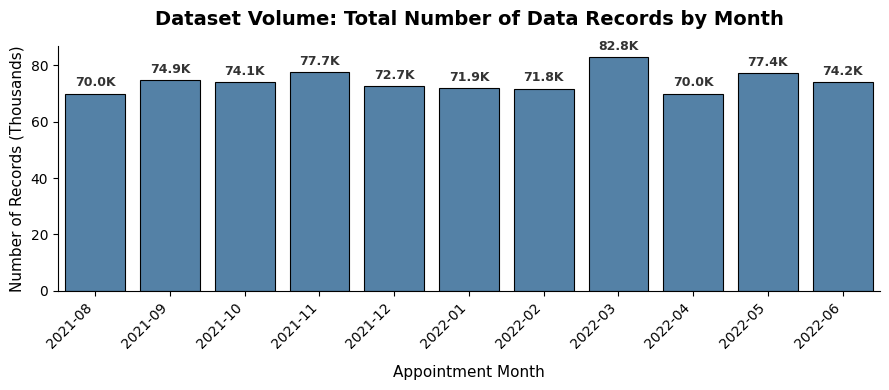

In [60]:
# A barchart to show the number of monthly records in a graphical form

# Ensure appointment_month is parsed as a proper datetime
records_per_month["appointment_month"] = pd.to_datetime(
    records_per_month["appointment_month"]
)

# Sort chronologically by date not record count (as in the above output)
clean_timeline_df = records_per_month.sort_values(
    "appointment_month"
).reset_index(drop=True)

# Create a clean string column for the x-axis labels (e.g., '2021-08')
clean_timeline_df["month_label"] = clean_timeline_df[
    "appointment_month"
].dt.strftime("%Y-%m")

# Plot barchart
plt.figure(figsize=(9, 4))

# Format bars of the barchart
ax = sns.barplot(
    data=clean_timeline_df,
    x="month_label",
    y=clean_timeline_df["record_count"] / 1000,  # Scale to Thousands
    color="#4682B4",
    edgecolor="black",
    linewidth=0.8,
)


# Settitle and axis labels
plt.title(
    "Dataset Volume: Total Number of Data Records by Month",
    fontsize=14,
    pad=15,
    weight="bold",
)
plt.xlabel("Appointment Month", fontsize=11, labelpad=10)
plt.ylabel("Number of Records (Thousands)", fontsize=11)

# Format the date ticks - and set at 45 degree angle
plt.xticks(rotation=45, ha="right")

# Overlay small numeric data labels on top of each bar 
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1fK",
        padding=3,
        fontsize=9,
        color="#333333",
        weight="bold",
    )

sns.despine()

plt.tight_layout()
plt.show()


#### There are 817,394 records in the dataset. March 2022 has the highest number of records, while August 2021 is the lowest

In [61]:
# Group by service setting and count the number of records (rows) in each
service_setting_totals = nc['service_setting'].value_counts().reset_index()
service_setting_totals.columns = ['Service Setting', 'Record Count']

# Reset index to count from 1
service_setting_totals.index = range(1, len(service_setting_totals) + 1)

# Display the result
print("Total Number of Records by Service Setting:")
print(service_setting_totals)


Total Number of Records by Service Setting:
             Service Setting  Record Count
1           General Practice        359274
2       Primary Care Network        183790
3                      Other        138789
4  Extended Access Provision        108122
5                   Unmapped         27419


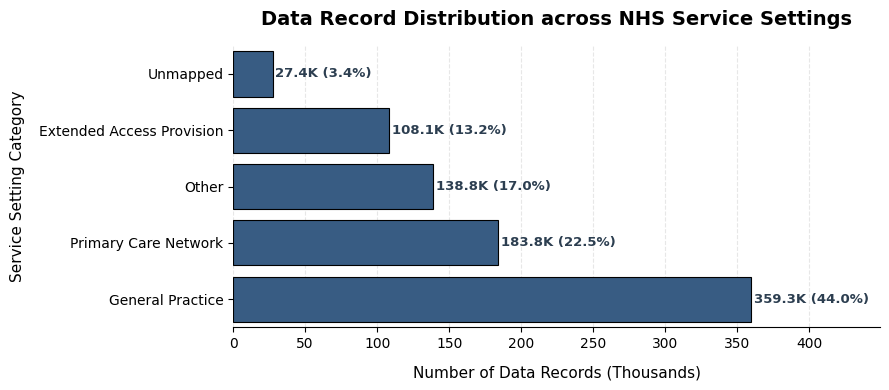

In [62]:
# A barchart to show the number of monthly records by service setting in a graphical form

# Calculate record numbers for each service setting
# Sort service settings into ascending order (smallest on top)
service_setting_totals = service_setting_totals.sort_values(
    by="Record Count", ascending=True
)

# Find the grand total of all records across all settings combined
grand_total_records = service_setting_totals["Record Count"].sum()

# Plot a horizontal bar chart - chosen due to length of service setting names - for clarity and readibility
fig, ax = plt.subplots(figsize=(9, 4))

# Plotting horizontal bars
sns.barplot(
    data=service_setting_totals,
    x=service_setting_totals["Record Count"] / 1000,  # Scale to Thousands
    y="Service Setting",
    color="#2b5c8f",  # Deep blue palette
    edgecolor="black",
    linewidth=0.8,
    ax=ax,
)

# Setting title, axis labels and format of chart
plt.title(
    "Data Record Distribution across NHS Service Settings",
    fontsize=14,
    pad=15,
    weight="bold",
)
plt.xlabel("Number of Data Records (Thousands)", fontsize=11, labelpad=10)
plt.ylabel("Service Setting Category", fontsize=11, labelpad=10)

# Add padding to the horizontal limit so the custom text strings fit comfortably
max_x = (service_setting_totals["Record Count"].max() / 1000) * 1.25
plt.xlim(0, max_x)

# Overlay labels showing both "Raw Count (K)" and "Percentage (%)" - clarity and quick and easy to read
# Loop over each individual horizontal bar drawn on the graph canvas
for bar, raw_count in zip(ax.patches, service_setting_totals["Record Count"]):
    # Find the current right edge coordinate of the bar
    bar_width = bar.get_width()
    bar_y = bar.get_y() + bar.get_height() / 2

    # Calculate this specific setting's percentage share of the dataset
    share_pct = (raw_count / grand_total_records) * 100

    # Create a clean dual-display text string (e.g., "15.2K (12.4%)")
    display_label = f"{raw_count/1000:.1f}K ({share_pct:.1f}%)"

    # Write the string onto the plot canvas slightly to the right of the bar edge
    ax.text(
        x=bar_width + 2,  # Padding a small space offset from the bar edge
        y=bar_y,
        s=display_label,
        va="center",
        ha="left",
        fontsize=9.5,
        color="#2c3e50",
        weight="bold",
    )

# Add a background grid lines aligned to help with clarity and readibility
plt.grid(axis="x", linestyle="--", alpha=0.3, zorder=0)
ax.set_axisbelow(True)

# Strip top, right, and left outer box spines for a modern minimalist style
sns.despine(left=True)

plt.tight_layout()
plt.show()


# 10. Health Care Provider (HCP) Analysis - Who provides the medical care?

## 10a Number of Appointments by HCP

In [63]:
# Group by HCP type and sum appointment counts
hcp = ar_clean.groupby('hcp_type')[['count_of_appointments']]\
        .sum().sort_values('count_of_appointments', ascending=False)

# Calculate total appointments across all HCP types
total_appointments = hcp['count_of_appointments'].sum()

# Add a column for % of total
hcp['% of Total'] = (hcp['count_of_appointments'] / total_appointments) * 100

# Round values and display
hcp = hcp.round(1)

# Display result
print(hcp)


                      count_of_appointments  % of Total
hcp_type                                               
GP                                379532056        51.1
Other Practice staff              339528981        45.7
Unknown                            23468722         3.2


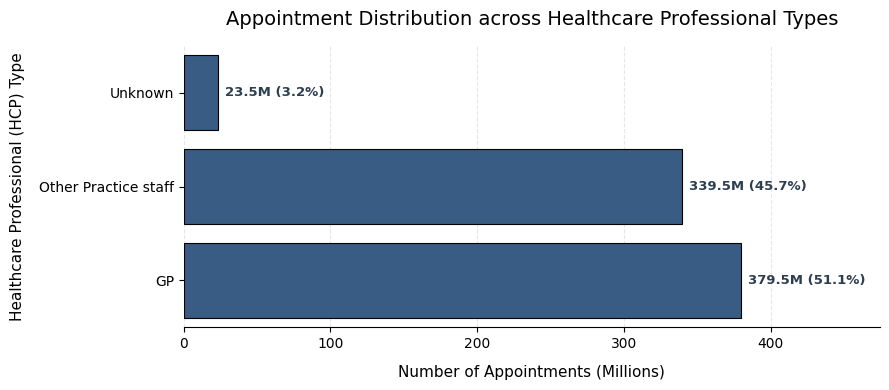

In [64]:
# Plot a var chart of HCP

# Reset dataframe index
hcp_plot_df = hcp.reset_index()

# Sort ascending order (smallest at top)
hcp_plot_df = hcp_plot_df.sort_values(
    by="count_of_appointments", ascending=True
)

# Calculaye grand total of appointments for calculating the percentages inside the loop
grand_total_hcp = hcp_plot_df["count_of_appointments"].sum()

# Plot horizontal bar chart
fig, ax = plt.subplots(figsize=(9, 4))

# Plotting horizontal bars
sns.barplot(
    data=hcp_plot_df,
    x=hcp_plot_df["count_of_appointments"] / 1000000,  # Scaled to Millions 
    y="hcp_type",
    color="#2b5c8f",  # Steal bkue palette
    edgecolor="black",
    linewidth=0.8,
    ax=ax,
)

# Set title, axis labels and format
plt.title(
    "Appointment Distribution across Healthcare Professional Types",
    fontsize=14,
    pad=15,
)
plt.xlabel("Number of Appointments (Millions)", fontsize=11, labelpad=10)
plt.ylabel("Healthcare Professional (HCP) Type", fontsize=11, labelpad=10)

# Add padding to the horizontal limit so the text strings fit comfortably on the canvas
max_x = (hcp_plot_df["count_of_appointments"].max() / 1000000) * 1.25
plt.xlim(0, max_x)

# Overlay labels showing both "Raw Count (Millions)" and "Percentage (%)"
for bar, raw_count in zip(ax.patches, hcp_plot_df["count_of_appointments"]):
    # Find the current right edge coordinate of the bar
    bar_width = bar.get_width()
    bar_y = bar.get_y() + bar.get_height() / 2

    # Calculate this specific HCP's percentage share of the workload
    share_pct = (raw_count / grand_total_hcp) * 100

    # Create a clean dual-display text string (e.g., "15.4M (51.2%)")
    display_label = f"{raw_count/1000000:.1f}M ({share_pct:.1f}%)"

    # Write the string onto the plot canvas slightly to the right of the bar edge
    ax.text(
        x=bar_width + (max_x * 0.01),  # Dynamic small offset from the bar edge
        y=bar_y,
        s=display_label,
        va="center",
        ha="left",
        fontsize=9.5,
        color="#2c3e50",
        weight="bold",
    )

# Add background grid lines aligned to support horizontal tracking
plt.grid(axis="x", linestyle="--", alpha=0.3, zorder=0)
ax.set_axisbelow(True)

# Strip top, right, and left outer box spines for a modern minimalist style
sns.despine(left=True)

plt.tight_layout()
plt.show()

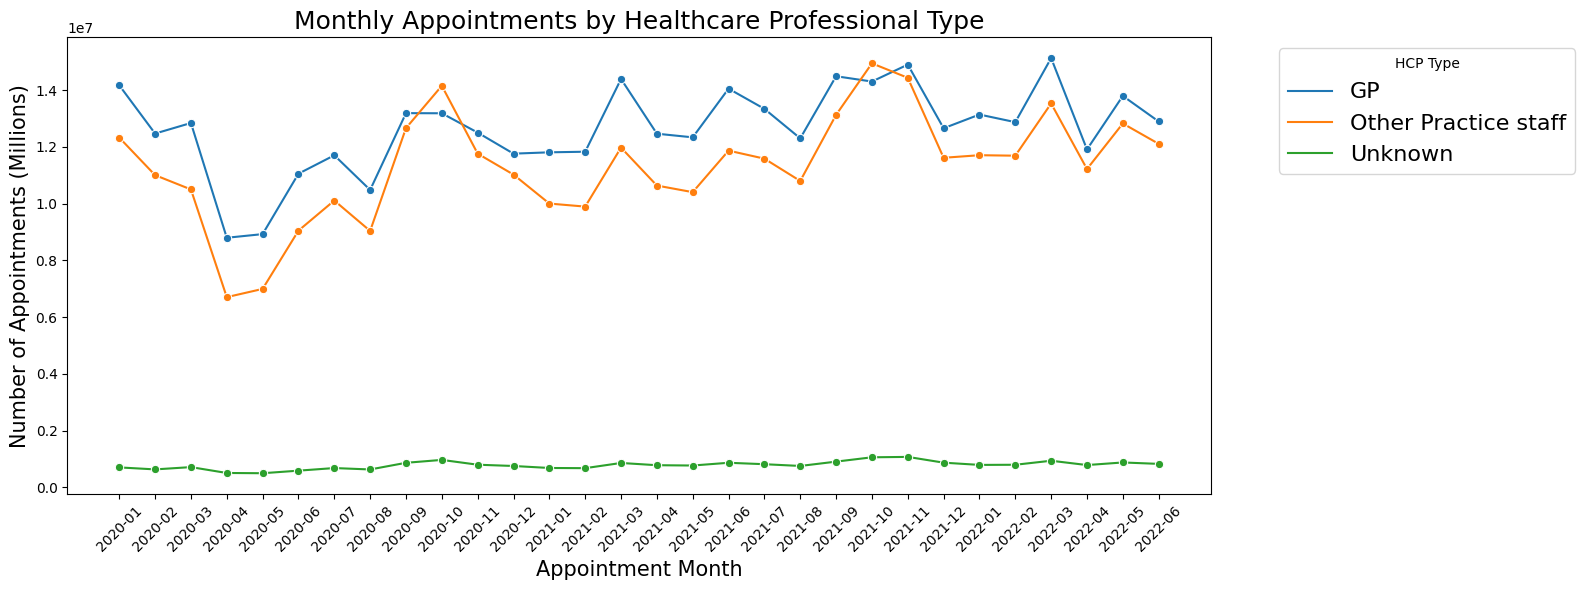

In [65]:
# Create a lineplot of appointments by HCP for the period 01/2020 - 06/2022 

# Count total appointments by HCP per month
hcp_type = ar.groupby(
    ['appointment_month', 'hcp_type'])['count_of_appointments'].sum().reset_index()

# Set figure size and axis
plt.figure(figsize=(16, 6))
sns.lineplot(
    data=hcp_type,
    x='appointment_month', 
    y='count_of_appointments', 
    hue='hcp_type', 
    marker='o'
)

# Set title, axis labels and legend
plt.title('Monthly Appointments by Healthcare Professional Type', fontsize=18)
plt.xlabel('Appointment Month', fontsize=15)
plt.ylabel('Number of Appointments (Millions)', fontsize=15)
plt.xticks(rotation=45)
plt.legend(
    title='HCP Type', 
    bbox_to_anchor=(1.05, 1), 
    loc='upper left', 
    fontsize=16
)
plt.tight_layout()

# Save graph
plt.savefig("hcp_month.png")

## Notes/Summary

The appointmnet_date column from the ad_clean datframe is in the date format of dd-short_month-short_year

The appointment_date for the nc_clean datframe is in a difference format as dd-mm-yyyy

The ad_clean date format was changed to match that of the nc_clean datframe

The minimum ands maximum dates of the nc_clean datframe were determined as follows:
Minimum date: 2021-08-01
Maximum date: 2022-06-30

The minimum and maximum dates for the ar_clean dataframe were determined. In this case the date has no day inlcuded only year and month so formatting wa necessary:
Minimum date: 2020-01
Maximum date: 2022-06

It can be seen that each dataframe covers a different time period. However, they overlap between 2021-08-01 and 2022-96-30. Both of these datframes share a column called appointment_month. Is there a possibility to join these datframes by 'appointment_month'?
indeed nc_clean actually has two date columns

Service setting wise, general practisioner was by far the most popular, accounting for 86% of the appointments, although unmapped and other (thats not defined) make up a significant 10%

November 2021 saw the highest number of appointments at 30,405,070 while Auguest 2021 saw the lowest at	23,852,171/

November 2021 had the highest number of records at 30405070

Total Number of Records by Service Setting:
                  Service Setting  Record Count
1.              General Practice        359274
2.          Primary Care Network        183790
3.                         Other        138789
4.     Extended Access Provision        108122
5.                      Unmapped         27419

HCP
                  count_of_appointments  % of Total
                  
GP                        379,532,056        51.1

Other Practice staff      339,528,981        45.7

Unknown                    23,468,722         3.2                    


# 11. Daily / Monthly Trends

In [66]:
# Setting up plot size and style

# Set figure size.
sns.set(rc={'figure.figsize':(15, 12)})

# Set the plot style as white.
sns.set_style('white')

## 11a Appointment Count by Month


In [67]:
# Change the data type of the appointment month to string to allow for easier plotting.
ar_clean['appointment_month'] = ar_clean['appointment_month'].astype(str)
nc_clean['appointment_month'] = nc_clean['appointment_month'].astype(str)
ar_clean.info()
nc_clean.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 575217 entries, 0 to 575216
Data columns (total 10 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   icb_ons_code                       575217 non-null  object 
 1   appointment_month                  575217 non-null  object 
 2   appointment_status                 575217 non-null  object 
 3   hcp_type                           575217 non-null  object 
 4   appointment_mode                   575217 non-null  object 
 5   time_between_book_and_appointment  575217 non-null  object 
 6   count_of_appointments              575217 non-null  int64  
 7   code                               550166 non-null  object 
 8   name                               550166 non-null  object 
 9   region_no                          550166 non-null  float64
dtypes: float64(1), int64(1), object(8)
memory usage: 48.3+ MB
<class 'pandas.core.frame.DataFrame'>
RangeInd

In [68]:
# Aggregate on monthly level and determine the sum of records per month.
# Group by month and count the number of records
monthly_records = nc_clean.groupby('appointment_month').size().reset_index(name='Record Count')

# Convert record counts to millions
monthly_records['Records (Millions)'] = (monthly_records['Record Count'] / 1_000_000).round(2)

# Display the result
monthly_records


,appointment_month,Record Count,Records (Millions)
0,2021-08-01,69999,0.07
1,2021-09-01,74922,0.07
2,2021-10-01,74078,0.07
3,2021-11-01,77652,0.08
4,2021-12-01,72651,0.07
5,2022-01-01,71896,0.07
6,2022-02-01,71769,0.07
7,2022-03-01,82822,0.08
8,2022-04-01,70012,0.07
9,2022-05-01,77425,0.08


## 11b Appointment Count by National Category (August 2021 -June 2022)


In [69]:
# Group by national category and sum the appointments
nat_cats = nc.groupby("national_category")["count_of_appointments"].sum().reset_index()

# Sort in descending order and reset index starting from 1
nat_cats = nat_cats.sort_values(by="count_of_appointments", ascending=False).reset_index(drop=True)
nat_cats.index += 1

# View result
nat_cats


,national_category,count_of_appointments
1,General Consultation Routine,97271522
2,General Consultation Acute,53691150
3,Clinical Triage,41546964
4,Planned Clinics,28019748
5,Inconsistent Mapping,27890802
6,Planned Clinical Procedure,25702694
7,Unmapped,11080810
8,Unplanned Clinical Activity,3055794
9,Home Visit,2144452
10,Structured Medication Review,1858379


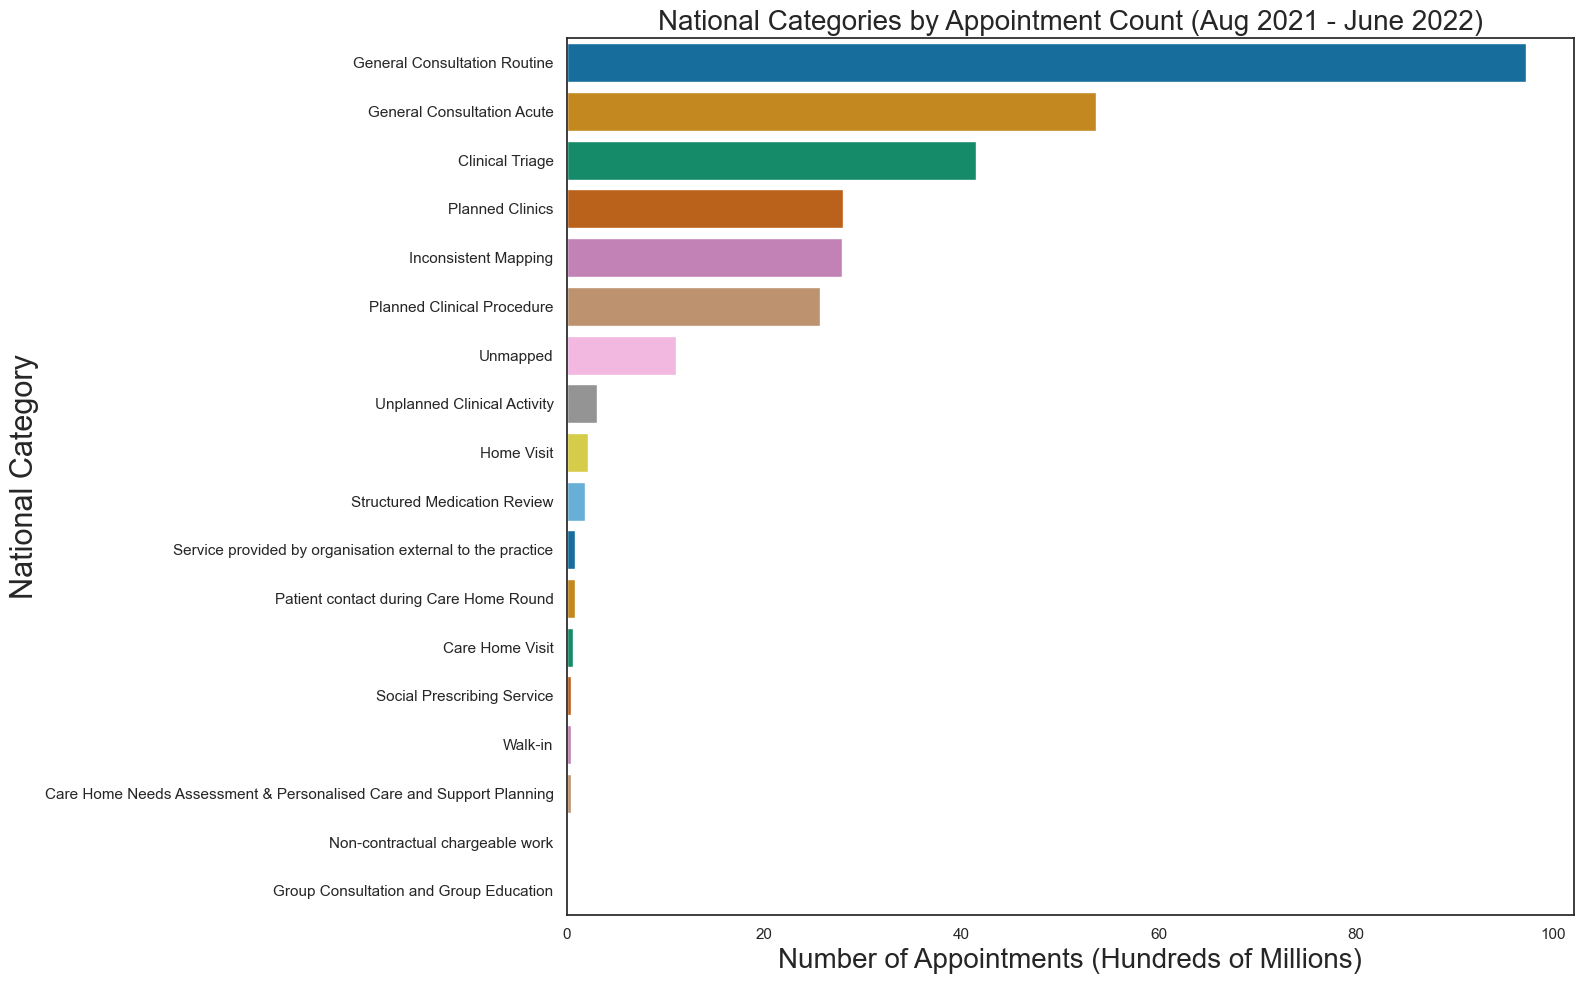

In [70]:
# Convert to hundreds of millions
nat_cats['count_of_appointments_100m'] = (nat_cats['count_of_appointments'] / 1_000_000)

# Sort in descending order
nat_cats = nat_cats.sort_values(by="count_of_appointments_100m", ascending=False)

# Plot bar chart
plt.figure(figsize=(16, 10))
ax = sns.barplot(data=nat_cats, x='count_of_appointments_100m', y='national_category', palette='colorblind')

# Customize titles and labels
plt.title("National Categories by Appointment Count (Aug 2021 - June 2022)", fontsize=20)
plt.xlabel("Number of Appointments (Hundreds of Millions)", fontsize=20)
plt.ylabel("National Category", fontsize=22)
plt.tight_layout()
plt.show()


## 11c Daily Appointment Count by Date (August 2021 -June 2022) - All Settings


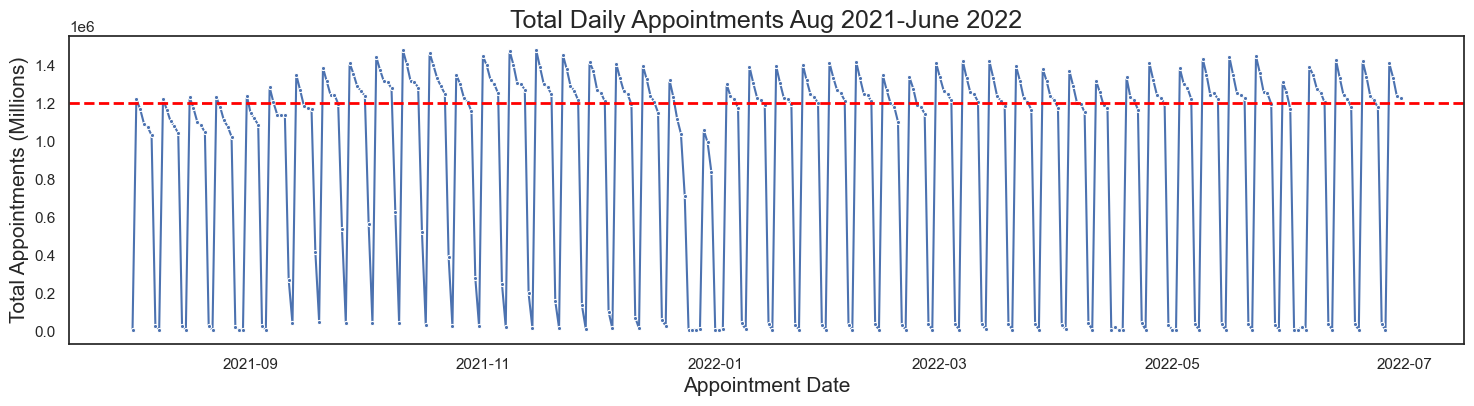

In [71]:
# Plotting a graph to show total daily appointments (Aug 2021 - June 2022) by appointment date
# Group to show total appointments in General Practice on each date.
nc_daily = nc_clean.groupby(['appointment_date'])[['count_of_appointments']].sum().reset_index()\
        .rename(columns={'appointment_date':'Appointment Date', 'count_of_appointments':'Total Appointments'})

# Plot a line graph of sum of appointments by day from the nc DataFrame.
plt.figure(figsize=(18,4))
sns.lineplot(
    data=nc_daily, 
    x='Appointment Date', 
    y='Total Appointments', 
    marker='.'
)

# Add horizontal line at 1.2 million as mwximum daily capacity
plt.axhline(y=1_200_000, color='red', linestyle='--', linewidth=2, label='Target: 1.2M')

# Set title and axis labels
plt.title('Total Daily Appointments Aug 2021-June 2022', fontsize=18)
plt.xlabel('Appointment Date', fontsize=15)
plt.ylabel('Total Appointments (Millions)', fontsize=15);

## 11d Appointment Count per Month by Service Setting


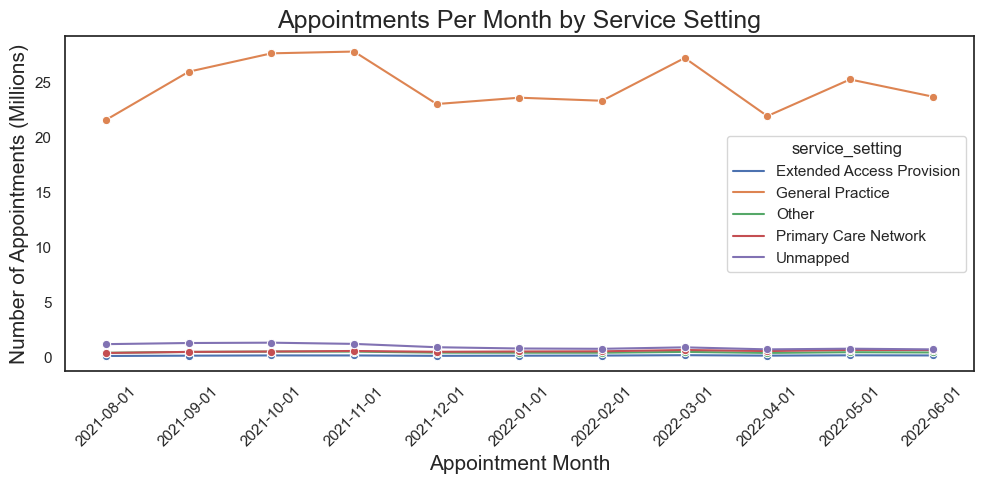

In [72]:
# Appoinments by month against service setting
# Group by month and service setting
monthly_service_counts = nc_clean.groupby(
    ['appointment_month', 'service_setting'])['count_of_appointments'].sum()\
                                 .reset_index(name='appointment_count')

# Convert counts to millions
monthly_service_counts['appointment_count'] = monthly_service_counts['appointment_count'] / 1_000_000

# Plot line chart
plt.figure(figsize=(10, 5))
sns.lineplot(
    data=monthly_service_counts, 
    x='appointment_month', 
    y='appointment_count', 
    hue='service_setting', 
    marker='o'
)

# Add titles, sticks and labels
plt.title('Appointments Per Month by Service Setting', fontsize=18)
plt.ylabel('Number of Appointments (Millions)', fontsize=15)
plt.xlabel('Appointment Month', fontsize=15)
plt.xticks(rotation=45)
plt.tight_layout()

# Show the plot
plt.show()


## 11e Appointment Count per Month by Service Setting (GP Removed)
GP appointments dwarf all other service settings making it difficult to extract any useable data from the graph. Removing GP appointments allows us to see what is really happening in the other settings



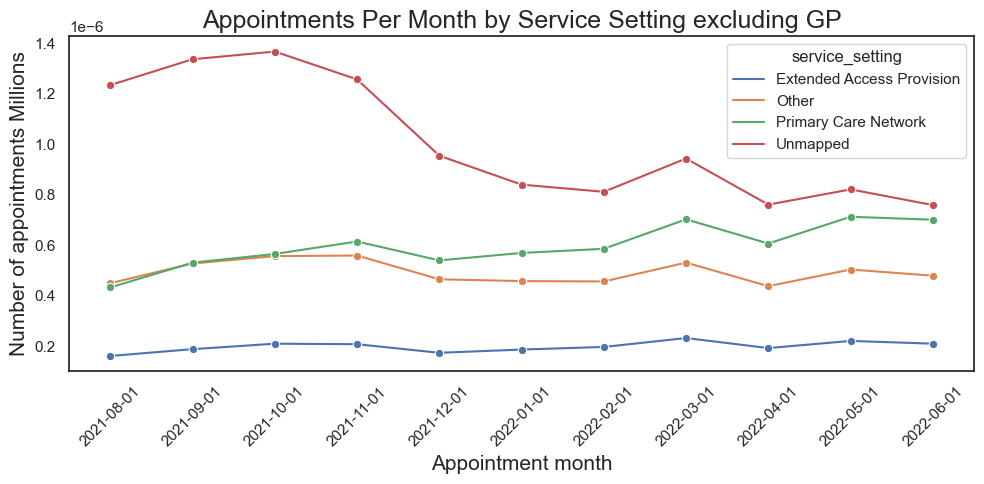

In [73]:
# The same graph without GP and zoomed in on the remaining service settings

# Group by month and service setting but remove 'General pracice'
month_service_count_not_gp = monthly_service_counts[monthly_service_counts['service_setting'] != 'General Practice']

# Convert counts to millions
month_service_count_not_gp['appointment_count'] = month_service_count_not_gp['appointment_count'] / 1000000

# Create plot without gp service type using 'month_service_count_not_gp'
# Plot line chart with hue for service setting
plt.figure(figsize=(10, 5))
sns.lineplot(
    data=month_service_count_not_gp, 
    x='appointment_month', 
    y='appointment_count', 
    hue='service_setting', 
    marker='o'
)

# Set title, axis labels and sticks
plt.title('Appointments Per Month by Service Setting excluding GP', fontsize=18)
plt.ylabel('Number of appointments Millions', fontsize=15)
plt.xlabel('Appointment month', fontsize=15)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



#### The graph shows how the number of appointments has varied over the period excluding GP. Unmapped dominates, although there is a significant drop during the Autumn of 2021. This could be due to the introduction of the Learn from Patient Safety Events (LFPSE) service, a modernised digital system designed to replace the legacy National Reporting and Learning Service (NRLS) and improve how healthcare organisations collect and learn from safety data.

## 11f Appointment Distribution by Service Setting

#### To assess the appointment distribution by service setting the nc_clean dataset will be used

In [74]:
# View the head of nc_clean
nc_clean.head()

,appointment_date,icb_ons_code,sub_icb_location_name,service_setting,context_type,national_category,count_of_appointments,appointment_month
0,2021-08-02,E54000050,NHS North East and North Cumbria ICB - 00L,Primary Care Network,Care Related Encounter,Patient contact during Care Home Round,3,2021-08-01
1,2021-08-02,E54000050,NHS North East and North Cumbria ICB - 00L,Other,Care Related Encounter,Planned Clinics,7,2021-08-01
2,2021-08-02,E54000050,NHS North East and North Cumbria ICB - 00L,General Practice,Care Related Encounter,Home Visit,79,2021-08-01
3,2021-08-02,E54000050,NHS North East and North Cumbria ICB - 00L,General Practice,Care Related Encounter,General Consultation Acute,725,2021-08-01
4,2021-08-02,E54000050,NHS North East and North Cumbria ICB - 00L,General Practice,Care Related Encounter,Structured Medication Review,2,2021-08-01


In [75]:
# Creating a new datframe to give the count of appointments by service setting per day for the period
season = (nc_clean.groupby(['appointment_date', 'appointment_month', 'service_setting'])[['count_of_appointments']]
    .sum().reset_index())

# View the first 10 rows
season.head(10)


,appointment_date,appointment_month,service_setting,count_of_appointments
0,2021-08-01,2021-08-01,Extended Access Provision,438
1,2021-08-01,2021-08-01,General Practice,3411
2,2021-08-01,2021-08-01,Other,401
3,2021-08-01,2021-08-01,Primary Care Network,323
4,2021-08-01,2021-08-01,Unmapped,1054
5,2021-08-02,2021-08-01,Extended Access Provision,7705
6,2021-08-02,2021-08-01,General Practice,1108073
7,2021-08-02,2021-08-01,Other,22098
8,2021-08-02,2021-08-01,Primary Care Network,20016
9,2021-08-02,2021-08-01,Unmapped,64876


In [76]:
# Create a new DataFrame consisting of the month of appointment and the number of appointments from the season dataframe
# Group by month and service setting, summing appointments
monthly_service = season.groupby(['appointment_month', 'service_setting'])[['count_of_appointments']].sum().reset_index()

# View the DataFrame
monthly_service.head()


,appointment_month,service_setting,count_of_appointments
0,2021-08-01,Extended Access Provision,160927
1,2021-08-01,General Practice,21575852
2,2021-08-01,Other,449101
3,2021-08-01,Primary Care Network,432448
4,2021-08-01,Unmapped,1233843


#### Creating a barplot to look at the distribution of appointments by service setting

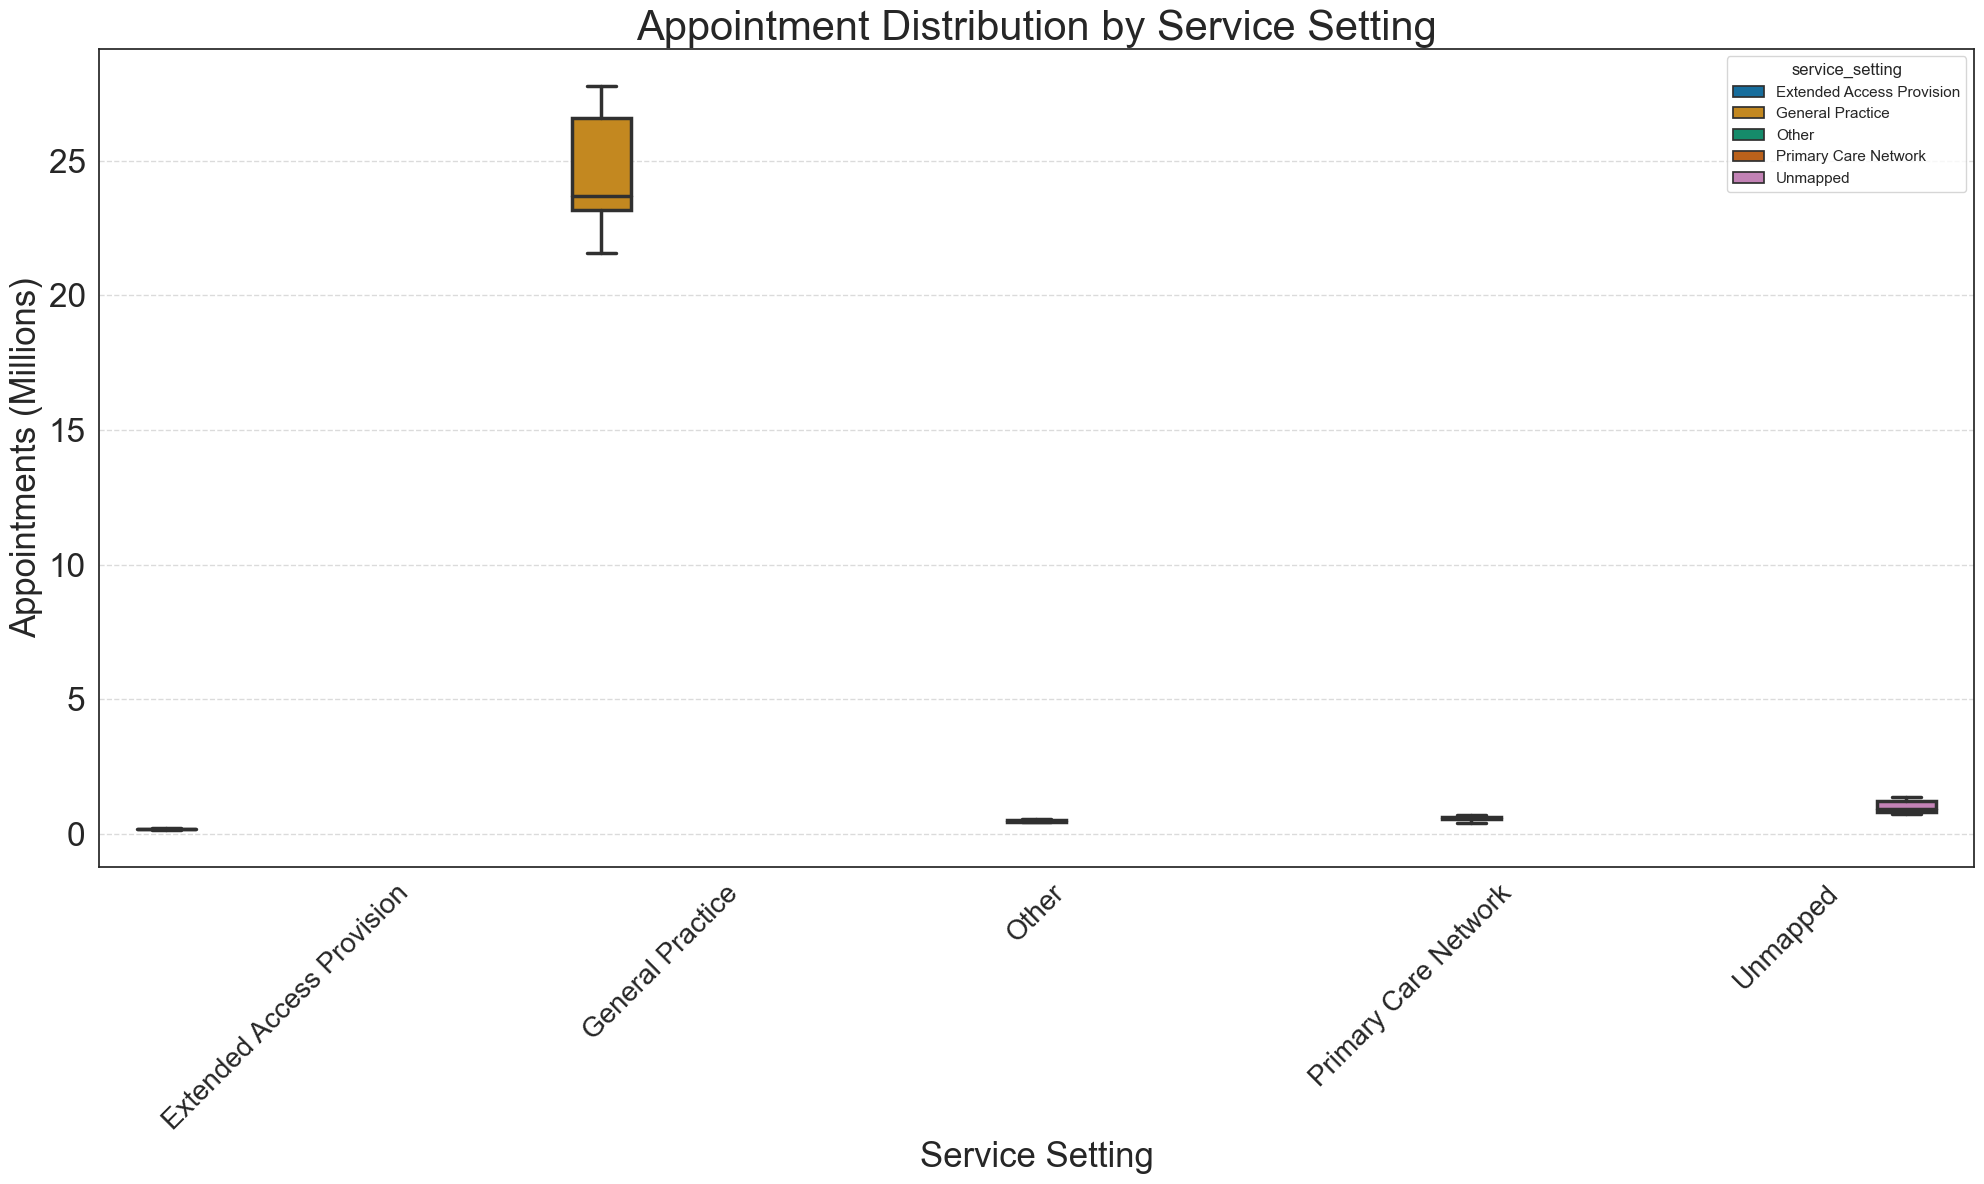

In [77]:
# Create a boxplot in Seaborn based on the new DataFrame to indicate the service settings for the number of appointments.

# Scaled to millions
monthly_service['appointments_millions'] = monthly_service['count_of_appointments'] / 1000000

# Ensure appointment_month is a string for plotting
monthly_service['appointment_month'] = monthly_service['appointment_month'].astype(str)

# Set plot size 
plt.figure(figsize=(20, 12))  

# Create a boxplot 
sns.boxplot(
    data=monthly_service, 
    x='service_setting', 
    y='appointments_millions', 
    hue='service_setting',
    width=0.8, 
    linewidth=2.5, 
    fliersize=18, 
    palette='colorblind'
)

# Title, labels and ticks
plt.title('Appointment Distribution by Service Setting', fontsize=30)
plt.xlabel('Service Setting', fontsize=25)
plt.ylabel('Appointments (Millions)', fontsize=25)
plt.xticks(rotation=45, fontsize=20)  
plt.yticks(fontsize=24)  
plt.tight_layout()

# Add grid for better readability
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Save graph
plt.savefig('appointments_by_service_setting_boxplot.png', dpi=300, bbox_inches='tight')

#### GP appointments dominate the graph making it difficult to understand or analyse the other service settings. GP appointment are move in the following boxplot

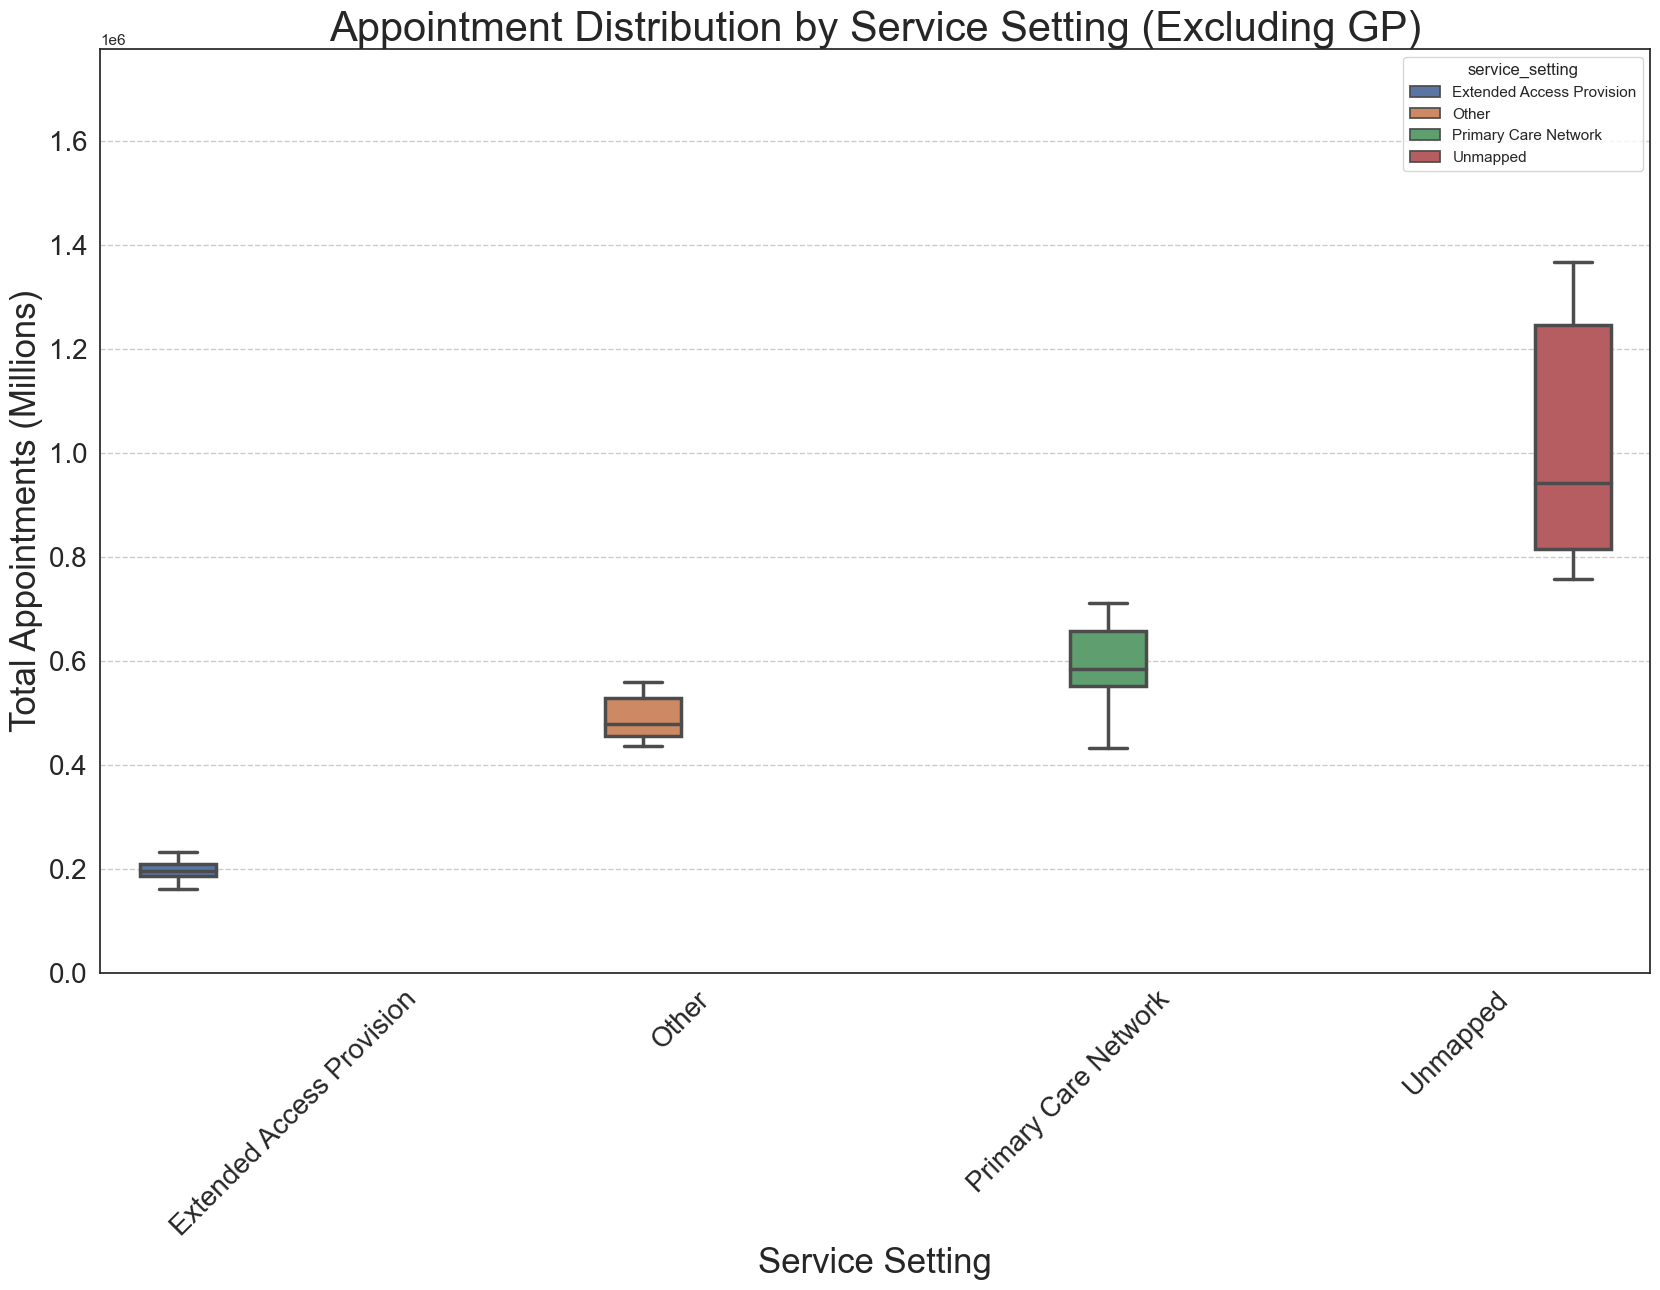

In [78]:
# Create a boxplot in Seaborn based on the new DataFrame to indicate the service settings for the number of appointments.
# Excluding GP from service settings

# Scaled to millions
monthly_service['appointments_millions'] = monthly_service['count_of_appointments'] / 1000000

# Ensure appointment_month is a string for plotting
monthly_service['appointment_month'] = monthly_service['appointment_month'].astype(str)

# Filter out 'GP' from service settings
monthly_service_filtered = monthly_service[monthly_service['service_setting'] != 'General Practice']

# Set plot size - significantly increased for better visibility
plt.figure(figsize=(20, 12))

# Create a boxplot excluding GP
sns.boxplot(
    data=monthly_service_filtered, 
    x='service_setting',
    y='count_of_appointments', 
    hue='service_setting',
    width=0.8, 
    linewidth=2.5, 
    fliersize=8
)

# Title, labels and ticks
plt.title('Appointment Distribution by Service Setting (Excluding GP)', fontsize=30)  
plt.xlabel('Service Setting', fontsize=25)
plt.ylabel('Total Appointments (Millions)', fontsize=25)
plt.xticks(rotation=45, fontsize=20)
plt.yticks(fontsize=20)

# Adjust y-axis to increase scale
y_max = monthly_service_filtered['count_of_appointments'].max()
plt.ylim(0, y_max * 1.3)

# Add grid for better readability
plt.grid(axis='y', linestyle='--')
plt.tight_layout

# Save graph
plt.savefig('appointments_by_service_setting_boxplot_no_gp.png', dpi=300, bbox_inches='tight')  # Updated filename

#### The boxplot of appointment distribution by service setting shows the interquartile range of appointments (Those values inside the box).

#### GP appopintments

Minimum = 22 Million

Q1 = 23.5 Million

Q3 = 27 Million

Maximum = 28.2 Million

Mean = 23.8 Million

#### Extended Access Provisiom

Minimum = 0.18 Million

Q1 = 0.19 Million

Q3 = 0.21 Million

Maximum = 0.22 Million

Mean = 0.20 Million

#### Other

Minimum = 0.44 Million

Q1 = 0.46 Million

Q3 = 0.54 Million

Maximum = 0.58 Million

Mean = 0.48 Million

#### Primary Care Network

Minimum = 0.43 Million

Q1 = 0.57 Million

Q3 = 0.67 Million

Maximum = 0.72 Million

Mean = 0.59 Million

#### Unmapped

Minimum = 0.78 Million

Q1 = 0.81 Million

Q3 = 1.24 Million

Maximum = 1.38 Million

Mean = 0.95 Million


GP appointments ranged from 220 - 280 million monthly appointments. The other service settings are impossible to read off of the same graph so a new graph was plotted for thoise service settings excluding GP appointmmnets.

Extended Access Provision ranged from 200,000 to 250,000

Other ranged from 440,000 to 580,000

Primary Care Network ranged from 420,000 to 700,000

Unmapped ranged from 780,000 to 1,380,000

There appears to be no outliers in any of the service setting data.




## 11g Context Type: Number of Monthly Appoitments


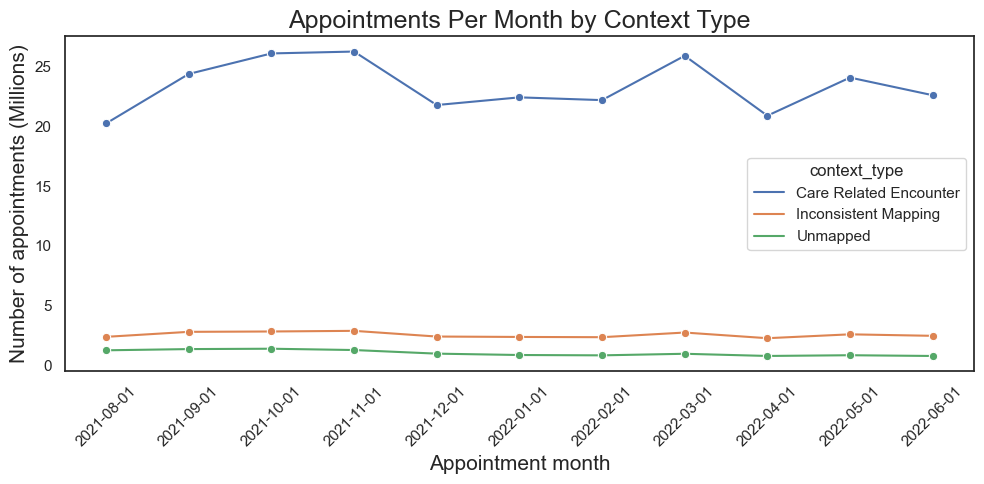

In [79]:
# Appointment by conyext type - plot a line chart

# Group by month and service setting
monthly_context_counts = nc_clean.groupby(['appointment_month', 'context_type'])['count_of_appointments'].sum().reset_index(name='appointment_count')

# Convert counts to millions
monthly_context_counts['appointment_count'] = monthly_context_counts['appointment_count'] / 1_000_000

# Plot line chart with hue for context type
plt.figure(figsize=(10, 5))
sns.lineplot(
    data=monthly_context_counts, 
    x='appointment_month', 
    y='appointment_count', 
    hue='context_type', 
    marker='o'
)

# Set title, axis labels and sticks
plt.title('Appointments Per Month by Context Type', fontsize=18)
plt.ylabel('Number of appointments (Millions)', fontsize=15)
plt.xlabel('Appointment month', fontsize=15)
plt.xticks(rotation=45)
plt.tight_layout()

# View outpuy
plt.show()


#### It can be seen that 'Inconsistent mapping' and 'Unmapped' continue to be an issue causing data quality issues in the analysis

## 11h National Categoies: Number of Monthly / Daily Appointments


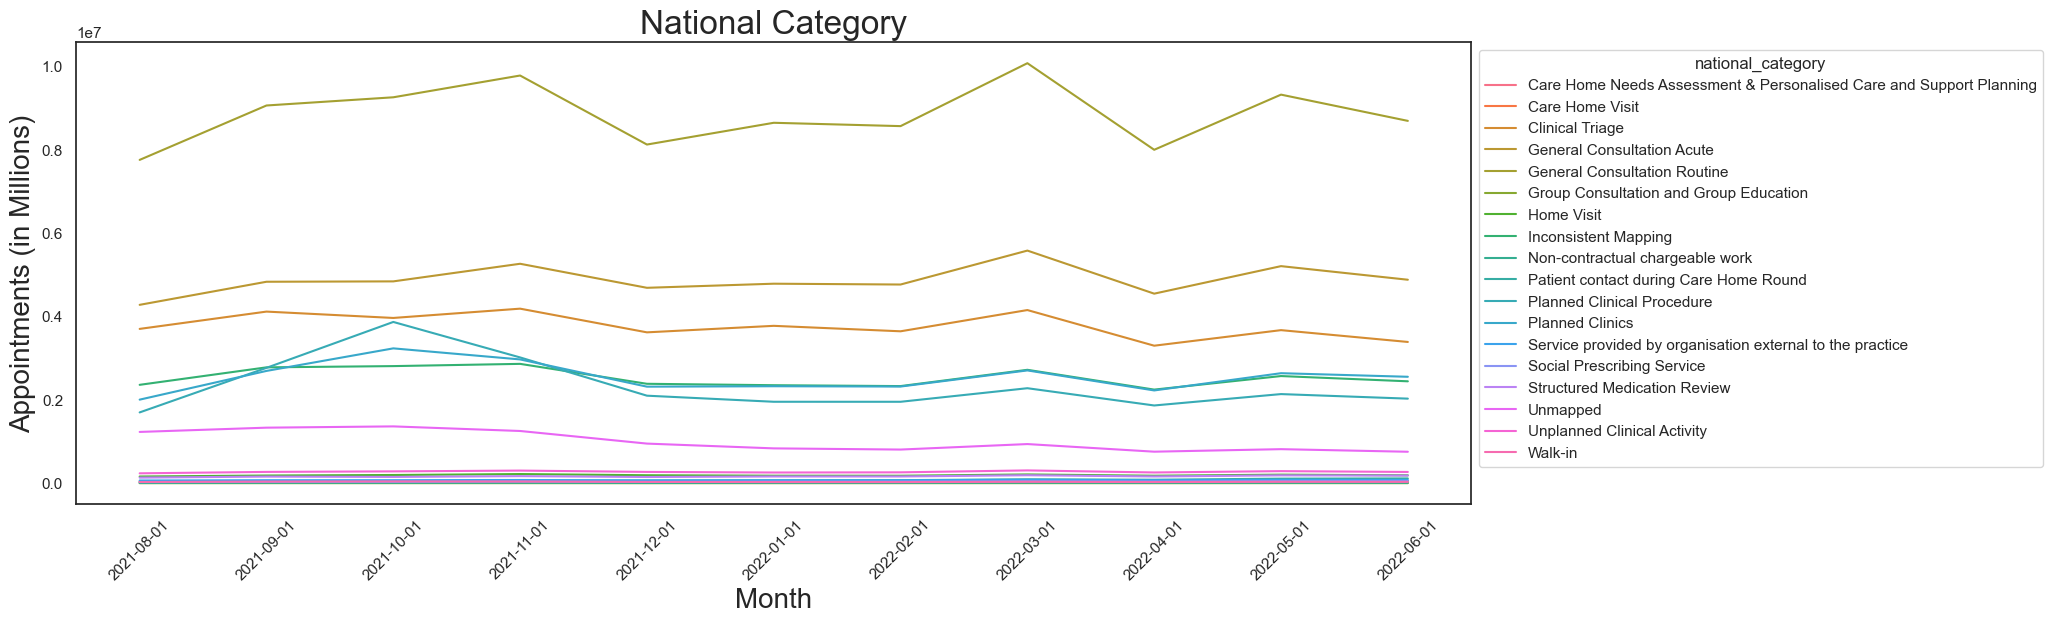

In [80]:
# Create National Categories Type lineplot of number of appointments by month

# Specify which columns to sum instead of summing all columns
nat_cat = nc_clean.groupby(['national_category','appointment_month']).agg({'count_of_appointments': 'sum'}).reset_index()
nat_cat

# Enlarge the plot.
plt.figure(figsize=(18, 6))
ax2 = sns.lineplot(
    x= 'appointment_month', 
    y= 'count_of_appointments', 
    data=nat_cat, 
    hue='national_category', 
    ci=None
)

# Move the legend.
sns.move_legend(
    ax2, 
    "upper left", 
    bbox_to_anchor=(1, 1)
)

# Title, sticks and labels
ax2.set_title('National Category', fontsize=24)
plt.xlabel("Month", fontsize=20)
plt.ylabel("Appointments (in Millions)", fontsize=20)
plt.xticks(rotation=45)

# Save the plot.
plt.savefig('national_categories.png')


#### The graph shows how the National Categoreis have varied by appointment numbers over the period - General consultation routine being the most common

#### A 'day of week' and 'day of week index' were added to the national_categories' dataframe. This allows appointments to be analysed on a daily rather than monthly level

In [81]:
# A day of the week index and day of week name columns were added to the nc_clean dataframe
# Add 'day_of_week' columns for subsequent analysis of appointments by day.
nc_clean['day_of_week'] = nc_clean['appointment_date'].dt.day_name()
nc_clean['day_of_week_index'] = nc_clean['appointment_date'].dt.dayofweek

# View output.
nc_clean.info()
nc_clean.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 817394 entries, 0 to 817393
Data columns (total 10 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   appointment_date       817394 non-null  datetime64[ns]
 1   icb_ons_code           817394 non-null  object        
 2   sub_icb_location_name  817394 non-null  object        
 3   service_setting        817394 non-null  object        
 4   context_type           817394 non-null  object        
 5   national_category      817394 non-null  object        
 6   count_of_appointments  817394 non-null  int64         
 7   appointment_month      817394 non-null  object        
 8   day_of_week            817394 non-null  object        
 9   day_of_week_index      817394 non-null  int64         
dtypes: datetime64[ns](1), int64(2), object(7)
memory usage: 62.4+ MB


,appointment_date,icb_ons_code,sub_icb_location_name,service_setting,context_type,national_category,count_of_appointments,appointment_month,day_of_week,day_of_week_index
0,2021-08-02,E54000050,NHS North East and North Cumbria ICB - 00L,Primary Care Network,Care Related Encounter,Patient contact during Care Home Round,3,2021-08-01,Monday,0
1,2021-08-02,E54000050,NHS North East and North Cumbria ICB - 00L,Other,Care Related Encounter,Planned Clinics,7,2021-08-01,Monday,0
2,2021-08-02,E54000050,NHS North East and North Cumbria ICB - 00L,General Practice,Care Related Encounter,Home Visit,79,2021-08-01,Monday,0
3,2021-08-02,E54000050,NHS North East and North Cumbria ICB - 00L,General Practice,Care Related Encounter,General Consultation Acute,725,2021-08-01,Monday,0
4,2021-08-02,E54000050,NHS North East and North Cumbria ICB - 00L,General Practice,Care Related Encounter,Structured Medication Review,2,2021-08-01,Monday,0


## 11i Number of Appointments by ICB Location

In [82]:
# This returns total appointments by sub_ICB_location and sorts them in descending order from nc_clean
# This code also renames the columns and returns the top five records.
nc_top_locs = nc_clean.groupby('sub_icb_location_name')[['count_of_appointments']]\
        .sum().sort_values('count_of_appointments', ascending=False).head()\
        .reset_index()\
        .rename(columns={'sub_icb_location_name':'Sub ICB Location',\
                         'count_of_appointments':'Total Appointments in nc'})

# Calculate and print the sum of appointments in nc.
total_nc = nc_clean['count_of_appointments'].sum()
print("Total appointments in nc:",total_nc)

# Add '% of Total' column and view the top 5 in a table.
nc_top_locs['% of Total'] = nc_top_locs['Total Appointments in nc']/total_nc * 100
nc_top_locs.round(1)  # Rounding percentahe to one decimal place

Total appointments in nc: 296046770


,Sub ICB Location,Total Appointments in nc,% of Total
0,NHS North West London ICB - W2U3Z,12142390,4.1
1,NHS North East London ICB - A3A8R,9588891,3.2
2,NHS Kent and Medway ICB - 91Q,9286167,3.1
3,NHS Hampshire and Isle Of Wight ICB - D9Y0V,8288102,2.8
4,NHS South East London ICB - 72Q,7850170,2.7


#### NHS North West London has the highest number of appointments by Sub ICB location

## 11j Monthly Appointments by Wait Time (Jan 2020 - June 2022) - COVID period

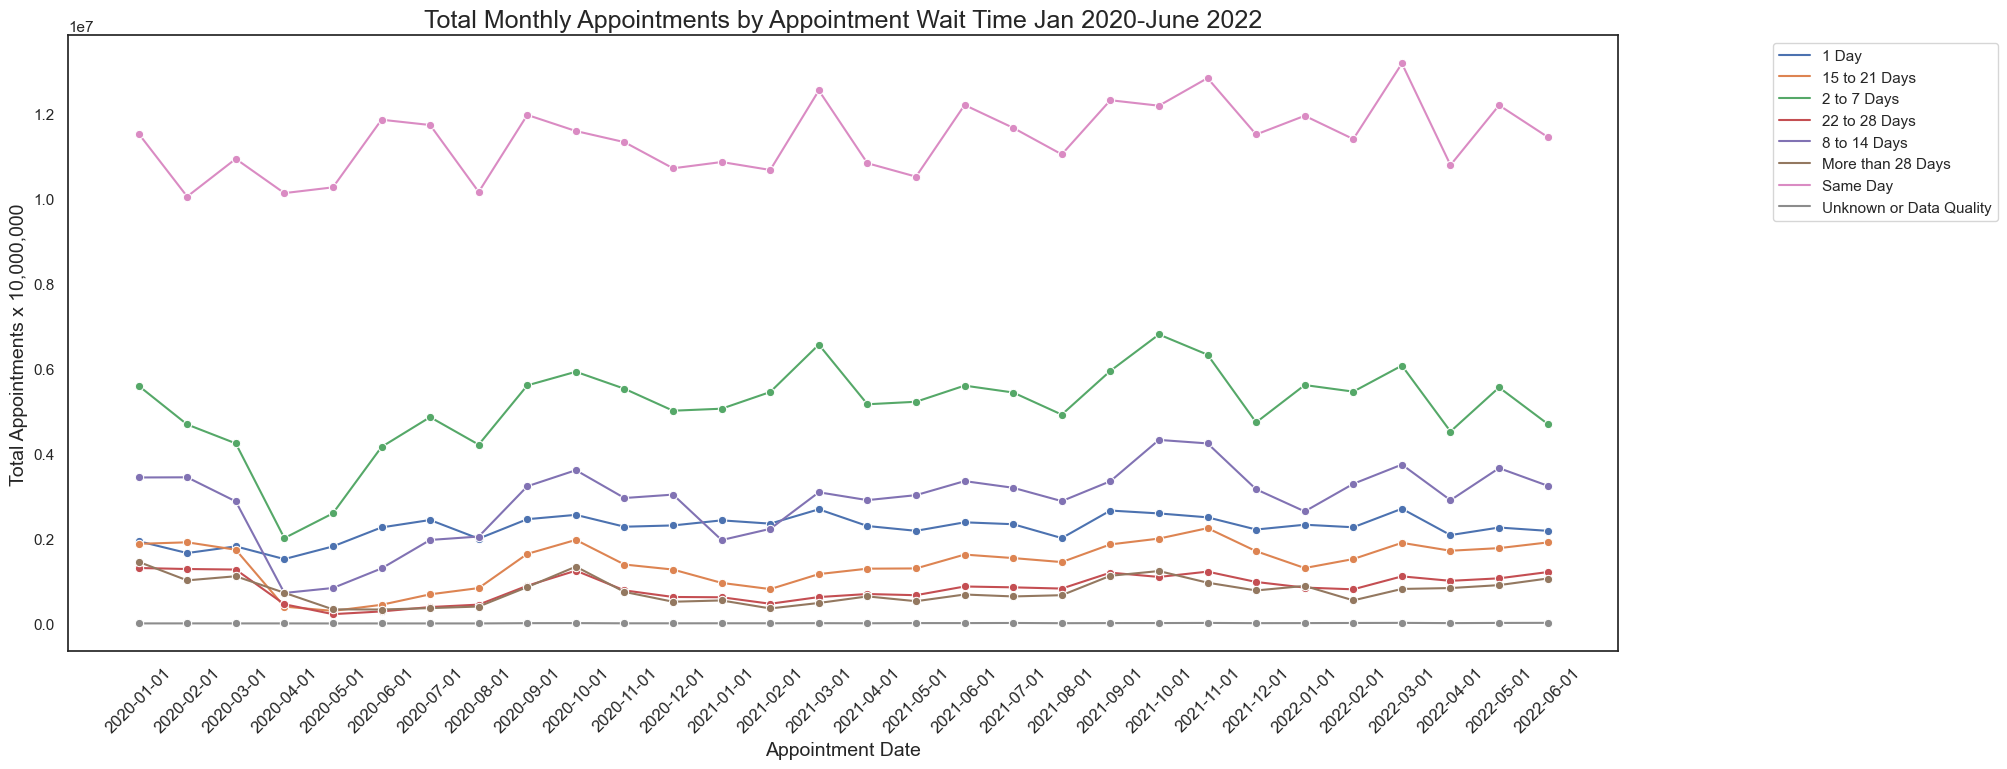

In [83]:
# Monthly appointments by wait time
# Aggregate on monthly level and determine the sum of records per month.
# Number of appointments per month == sum of count_of_appointments by month.

# Create subset DataFrame which excludes unknown wait times.
ar_wait = ar_clean[~ar_clean['time_between_book_and_appointment'].isin(['Unknown / Data Quality'])]

# Use the groupby() to group by month and book-appointment wait time.
ar_month_wait = ar_wait.groupby(['appointment_month',
                                  'time_between_book_and_appointment'])\
                                [['count_of_appointments']]\
                .sum()\
                .reset_index()\
                .rename(columns={'appointment_month':'Appointment Month',
                                 'time_between_book_and_appointment':'Appointment Wait Time',
                                 'count_of_appointments':'Total Appointments'})

# Plot a line graph of sum of appointments by month from the ar_clean DataFrame.
plt.figure(figsize=(20, 8))
sns.lineplot(
    data=ar_month_wait, 
    x='Appointment Month', 
    y='Total Appointments',
    hue='Appointment Wait Time',
    marker='o'
)

# Set title, axis labels, sticks and graph legend
plt.title('Total Monthly Appointments by Appointment Wait Time Jan 2020-June 2022', fontsize=18)
plt.xlabel('Appointment Date', fontsize=14)
plt.xticks(fontsize=12, rotation=45)
plt.ylabel('Total Appointments x 10,000,000', fontsize=14)
plt.legend(loc='upper right', bbox_to_anchor=(1.25, 1));

#### Most appointments are the same day as booking

# 12. Capacity Trends

## 12a Which days tend to have the  highest number of appointments

In [84]:
# Calculating the daily appointment count for each indivdual day (Monday - Sunday)
# Group by appointment_date and sum the appointments
daily_counts = nc_clean.groupby('appointment_date')['count_of_appointments'].sum().reset_index()

# Rename columns for clarity
daily_counts.columns = ['Appointment Date', 'Daily Appointment Count']

# Add day name column
daily_counts['Day of Week'] = daily_counts['Appointment Date'].dt.day_name()

# Display the result
daily_counts


,Appointment Date,Daily Appointment Count,Day of Week
0,2021-08-01,5627,Sunday
1,2021-08-02,1222768,Monday
2,2021-08-03,1169920,Tuesday
3,2021-08-04,1093532,Wednesday
4,2021-08-05,1074043,Thursday
...,...,...,...
329,2022-06-26,6574,Sunday
330,2022-06-27,1410883,Monday
331,2022-06-28,1335598,Tuesday
332,2022-06-29,1237258,Wednesday


Day of Week  Total Appointments (Millions)  % of Total
    Tuesday                          61.81        20.9
     Monday                          59.70        20.2
  Wednesday                          58.98        19.9
   Thursday                          56.98        19.2
     Friday                          52.39        17.7
   Saturday                           5.57         1.9
     Sunday                           0.61         0.2


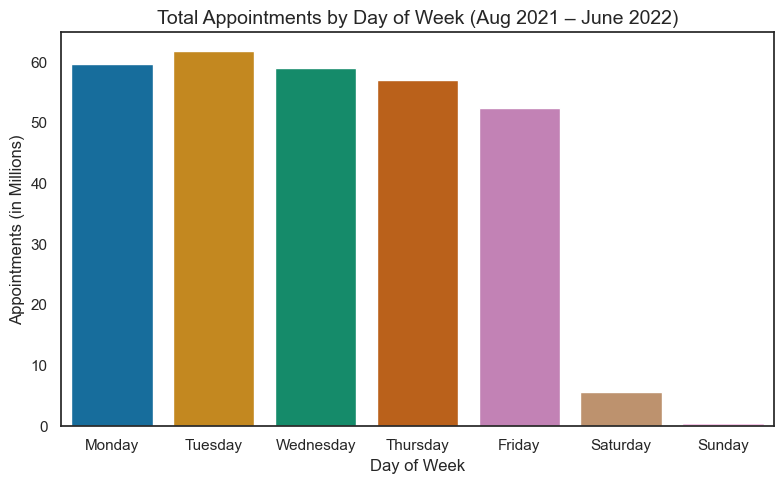

In [85]:
# Producing a barplot to show the total number of appointments by day for the period Aug-21 to June-22

# Map index to day name 
day_names = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

# Group by day of the week and sum appointments
nc_day_of_week = nc_clean.groupby('day_of_week_index')[['count_of_appointments']].sum().reset_index()

# Replace numeric index with day names
nc_day_of_week['Day of Week'] = nc_day_of_week['day_of_week_index'].map(dict(enumerate(day_names)))

# Scale counts to millions
nc_day_of_week['Total Appointments (Millions)'] = nc_day_of_week['count_of_appointments'] / 1000000

# Calculate total and percentage
total_appointments = nc_day_of_week['count_of_appointments'].sum()
nc_day_of_week['% of Total'] = (nc_day_of_week['count_of_appointments'] / total_appointments) * 100

# Sort by total appointments descending
nc_day_of_week = nc_day_of_week.sort_values('Total Appointments (Millions)', ascending=False)

# Round the numbers for display
nc_day_of_week = nc_day_of_week.round({'Total Appointments (Millions)': 2, '% of Total': 1})

# Print final table without index
print(nc_day_of_week[['Day of Week', 'Total Appointments (Millions)', '% of Total']].to_string(index=False))

# Sort by proper weekday order
nc_day_of_week = nc_day_of_week.sort_values('day_of_week_index')

# Plot a barplot
plt.figure(figsize=(8, 5))
sns.barplot(
    data=nc_day_of_week, 
    x='Day of Week', 
    y='Total Appointments (Millions)', 
    palette='colorblind'
)

# Set title, axis labels
plt.title("Total Appointments by Day of Week (Aug 2021 – June 2022)", fontsize=14)
plt.xlabel("Day of Week", fontsize=12)
plt.ylabel("Appointments (in Millions)", fontsize=12)
plt.tight_layout()
plt.show()


#### Tuesday is the most popular day for appointments, followed by Monday. As would be expected weekend days barely register

## 12b Which days tend to have the  highest number of appointments - How does this compare to capacity of 1.2M / day

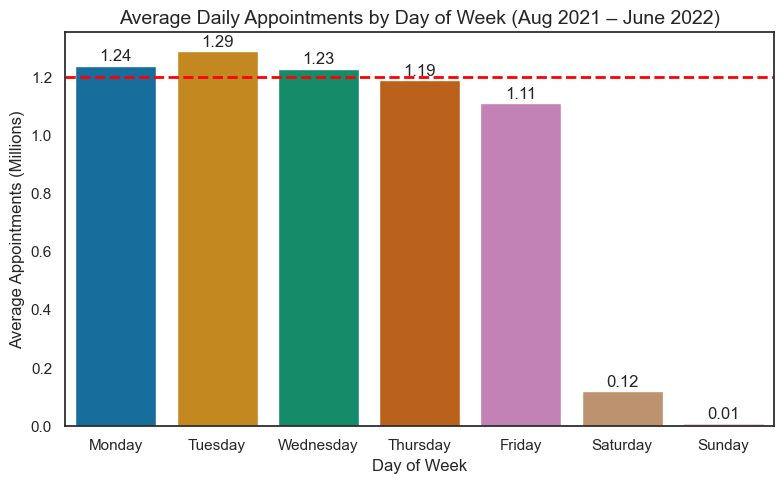


Average Daily Appointments by Day of Week (in millions):
Day of Week  Average Appointments (Millions)
     Monday                             1.24
    Tuesday                             1.29
  Wednesday                             1.23
   Thursday                             1.19
     Friday                             1.11
   Saturday                             0.12
     Sunday                             0.01


In [86]:
# Plot bar plot of average number of daily appointments to see if over capacity based on 1.2 million

# Appointments per day
# Get one row per date and weekday to count number of unique days for each weekday
weekday_day_counts = nc_clean[['appointment_date', 'day_of_week_index']].drop_duplicates()
weekday_counts = weekday_day_counts['day_of_week_index'].value_counts().sort_index()

# Total appointments per weekday
weekday_totals = nc_clean.groupby('day_of_week_index')['count_of_appointments'].sum()

# Calculate daily average
daily_avg = (weekday_totals / weekday_counts).reset_index()
daily_avg.columns = ['day_of_week_index', 'Average Appointments']

# Add weekday names
daily_avg['Day of Week'] = daily_avg['day_of_week_index'].map(dict(enumerate(day_names)))

# Scale and sort
daily_avg['Average Appointments (Millions)'] = daily_avg['Average Appointments'] / 1_000_000
daily_avg = daily_avg.sort_values('day_of_week_index')
daily_avg = daily_avg.round({'Average Appointments (Millions)': 2})

# bar Plot
plt.figure(figsize=(8, 5))  # Set plot size
ax = sns.barplot(
    data=daily_avg, 
    x='Day of Week', 
    y='Average Appointments (Millions)',
    palette='colorblind'
)

# Add data labels to give the actual number of daily appoinments by day
for container in ax.containers:
    ax.bar_label(container, padding=1)
                 
# Add horizontal line at 1.2 million as mwximum daily capacity
plt.axhline(y=1.2, color='red', linestyle='--', linewidth=2, label='Target: 1.2M')

# Plot the bar chart
plt.title("Average Daily Appointments by Day of Week (Aug 2021 – June 2022)", fontsize=14)
plt.xlabel("Day of Week", fontsize=12)
plt.ylabel("Average Appointments (Millions)", fontsize=12)
plt.tight_layout()
plt.show()

# Display as table below graphical barchart
print("\nAverage Daily Appointments by Day of Week (in millions):")
print(daily_avg[['Day of Week', 'Average Appointments (Millions)']].to_string(index=False))


#### The graph suggests Monday, Tuesday and Wednesday are above capacity in terms of appointments, with Tuesday being the worst

## 12c Appointments by Each Individual Day for the period

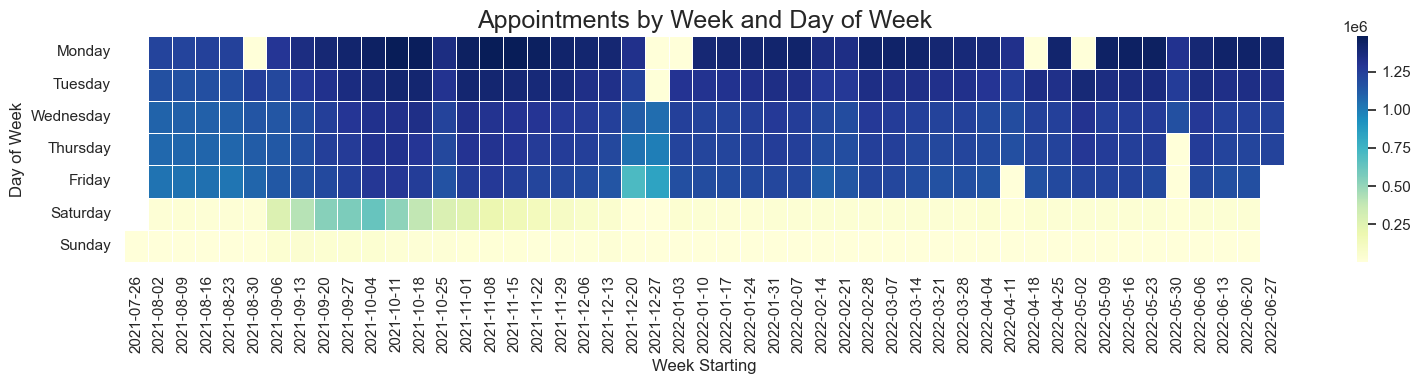

In [87]:
# Creating a heatmap to show the days with the highest numbers of appointments - The darker the coloir the higher the number
# A heatmap allows each individual day to be anal;yses rather than by week or month

# Ensuring the datetime column is in proper format
nc_clean['appointment_date'] = pd.to_datetime(nc_clean['appointment_date'])

# Strip time from datetime to keep only the date
nc_clean['appointment_date'] = nc_clean['appointment_date'].dt.date

# Create 'day_of_week' and 'week_start' columns
nc_clean['day_of_week'] = pd.to_datetime(nc_clean['appointment_date']).dt.day_name()
nc_clean['week_start'] = pd.to_datetime(nc_clean['appointment_date']) - pd.to_timedelta(pd.to_datetime(nc_clean['appointment_date'])\
                                                                                        .dt.dayofweek, unit='d')
nc_clean['week_start'] = nc_clean['week_start'].dt.date  # keep only the date

# Group by week and weekday, summing appointments
heatmap_data = nc_clean.groupby(['week_start', 'day_of_week'])['count_of_appointments'].sum().unstack()

# Reorder days
days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
heatmap_data = heatmap_data[days_order]

# Plot heatmap with title, axis labels and sticks
plt.figure(figsize=(16, 4))
sns.heatmap(heatmap_data.T, cmap="YlGnBu", linewidths=0.5)
plt.title('Appointments by Week and Day of Week', fontsize=18)
plt.xlabel('Week Starting')
plt.ylabel('Day of Week')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

#### The heatmap shows that the busiest days by appointment are not all the same. Indeed some Mondays have low/zero appointments - Bank Holidays? Interestingly there is an increase in appointments on Saturday between 06/09/2021 - 29/11/2021. Christmas and new year holidays are noted by the low/zero appointments on weekdays.

## 12d Appointment Wait Time by Month

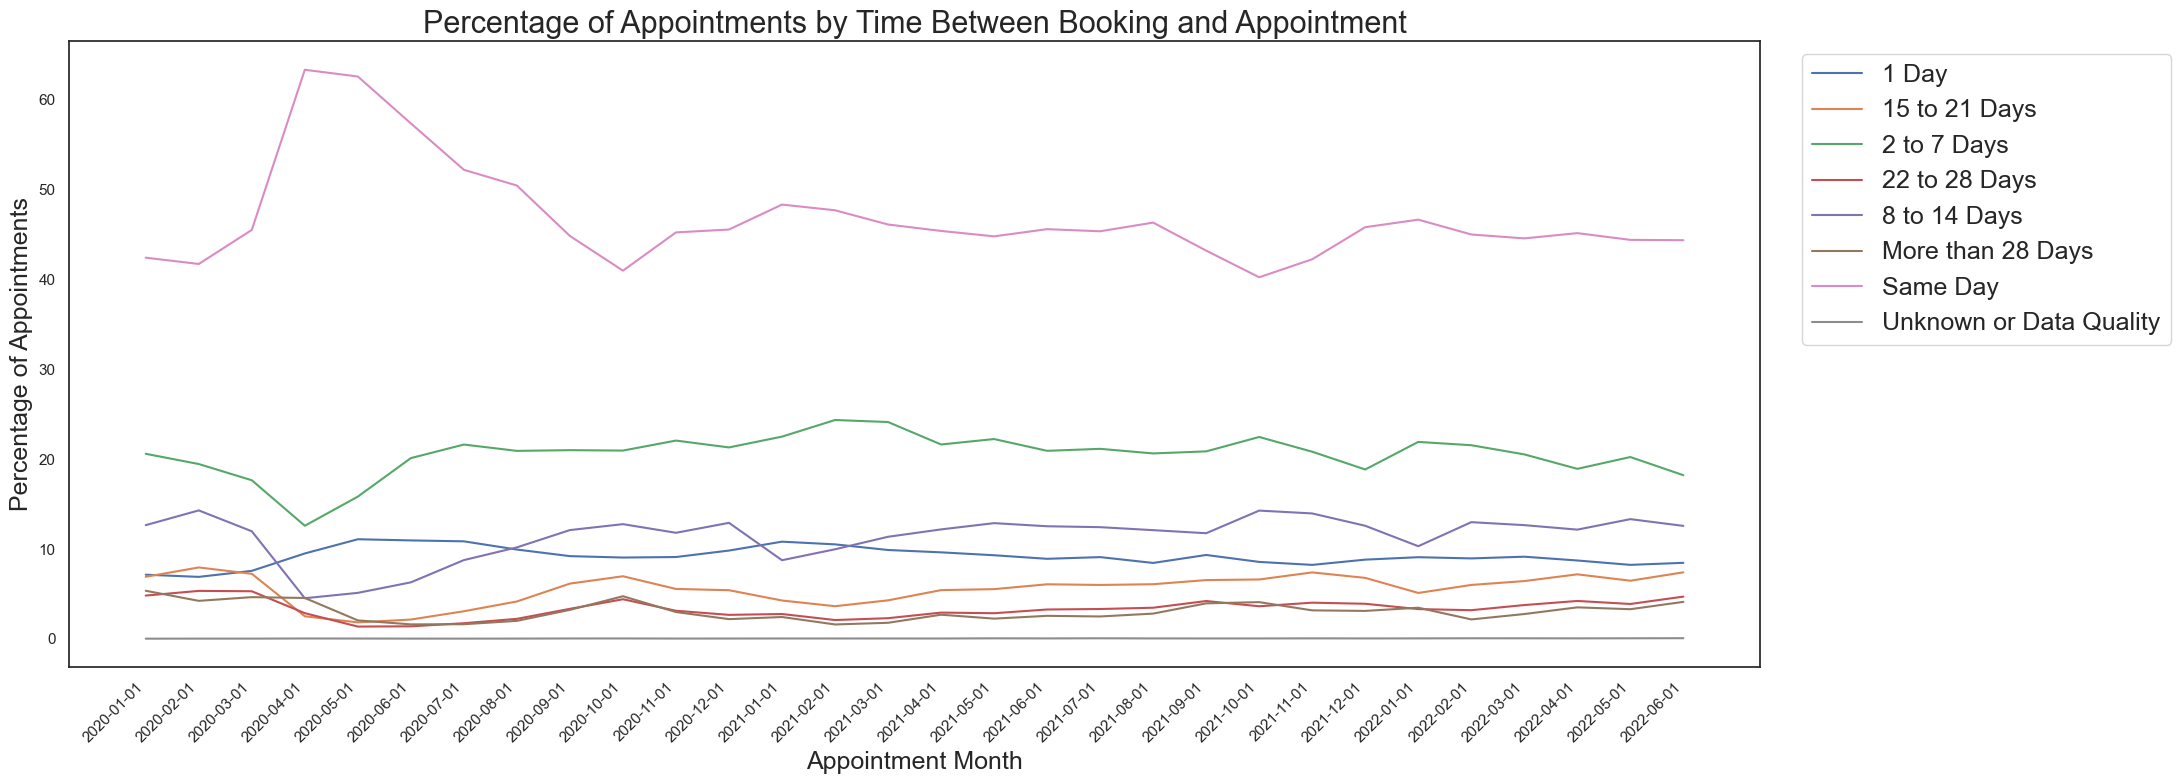

In [88]:
# Lineplot of appointment month by % of appointments showing book to appointment duration

# Group and sum appointment counts
time_book = (ar_clean.groupby(['time_between_book_and_appointment', 'appointment_month'])['count_of_appointments']
    .sum().reset_index())

# Calculate total appointments per month
monthly_totals = time_book.groupby('appointment_month')['count_of_appointments'].transform('sum')

# Calculate percentages
time_book['Percentage'] = (time_book['count_of_appointments'] / monthly_totals) * 100

# Plot graph
plt.figure(figsize=(22, 8))
ax = sns.lineplot(    
    data=time_book, 
    x='appointment_month', 
    y='Percentage', 
    hue='time_between_book_and_appointment')

# Title, labels and legebd box
plt.title('Percentage of Appointments by Time Between Booking and Appointment', fontsize=22)
plt.xlabel('Appointment Month', fontsize=18)
plt.ylabel('Percentage of Appointments', fontsize=18)
plt.xticks(rotation=45, ha='right')
plt.legend(loc='upper right', bbox_to_anchor=(1.25, 1), fontsize=18);
plt.tight_layout()
plt.show()


#### It can be seen that the number of same day appointments dropped in the second half of 2020 and then remained relatively steady for the duration of 2021/22

# 13 Seasonal Trends

### Visualisations of Number of appointments by season
Create four visualisations indicating the number of appointments for service setting per season. The seasons are summer (June to August 2021), autumn (September to November 2021), winter (December to February 2022), and spring (March to May 2022).

## 13a Summer (June to August)
#### Althought the season runs from June to August, we only have data for August 2021

In [89]:
# Creating a new datframe to give the count of appointments by service setting per day for the period
season = (nc_clean.groupby(['appointment_date', 'appointment_month', 'service_setting'])[['count_of_appointments']]
    .sum().reset_index())

# View the first 10 rows
season.head(10)


,appointment_date,appointment_month,service_setting,count_of_appointments
0,2021-08-01,2021-08-01,Extended Access Provision,438
1,2021-08-01,2021-08-01,General Practice,3411
2,2021-08-01,2021-08-01,Other,401
3,2021-08-01,2021-08-01,Primary Care Network,323
4,2021-08-01,2021-08-01,Unmapped,1054
5,2021-08-02,2021-08-01,Extended Access Provision,7705
6,2021-08-02,2021-08-01,General Practice,1108073
7,2021-08-02,2021-08-01,Other,22098
8,2021-08-02,2021-08-01,Primary Care Network,20016
9,2021-08-02,2021-08-01,Unmapped,64876


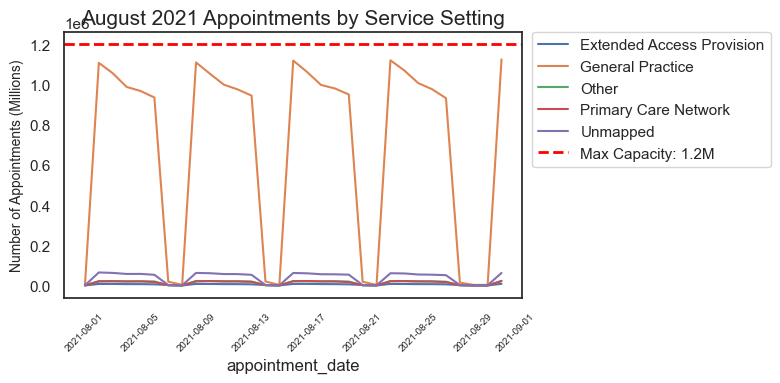

In [90]:
# Summer appointments
# Ensure column types are strictly mapped to datetime objects beforehand
season["appointment_month"] = pd.to_datetime(season["appointment_month"])
season["appointment_date"] = pd.to_datetime(season["appointment_date"])

# Convert the datetime object to a matching 'YYYY-MM' string format for filtering ---
summer = season[season["appointment_month"].dt.strftime("%Y-%m") == "2021-08"].copy()

# Create the lineplot
plt.figure(figsize=(8, 4))
ax_summer = sns.lineplot(
    x="appointment_date",
    y="count_of_appointments",
    data=summer,
    hue="service_setting",
    errorbar=None,  # Note: 'ci=None' is deprecated in newer Seaborn; changed to 'errorbar=None'
)

# Set ticks and axis labels
plt.xticks(rotation=45, fontsize=7)
plt.ylabel("Number of Appointments (Millions)", fontsize=10)

# Add horizontal line at 1.2 million as maximum daily capacity
plt.axhline(
    y=1200000,
    color="red",
    linestyle="--",
    linewidth=2,
    label="Max Capacity: 1.2M",
)

# Set chart title and legend box layout properties cleanly
ax_summer.set_title(
    "August 2021 Appointments by Service Setting", fontsize=15
)
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0)

plt.tight_layout()
plt.show()


#### GP appointments dominate the numbers.It can be seen that as the week progresses the number of appointments decreases, with a drop to almost zero at the weekend. It should also be noted that appointment numbers are below the 1.2 million daily capacity.All four weeks are very similar 

## 13b Autumn (September to November)

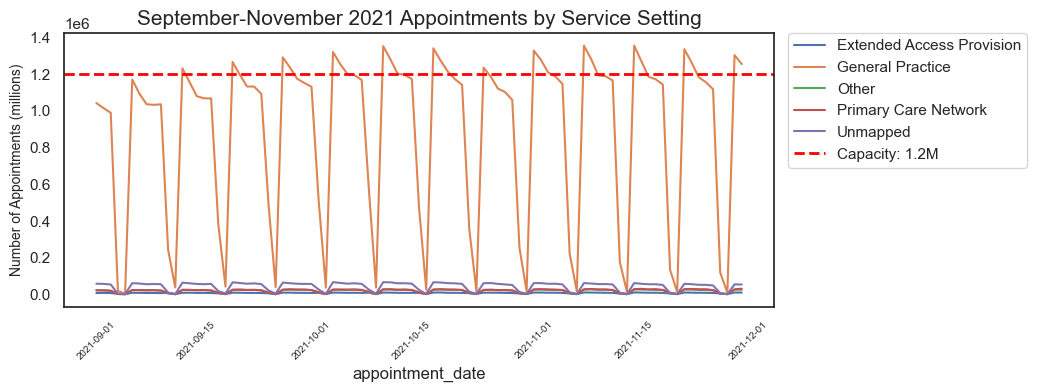

In [91]:
# Look at September to November 2021 in more detail to allow a closer look.
# Create a lineplot.
# Defining the Autumn season
autumn = season[(season['appointment_month'] >= '2021-09') & 
                (season['appointment_month'] <= '2021-11')]

# Convert appointment_date to datetime format
autumn['appointment_date'] = pd.to_datetime(autumn['appointment_date'])

# Create a lineplot.
plt.figure(figsize=(8, 4)),
ax_autumn = sns.lineplot(
    x="appointment_date", 
    y="count_of_appointments", 
    data=autumn, 
    hue='service_setting', 
    ci=None
)

# Set sticks and axis labels
plt.xticks(rotation=45, fontsize=7)
plt.ylabel('Number of Appointments (millions)', fontsize=10)
plt.tight_layout()

# Add horizontal line at 1.2 million as mwximum daily capacity
plt.axhline(y=1200000, color='red', linestyle='--', linewidth=2, label='Capacity: 1.2M')

# Set chart title and legend box
ax_autumn.axes.set_title("September-November 2021 Appointments by Service Setting", fontsize=15)  
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0)

# Save the graph
plt.savefig("ax_autumn.png")

#### In Autumn it can be seen that there is an increase in appointments (specifically GP) particularly from October. It then remains at this level fairly consistently throughout the season. This is to be expected and predictable. Also capacity is breached during this period.

## 13c Autumn (September to November 2021) - GP Removed

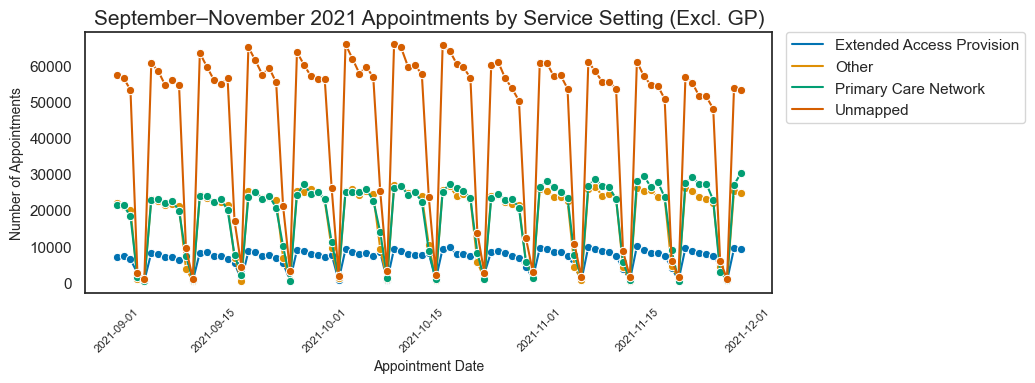

<Figure size 1500x1200 with 0 Axes>

In [92]:
# Remove General Practice from service_setting for a clearer understanding 
autumn_no_gp = autumn[autumn['service_setting'] != 'General Practice']

# Plot
plt.figure(figsize=(8, 4))
ax_autumn_no_gp = sns.lineplot(
    x="appointment_date", 
    y="count_of_appointments", 
    data=autumn_no_gp, 
    hue='service_setting',
    ci=None,       
    marker='o', 
    palette='colorblind'
)

# Create a lineplot and setting title, axis labels, rotating sticks by 45 degrees
ax_autumn_no_gp.set_title("September–November 2021 Appointments by Service Setting (Excl. GP)", fontsize=15)
ax_autumn_no_gp.set_xlabel("Appointment Date", fontsize=10)
ax_autumn_no_gp.set_ylabel("Number of Appointments", fontsize=10)
plt.xticks(rotation=45, fontsize=8)
plt.tight_layout()
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0)
plt.show()

# Save the graph
plt.savefig("ax_autumn_no_gp.png")


#### The same chart as previously for the Autumn 2021 season, but with GP appointments removed. This allows analysis of the other service settings. It can be seen that 'Unmapped' data now dominates, accounting for over 250,000 appointments per week. This lack of acurate data is a real issue facing the NHS, which affects planning and utilisation.

## 13d Winter (December to February 2022)

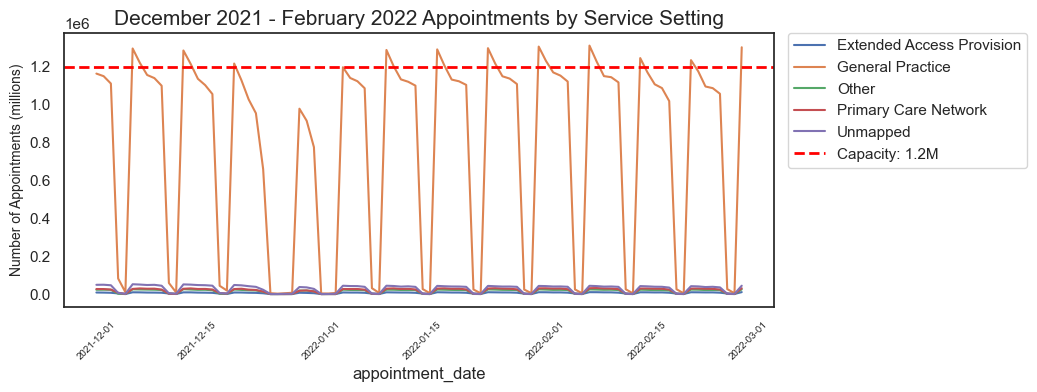

In [93]:
# Look at December to February 2022 in more detail to allow a closer look.

# Create a lineplot.
# Define the winter season
winter = season[(season['appointment_month'] >= '2021-12') & (season['appointment_month'] <= '2022-02')]  

# Convert appointment_date to datetime format
winter['appointment_date'] = pd.to_datetime(winter['appointment_date'])

# Create a lineplot.
plt.figure(figsize=(8, 4)),
ax_winter = sns.lineplot(    
    x="appointment_date", 
    y="count_of_appointments", 
    data=winter,
    hue='service_setting', 
    ci=None
)

# Set sticks and axis labels
plt.xticks(rotation=45, fontsize=7)
plt.ylabel('Number of Appointments (millions)', fontsize=10)
plt.tight_layout()

# Add horizontal line at 1.2 million as mwximum daily capacity
plt.axhline(y=1200000, color='red', linestyle='--', linewidth=2, label='Capacity: 1.2M')

# Add title and legend box
ax_winter.axes.set_title("December 2021 - February 2022 Appointments by Service Setting", fontsize=15)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0)

# Save the graph
plt.savefig("ax_winter.png")

#### The winter season sees more variety in appointment numbers. While the capacity is breached in most weeks, the end of week appointment numbers seem to be lower than in previous seasons. Christmas week (23/12/2021) stands out and has significantly less appointments acorss all service settings - to be expected. This then picks up in the new year when GP surgeries open up again, before returning to normal high levels. Interestingly service settings other than GP seem to be lower in the new year than they were in December.

## 13e Spring (March to May 2022)

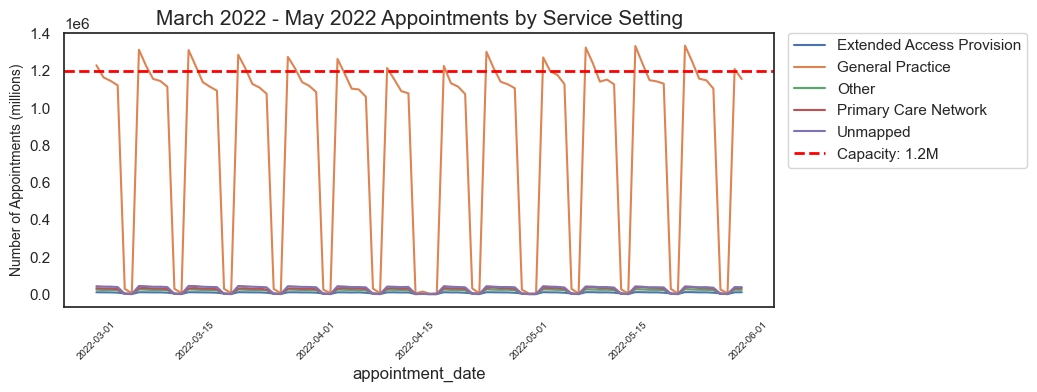

In [94]:
# Look at March to May 2022 in more detail to allow a closer look.
# Create a lineplot.
# Define the Spring season
spring = season[(season['appointment_month'] >= '2022-03') & (season['appointment_month'] <= '2022-05')]

# Convert appointment_date to datetime format
winter['appointment_date'] = pd.to_datetime(winter['appointment_date'])

# Create a lineplot.
plt.figure(figsize=(8, 4)),
ax_winter = sns.lineplot(x="appointment_date", y="count_of_appointments", data=spring, hue='service_setting', ci=None)
plt.xticks(rotation=45, fontsize=7)
plt.ylabel('Number of Appointments (millions)', fontsize=10)
plt.tight_layout()

# Add horizontal line at 1.2 million as mwximum daily capacity
plt.axhline(y=1200000, color='red', linestyle='--', linewidth=2, label='Capacity: 1.2M')

# Set the title and legend box
ax_winter.axes.set_title("March 2022 - May 2022 Appointments by Service Setting", fontsize=15) 
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0)

# Save the graph
plt.savefig("ax_spring.png")

#### In the Spring months there is an increase in appointments earlier in the week (Monday - Wednesday), which drops off below capacity levels in the second half of the week. This confirms earlier analysis findings. Interestingly there is a drop in appointments in the first half of April, in what is otherwise a faily steady season. This 2 week period brings apppintments just on or below capacity levels. Why? - Easter?
#### There also seems to be a drop in appointments for service settings other than GP in the second half of the season.

# 14. Appointments by Mode (In person, telephone etc)

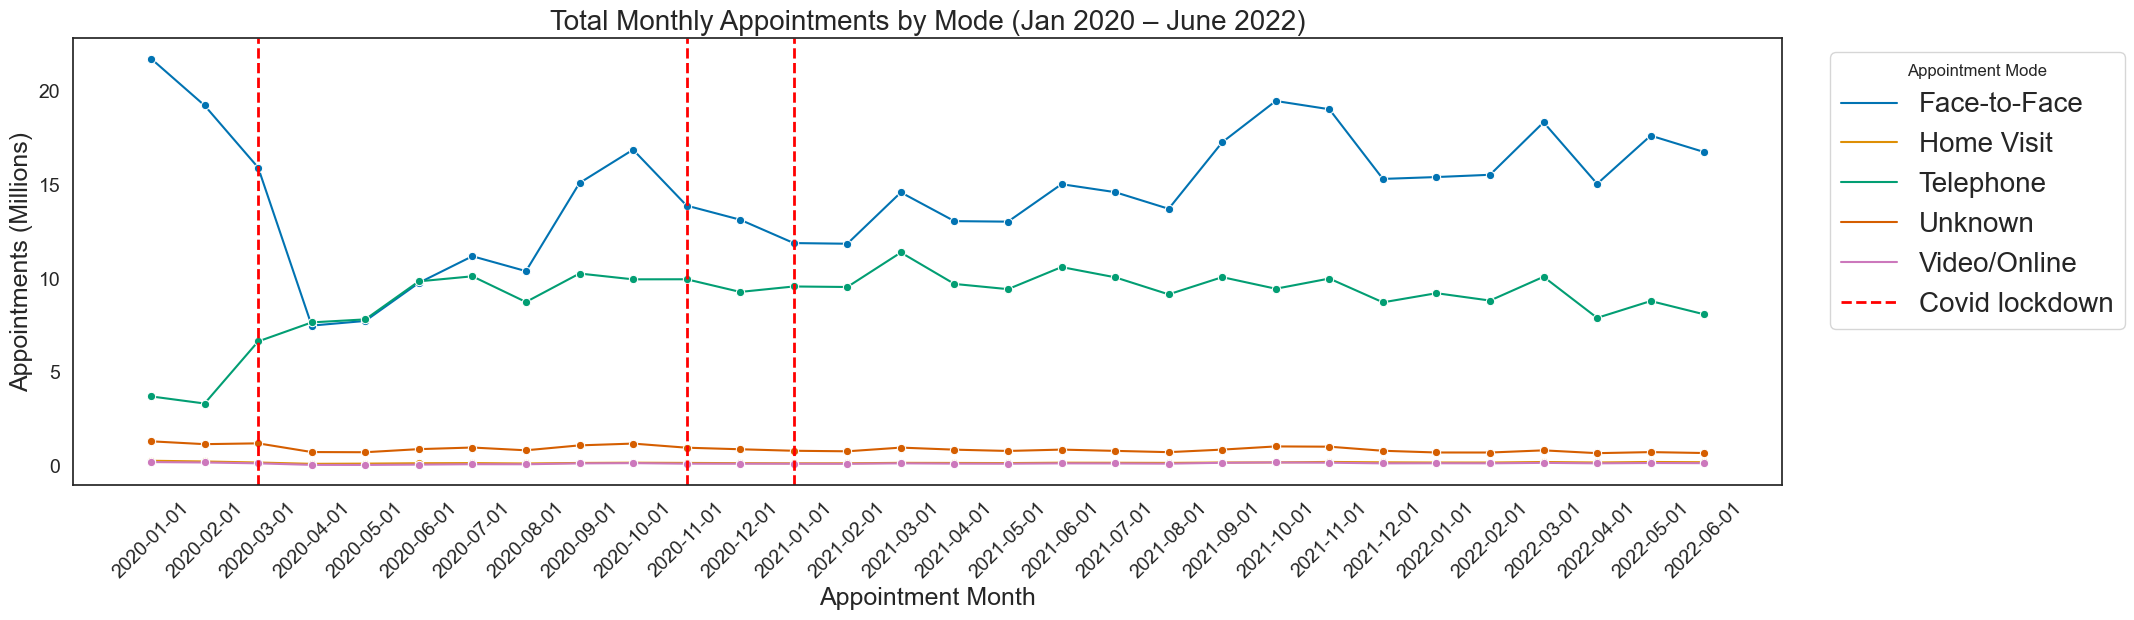

In [95]:
# Calculating total monthly appoinments by mode and plottinga line graph
# The period analysed is 01/2020 - 06/2020. This covers Covid lockdown periods so these will be marked on thr graph

# Ensure 'appointment_month' is string (for proper x-axis formatting)
ar_clean['appointment_month'] = ar_clean['appointment_month'].astype(str)

# Group by month and appointment mode
ar_month_mode = ar_clean.groupby(['appointment_month', 'appointment_mode'])[['count_of_appointments']].sum().reset_index()

# Scale appointments for readability (millions)
ar_month_mode['Appointments (Millions)'] = ar_month_mode['count_of_appointments'] / 1000000

# Plot lineplot
plt.figure(figsize=(18, 6))  # Set figure size
sns.lineplot(
    data=ar_month_mode, 
    x='appointment_month', 
    y='Appointments (Millions)', 
    hue='appointment_mode', 
    marker='o',
    palette='colorblind'
)

# Set ticks to 45 degrees
plt.xticks(rotation=45, fontsize=14)
plt.yticks(fontsize=14)
plt.tight_layout()

# Add vertical lines to signify the start of covid lockdown periods (unable to use the exact date so used the month instead)
plt.axvline(x='2020-03-01', color='red', linestyle='--', linewidth=2, label='Covid lockdown')
plt.axvline(x='2020-11-01', color='red', linestyle='--', linewidth=2)
plt.axvline(x='2021-01-01', color='red', linestyle='--', linewidth=2)

# Set title, axis labels and legend box
plt.title('Total Monthly Appointments by Mode (Jan 2020 – June 2022)', fontsize=20)
plt.xlabel('Appointment Month', fontsize=18)
plt.ylabel('Appointments (Millions)', fontsize=18)
plt.legend(title='Appointment Mode', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=20)

# Save the graph
plt.savefig("appoint_by_mode.png")

#### This plot shows a dramatic decrease in face to face appointments at March 2020 (Covid lockdown). At the sane time a smaller increase in telephone appointments occured. The numbers of telephone appointments continued at similar levels throughout the period whereas face to face saw two peaks. February 2021 saw a snall increase in both appointment modes. This was repeated in March 2022 but not so pronounced. During the period of the analysis face to face and telephone appointments don't return to pre-covid levels. Indeed telephone appointments have become more common and in some cases standard. This shows how an event can change a system forever.

## 14a Appointments by mode: Face to face and Telephone Only

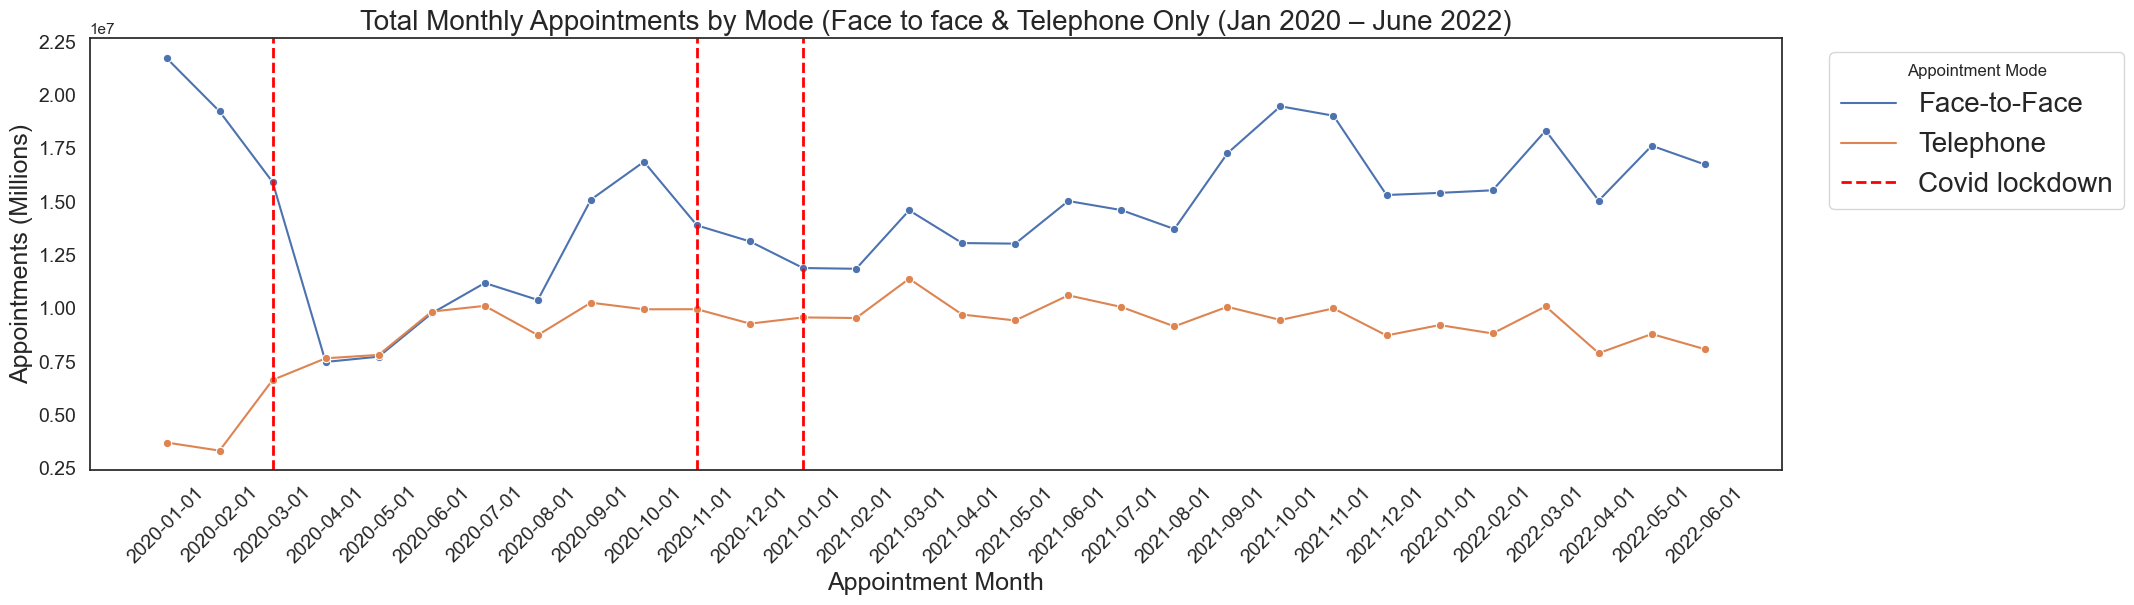

In [96]:
# Looking at face to face and telephone appointments only as they account for most appoinment modes

# Aggregate on monthly level and determine the sum of records per month.
# Number of appointments per month == sum of count_of_appointments by month.

# Create subset DataFrame with 'Telephone' and 'Face to Face' modes only.
# Use boolean indexing with isin() to filter for specific values
face_tele = ar_clean[ar_clean['appointment_mode'].isin(['Telephone', 'Face-to-Face'])]

# Use the groupby() to group by month and appointment mode.
ar_month_mode = face_tele.groupby(['appointment_month','appointment_mode'])[['count_of_appointments']].sum().reset_index()

# Plot a line graph of sum of appointments by month from the ar_clean DataFrame.
plt.figure(figsize=(18, 6))
sns.lineplot(
    data=ar_month_mode, 
    x='appointment_month', 
    y='count_of_appointments', 
    hue='appointment_mode', 
    marker='o'
)

# Set sticks to 45 degrees 
plt.xticks(rotation=45, fontsize=14)
plt.yticks(fontsize=14)
plt.tight_layout()

# Add vertical line to signify the start of covid lockdown periods (Unable to use the exact date)
plt.axvline(x='2020-03-01', color='red', linestyle='--', linewidth=2, label='Covid lockdown')
plt.axvline(x='2020-11-01', color='red', linestyle='--', linewidth=2)
plt.axvline(x='2021-01-01', color='red', linestyle='--', linewidth=2)

# Set title, labels and legend box
plt.title('Total Monthly Appointments by Mode (Face to face & Telephone Only (Jan 2020 – June 2022)', fontsize=20)
plt.xlabel('Appointment Month', fontsize=18)
plt.ylabel('Appointments (Millions)', fontsize=18)
plt.legend(title='Appointment Mode', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=20)

# Save the graph
plt.savefig("appoint_by_mode_ff_tele.png")


#### The same graph but all other appointment modes have been removed so we can cooncentrate on face to face and telephone. There has been a significant drop in face to face appoointments with a substantial increase in telephone based appointments over the same period )January 2020 - June 2022). The first covid lockdown (March 2020) showing a very sharp decline in face to face appointments, with a much smaller increase in telephone appointments. This reflects reality as routine appointments were scaled back or dropped.

# 15. Appointments: Non attendance

#### It is estimated that each missed appointment costs the NHS £30, not to mention appointments which could be givem to other patients. So this analysis sets out to invistigate whether this is a real issue and if so how big and what are the consequences.

## 15a Total monthly Appointments by Attendance Status (Attend / DNA)

In [97]:
# This returns total appointments by sub_ICB_location and sorts them in descending order from nc_clean.

# This code also renames the columns and returns the top five records.
nc_top_locs = nc.groupby('sub_icb_location_name')[['count_of_appointments']]\
        .sum().sort_values('count_of_appointments', ascending=False).head()\
        .reset_index()\
        .rename(columns={'sub_icb_location_name':'Sub ICB Location',\
                         'count_of_appointments':'Total Appointments in nc'})

# Calculate and print the sum of appointments in nc.
total_nc = nc['count_of_appointments'].sum()
print("Total appointments in nc:",total_nc)

# Add '% of Total' column and view the top 5 in a table.
nc_top_locs['% of Total'] = nc_top_locs['Total Appointments in nc']/total_nc * 100
nc_top_locs.round(1)

Total appointments in nc: 296046770


,Sub ICB Location,Total Appointments in nc,% of Total
0,NHS North West London ICB - W2U3Z,12142390,4.1
1,NHS North East London ICB - A3A8R,9588891,3.2
2,NHS Kent and Medway ICB - 91Q,9286167,3.1
3,NHS Hampshire and Isle Of Wight ICB - D9Y0V,8288102,2.8
4,NHS South East London ICB - 72Q,7850170,2.7


In [98]:
# Did not attent df for non-attendance only (ar_DNA)
ar_DNA = ar_clean[(ar_clean['appointment_status'] == 'DNA')]
ar_DNA

,icb_ons_code,appointment_month,appointment_status,hcp_type,appointment_mode,time_between_book_and_appointment,count_of_appointments,code,name,region_no
69,E54000034,2020-01-01,DNA,GP,Face-to-Face,1 Day,430,QNQ,NHS Frimley Integrated Care Board,19.0
70,E54000034,2020-01-01,DNA,GP,Face-to-Face,15 to 21 Days,452,QNQ,NHS Frimley Integrated Care Board,19.0
71,E54000034,2020-01-01,DNA,GP,Face-to-Face,2 to 7 Days,1249,QNQ,NHS Frimley Integrated Care Board,19.0
72,E54000034,2020-01-01,DNA,GP,Face-to-Face,22 to 28 Days,276,QNQ,NHS Frimley Integrated Care Board,19.0
73,E54000034,2020-01-01,DNA,GP,Face-to-Face,8 to 14 Days,797,QNQ,NHS Frimley Integrated Care Board,19.0
...,...,...,...,...,...,...,...,...,...,...
575165,E54000050,2022-06-01,DNA,Unknown,Unknown,15 to 21 Days,4,QHM,NHS North East and North Cumbria Integrated Ca...,30.0
575166,E54000050,2022-06-01,DNA,Unknown,Unknown,2 to 7 Days,8,QHM,NHS North East and North Cumbria Integrated Ca...,30.0
575167,E54000050,2022-06-01,DNA,Unknown,Unknown,22 to 28 Days,1,QHM,NHS North East and North Cumbria Integrated Ca...,30.0
575168,E54000050,2022-06-01,DNA,Unknown,Unknown,8 to 14 Days,7,QHM,NHS North East and North Cumbria Integrated Ca...,30.0


#### Plotting a Line graph of monthly appointments by attendance status

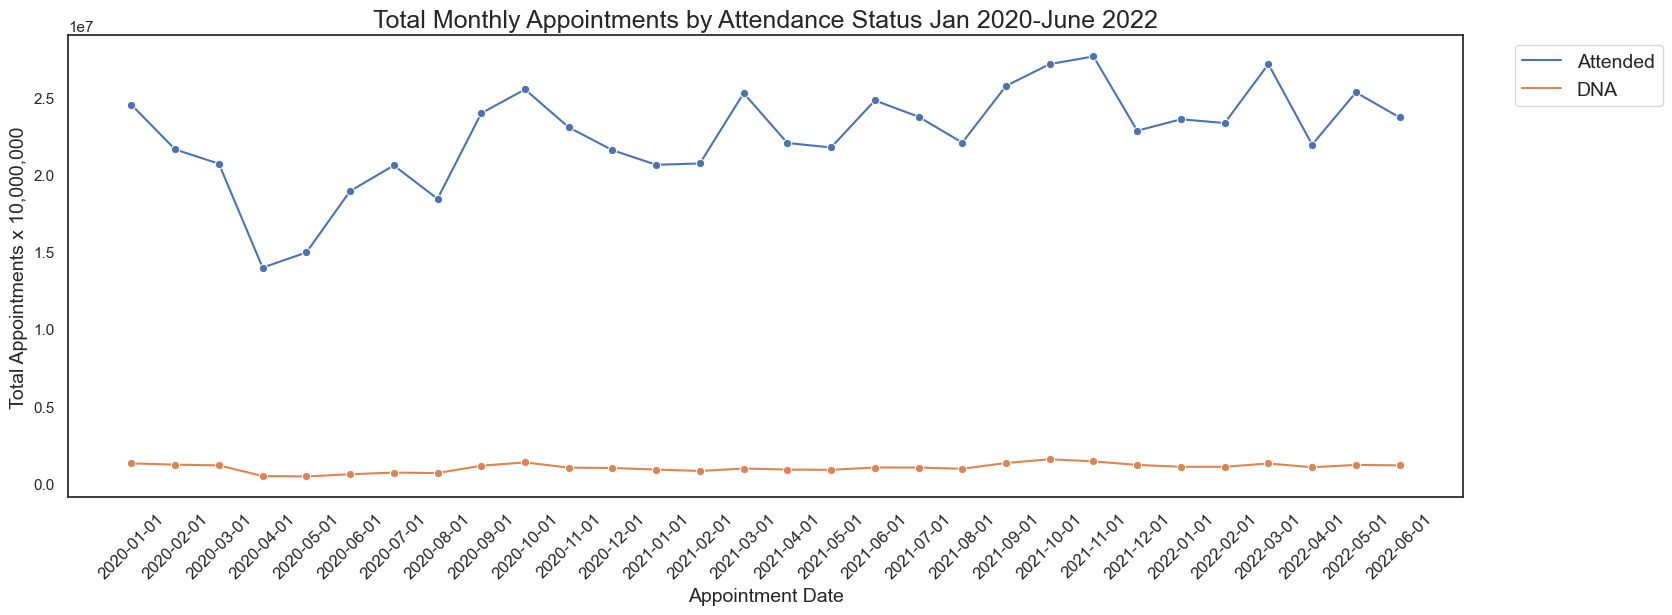

In [99]:
# Number of appointments per month by attendance status - Line graph 

# Aggregate on monthly level and determine the sum of records per month.
# Create subset DataFrame with 'Attended' and 'DNA' only.
ar_attend = ar_clean[ar_clean['appointment_status'].isin(['Attended','DNA'])]

# Use the groupby() to group by month and appointment status.
ar_month_status = ar_attend.groupby(
    ['appointment_month','appointment_status'])[['count_of_appointments']]\
        .sum().reset_index().rename(columns={'appointment_month':'Appointment Month',
                         'appointment_status':'Appointment Status',
                         'count_of_appointments':'Total Appointments'}
                                   )

# Plot a line graph of sum of appointments by month from the ar_clean DataFrame.
plt.figure(figsize=(18,6))
sns.lineplot(
    data=ar_month_status, 
    x='Appointment Month', 
    y='Total Appointments',
    hue='Appointment Status', 
    marker='o'
)
               
# Title, labelds and legend box
plt.title('Total Monthly Appointments by Attendance Status Jan 2020-June 2022', fontsize=18)
plt.xlabel('Appointment Date', fontsize=14)
plt.xticks(fontsize=12, rotation=45)
plt.ylabel('Total Appointments x 10,000,000', fontsize=14)
plt.legend(loc='upper right', bbox_to_anchor=(1.15, 1), fontsize=14);

#### The line graph shows the variance of attended and not attended appointments during the period 01/2020 -06/2022

#### Line graph of monthly appointments by attendance status - including Unknown and covid lockdown periods

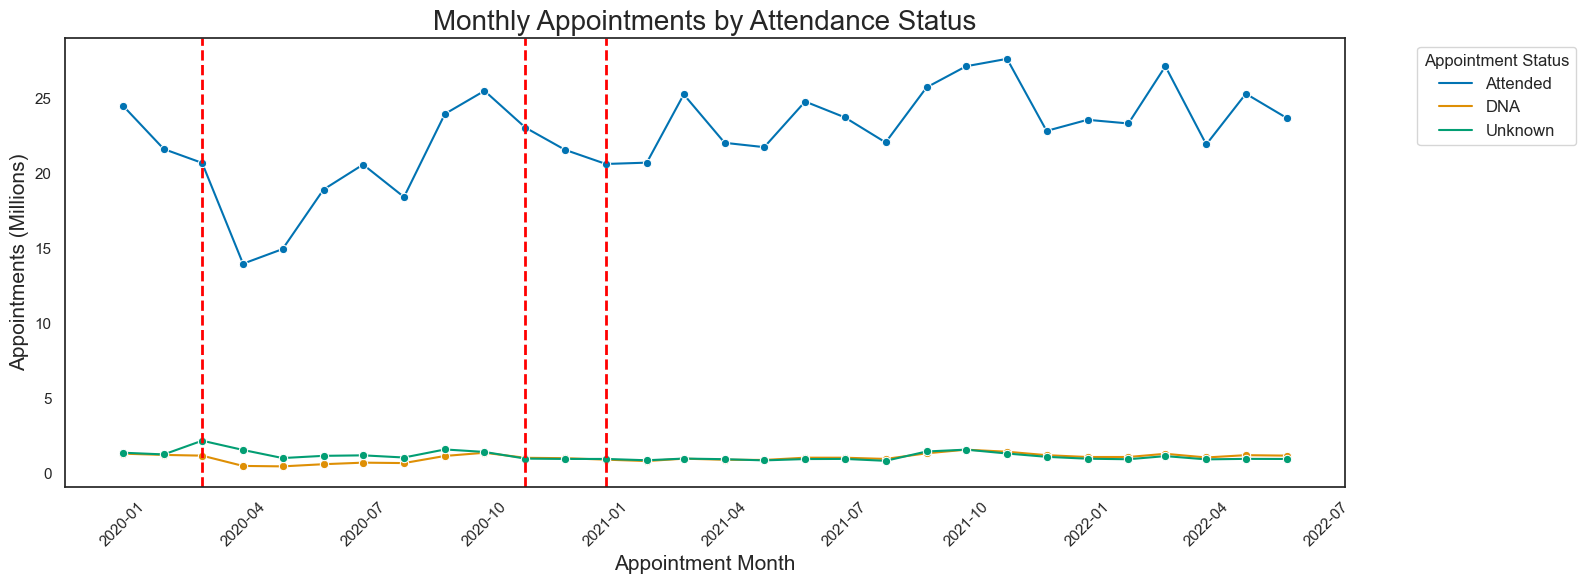

In [100]:
# Plot a linegraph showing appointment status by month - including covid lockdown markers and 'unknown' status

# Ensure 'appointment_month' is datetime and sorted
ar_clean['appointment_month'] = pd.to_datetime(ar_clean['appointment_month'])
attend_status = ar_clean.groupby(['appointment_month', 'appointment_status'])['count_of_appointments'].sum().reset_index()

# Scale appointments to millions
attend_status['Appointments (Millions)'] = attend_status['count_of_appointments'] / 1000000

# Sort by month for line continuity
attend_status = attend_status.sort_values('appointment_month')

# Plot
plt.figure(figsize=(16, 6))
sns.lineplot(
    data=attend_status,     
    x='appointment_month', 
    y='Appointments (Millions)', 
    hue='appointment_status', 
    marker='o',
    palette='colorblind'
)

# Add vertical lockdown markers using datetime
for lockdown_date in ['2020-03-01', '2020-11-01', '2021-01-01']:
    plt.axvline(
        x=pd.to_datetime(lockdown_date), 
        color='red', 
        linestyle='--', 
        linewidth=2, 
        label=None
    )

# Labels & formatting
plt.title('Monthly Appointments by Attendance Status', fontsize=20)
plt.xlabel('Appointment Month', fontsize=15)
plt.ylabel('Appointments (Millions)', fontsize=15)
plt.xticks(rotation=45)
plt.legend(title='Appointment Status', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=12)
plt.tight_layout()

# Save graph
plt.savefig("Attendance_status.png")

#### Over the period of the analysis (01/01/2020 - 01/06/2022) the number of booked appointments has varied considerably. This is particularly evident around Covid lockdowns (March 2020) - where the number of booked appointments dropped significantely. Did Not Attend (DNA) seems to have remained relatively consistent over the period - Or did it? There is again a drop during the March 2020 lockdown in line with less booked appointments. However the DNA figure isn't varying in the same way as attended appointments did.

#### Lets take a look at DNA and unknown in more detail, as those plots are overshadowed by attended - but are the most significant for the analysis. Do they reveal anything interesting?

#### There is a dramatic increase in the number of 'unknown' appointment attend status at the March 2020 lockdown.Presumably record keeping wasn't kept up to date or as maticulous during this time. At the same time there is a large reduction in DNAs, but then as the previous plot shows, the number of appointments also dropped dramatically so its logical for DNA to also drop. Also this drop in DNAs could be down to lack of reliable reporting.

#### Removing the 'attended' status from the graph to better analyse 'DNA' and 'Unknown' values

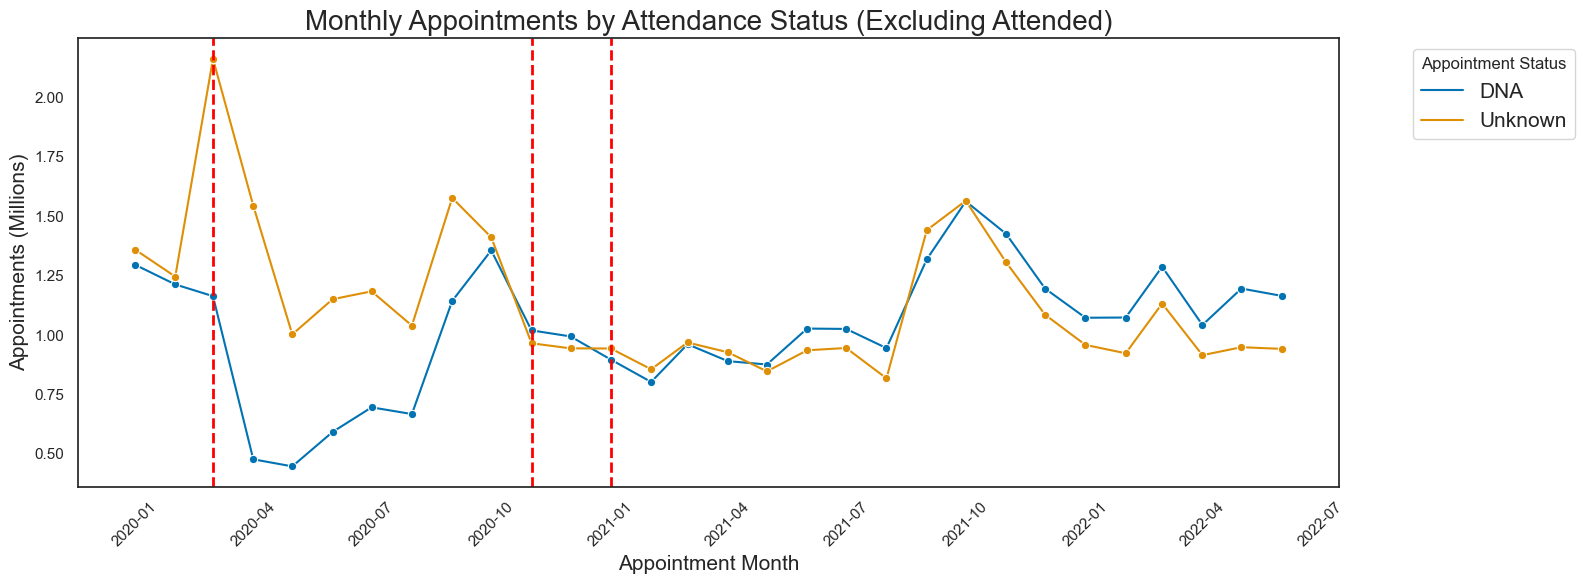

In [101]:
# Graph with attendance status - 'attended' status removed

# Ensure 'appointment_month' is datetime and sorted
ar_clean['appointment_month'] = pd.to_datetime(ar_clean['appointment_month'])

# Group by month and attendance status
attend_status = ar_clean.groupby(['appointment_month', 'appointment_status'])['count_of_appointments'].sum().reset_index()

# Exclude 'Attended' status
attend_status = attend_status[attend_status['appointment_status'] != 'Attended']

# Scale to millions
attend_status['Appointments (Millions)'] = attend_status['count_of_appointments'] / 1000000

# Sort by date
attend_status = attend_status.sort_values('appointment_month')

# Plot
plt.figure(figsize=(16, 6))
sns.lineplot(
    data=attend_status, 
    x='appointment_month', 
    y='Appointments (Millions)', 
    hue='appointment_status',
    marker='o', 
    palette='colorblind'
)

# Add vertical lockdown lines
for lockdown_date in ['2020-03-01', '2020-11-01', '2021-01-01']:
    plt.axvline(x=pd.to_datetime(lockdown_date), color='red', linestyle='--', linewidth=2, label=None)

# Title, axis labels, sticks andand formatting
plt.title('Monthly Appointments by Attendance Status (Excluding Attended)', fontsize=20)
plt.xlabel('Appointment Month', fontsize=15)
plt.ylabel('Appointments (Millions)', fontsize=15)
plt.xticks(rotation=45)
plt.legend(title='Appointment Status', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=15)
plt.tight_layout()

# Save graph
plt.savefig("Attendance_DNA.png")



#### With 'attended' removed the reality of 'DNA' and 'unknown' becomes clearer. The 'unknown' showing a significant spike at the start of the first Covid lockdown (March 2020). At the same time DNAs dropped - but was this due to unreliable reporting rather than an actual reduction? Both 'DNA; and 'unknown' increase again in autumn 2020 before dropping againing during the seconf lockdown. There are then small variances until Autumn 2021 when both rise. Why?

## 15b Missed Appointments by Wait Time (Time between booking and actual appointment) - % of Booked Appointments

#### Does the length of time between booking an appointment and actually attending an appointment have any affect on attendance?

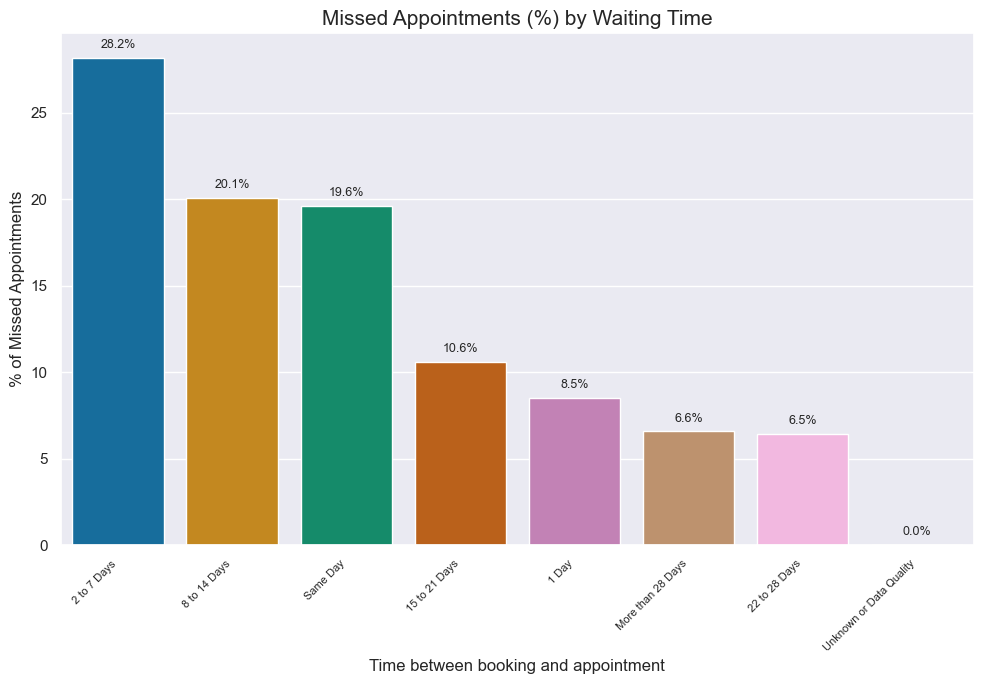

In [102]:
# Plot a chart to show % of DNAs by wait times

# Set figure size before plotting
sns.set(rc={'figure.figsize': (10, 7)})

# Groupby booking interval
ar_DNA_booking_time = (ar_DNA.groupby(['time_between_book_and_appointment'])[['count_of_appointments']]
    .sum().reset_index().rename(columns={'count_of_appointments': 'count_of_missed_appointments'}))

# Calculate percentages
total_missed = ar_DNA_booking_time['count_of_missed_appointments'].sum()
ar_DNA_booking_time['percentage'] = (ar_DNA_booking_time['count_of_missed_appointments'] / total_missed * 100)

# Sort values descending
ar_DNA_booking_time_ordered = ar_DNA_booking_time.sort_values(by='percentage', ascending=False)

# Plot barplot 
ax_DNA = sns.barplot(
    x='time_between_book_and_appointment', 
    y='percentage',     
    data=ar_DNA_booking_time_ordered, 
    palette='colorblind'
)

# Title, sticks and axis labels
plt.title('Missed Appointments (%) by Waiting Time', fontsize=15)
ax_DNA.set_xlabel("Time between booking and appointment", fontsize=12)
ax_DNA.set_ylabel("% of Missed Appointments", fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=8)

# Annotate each bar with the percentage value
for p in ax_DNA.patches:
    ax_DNA.annotate(f"{p.get_height():.1f}%",
                    (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='bottom', fontsize=9, xytext=(0, 5),
                    textcoords='offset points')

plt.tight_layout()
plt.show()


#### It can be seen that the highest percentage of appointments are not attended when they are between 2 - 7 days after booking. 22 days or longer have the owest levels. Interestingly same day appointments, nearly 1 in 5 (19.8%) are not attended. It could be assumed that with longer wait times, patients start to feel better so don't attend. This doesn't explain same day DNAs. Miraculous recovery??
#### In addition if patients no longer need an appointment or are unable to attend, why do they not cancel the appointment?

## 15c Missed Appointments by Wait Time (Analysis over the time period of the data)

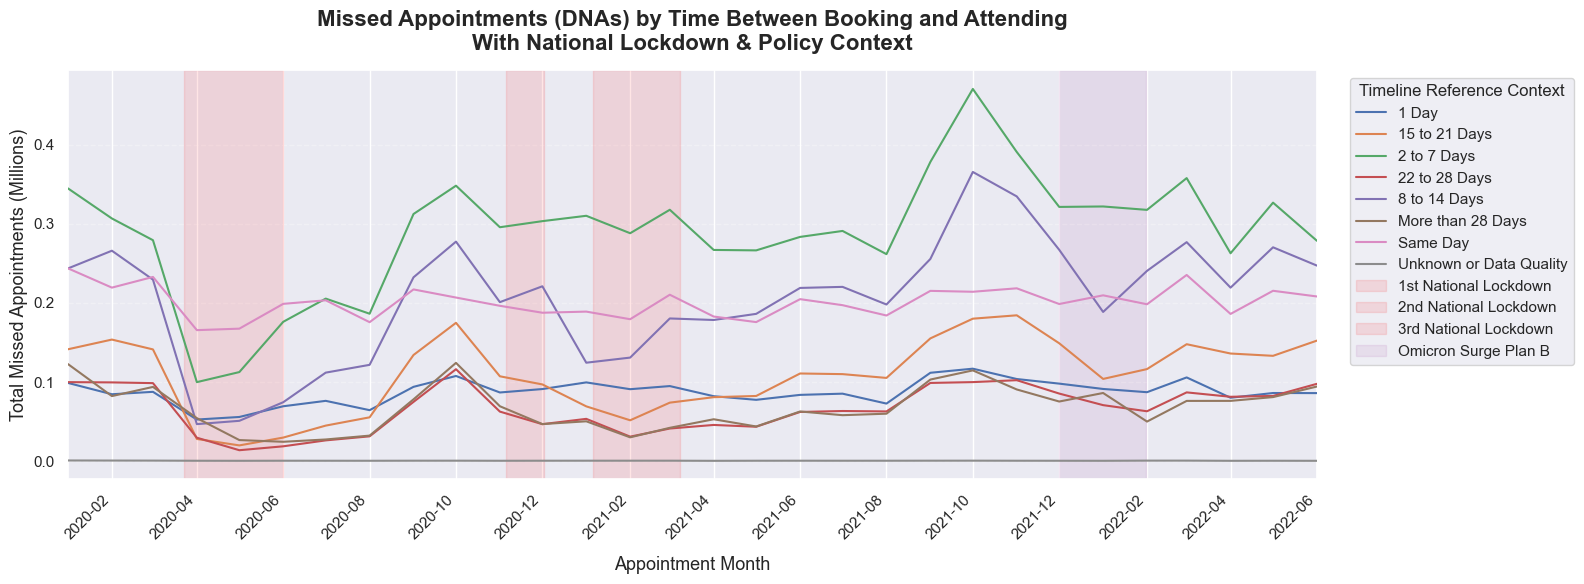

In [103]:
# Plotting DNA over the time period by time between booking and appopintment

# Ensure date format is clean
ar_clean["appointment_month"] = pd.to_datetime(ar_clean["appointment_month"])

# Filter using the exact dataset string match 'DNA'
dna_mask = ar_clean["appointment_status"] == "DNA"
dna_data = ar_clean[dna_mask].copy()

# Ensure string spacing is cleaned to prevent grouping traps
dna_data["time_between_book_and_appointment"] = (
    dna_data["time_between_book_and_appointment"]
    .astype(str)
    .str.strip()
    .str.replace(r"\s*/\s*", " or ", regex=True)
    .str.replace(r"\s+", " ", regex=True)
)

# Group the isolated DNA records by month and booking interval
ar_book_appoint_dna = (
    dna_data.groupby(
        ["appointment_month", "time_between_book_and_appointment"]
    )[["count_of_appointments"]]
    .sum()
    .reset_index()
)

# Scale missed appointments for readability (millions)
ar_book_appoint_dna["dna_appointments_millions"] = (
    ar_book_appoint_dna["count_of_appointments"] / 1000000
)

# Plot graph with context shading
fig, ax = plt.subplots(figsize=(16, 6))

# Plot the DNA data trend lines
sns.lineplot(
    x="appointment_month",
    y="dna_appointments_millions",
    hue="time_between_book_and_appointment",
    data=ar_book_appoint_dna,
    ax=ax,
    zorder=3,  # Forces trend lines to sit clearly on top of shading
)

# Set covid lockdown periods
lockdowns = [
    ("2020-03-23", "2020-06-01", "1st National Lockdown"),
    ("2020-11-05", "2020-12-02", "2nd National Lockdown"),
    ("2021-01-06", "2021-03-08", "3rd National Lockdown"),
]

for start, end, label in lockdowns:
    ax.axvspan(
        pd.to_datetime(start),
        pd.to_datetime(end),
        color="red",
        alpha=0.10,  # Subtle transparency so it doesn't block background data
        label=label,
    )

# Plan B/Omicron hsadding
ax.axvspan(
    pd.to_datetime("2021-12-01"),
    pd.to_datetime("2022-01-31"),
    color="purple",
    alpha=0.07,
    label="Omicron Surge Plan B",
)

# ==========================================
# Force the horizontal timeline limits to prevent floating gaps
ax.set_xlim(
    ar_book_appoint_dna["appointment_month"].min(),
    ar_book_appoint_dna["appointment_month"].max(),
)

# Map dynamic datetime markers along the baseline axis (Every 2 months)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))

# Set title, axis labels, and text properties
plt.title(
    "Missed Appointments (DNAs) by Time Between Booking and Attending\nWith National Lockdown & Policy Context",
    fontsize=16,
    weight="bold",
    pad=15,
)
plt.xlabel("Appointment Month", fontsize=13, labelpad=10)
plt.ylabel("Total Missed Appointments (Millions)", fontsize=13)
plt.xticks(rotation=45, ha="right", fontsize=11)
plt.yticks(fontsize=11)

# Smooth clean horizontal grid layer
plt.grid(axis="y", linestyle="--", alpha=0.3, zorder=0)

# Merge line labels and context shading handles seamlessly into one legend directory
handles, labels = ax.get_legend_handles_labels()
plt.legend(
    handles,
    labels,
    title="Timeline Reference Context",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    fontsize=11,
)

plt.tight_layout()

# Save the unified graph output asset
plt.savefig("dna_time_between_contextualized.png", dpi=300)
plt.show()

## 15d Missed Appointments by Service Setting

#### The dataframes 'appointments regional' (ar_clean) and 'national categories (nc_clean) will be merged as they each contain data necessary for this analysis - 'appointments regional' contains the attendance status and wsait time for appointment, while 'national categoried' contains the service setting data. They will be merged on the 'icb_ons_code' - the unique column in both datasets

#### Check for duplicates and merge the datasets

In [104]:
# Merge ar_clean and nc_clean
# Make new dataframes for this operation to preserve data
df_regional = ar_clean  # appointments_regional
df_national = nc_clean  # national_categories

# Check for duplicates 
print("Duplicates in df_regional:", df_regional['icb_ons_code'].duplicated().sum())
print("Duplicates in df_national:", df_national['icb_ons_code'].duplicated().sum())

# De-duplicate the national file 
df_national_dedup = df_national.drop_duplicates(subset='icb_ons_code')

#  Merge df_regional and df_national on 'icb_ons_code'
merged_df = pd.merge(df_regional, df_national_dedup, on='icb_ons_code', how='left')

# Show result
print("Merged shape:", merged_df.shape)
merged_df.head(100)


Duplicates in df_regional: 575175
Duplicates in df_national: 817352
Merged shape: (575217, 20)


,icb_ons_code,appointment_month_x,appointment_status,hcp_type,appointment_mode,time_between_book_and_appointment,count_of_appointments_x,code,name,region_no,appointment_date,sub_icb_location_name,service_setting,context_type,national_category,count_of_appointments_y,appointment_month_y,day_of_week,day_of_week_index,week_start
0,E54000034,2020-01-01,Attended,GP,Face-to-Face,1 Day,8107,QNQ,NHS Frimley Integrated Care Board,19.0,2021-08-01,NHS Frimley ICB - D4U1Y,General Practice,Inconsistent Mapping,Inconsistent Mapping,11,2021-08-01,Sunday,6,2021-07-26
1,E54000034,2020-01-01,Attended,GP,Face-to-Face,15 to 21 Days,6791,QNQ,NHS Frimley Integrated Care Board,19.0,2021-08-01,NHS Frimley ICB - D4U1Y,General Practice,Inconsistent Mapping,Inconsistent Mapping,11,2021-08-01,Sunday,6,2021-07-26
2,E54000034,2020-01-01,Attended,GP,Face-to-Face,2 to 7 Days,20686,QNQ,NHS Frimley Integrated Care Board,19.0,2021-08-01,NHS Frimley ICB - D4U1Y,General Practice,Inconsistent Mapping,Inconsistent Mapping,11,2021-08-01,Sunday,6,2021-07-26
3,E54000034,2020-01-01,Attended,GP,Face-to-Face,22 to 28 Days,4268,QNQ,NHS Frimley Integrated Care Board,19.0,2021-08-01,NHS Frimley ICB - D4U1Y,General Practice,Inconsistent Mapping,Inconsistent Mapping,11,2021-08-01,Sunday,6,2021-07-26
4,E54000034,2020-01-01,Attended,GP,Face-to-Face,8 to 14 Days,11971,QNQ,NHS Frimley Integrated Care Board,19.0,2021-08-01,NHS Frimley ICB - D4U1Y,General Practice,Inconsistent Mapping,Inconsistent Mapping,11,2021-08-01,Sunday,6,2021-07-26
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,E54000034,2020-01-01,DNA,Other Practice staff,Face-to-Face,2 to 7 Days,2123,QNQ,NHS Frimley Integrated Care Board,19.0,2021-08-01,NHS Frimley ICB - D4U1Y,General Practice,Inconsistent Mapping,Inconsistent Mapping,11,2021-08-01,Sunday,6,2021-07-26
96,E54000034,2020-01-01,DNA,Other Practice staff,Face-to-Face,22 to 28 Days,414,QNQ,NHS Frimley Integrated Care Board,19.0,2021-08-01,NHS Frimley ICB - D4U1Y,General Practice,Inconsistent Mapping,Inconsistent Mapping,11,2021-08-01,Sunday,6,2021-07-26
97,E54000034,2020-01-01,DNA,Other Practice staff,Face-to-Face,8 to 14 Days,1161,QNQ,NHS Frimley Integrated Care Board,19.0,2021-08-01,NHS Frimley ICB - D4U1Y,General Practice,Inconsistent Mapping,Inconsistent Mapping,11,2021-08-01,Sunday,6,2021-07-26
98,E54000034,2020-01-01,DNA,Other Practice staff,Face-to-Face,More than 28 Days,485,QNQ,NHS Frimley Integrated Care Board,19.0,2021-08-01,NHS Frimley ICB - D4U1Y,General Practice,Inconsistent Mapping,Inconsistent Mapping,11,2021-08-01,Sunday,6,2021-07-26


#### Find DNA appointments

In [105]:
# Finding DNA appointments

# Drop rows with missing or invalid values
filtered_df = merged_df.dropna(subset=['sub_icb_location_name', 'appointment_status', 'count_of_appointments_x'])
filtered_df['count_of_appointments_x'] = pd.to_numeric(filtered_df['count_of_appointments_x'], errors='coerce')
filtered_df = filtered_df.dropna(subset=['count_of_appointments_x'])

# Group by sub_icb_location_name and appointment_status
grouped = filtered_df.groupby(['sub_icb_location_name', 'appointment_status'])['count_of_appointments_x'].sum().reset_index()

# Calculate percentage within each sub_icb_location_name
grouped['total_per_location'] = grouped.groupby('sub_icb_location_name')['count_of_appointments_x'].transform('sum')
grouped['percentage'] = (grouped['count_of_appointments_x'] / grouped['total_per_location']) * 100

# Format percentage to 1 decimal
grouped['percentage'] = grouped['percentage'].round(1)

# View head 100
grouped.head(100)




,sub_icb_location_name,appointment_status,count_of_appointments_x,total_per_location,percentage
0,NHS Bath and North East Somerset Swindon and W...,Attended,12528475,13639181,91.9
1,NHS Bath and North East Somerset Swindon and W...,DNA,404831,13639181,3.0
2,NHS Bath and North East Somerset Swindon and W...,Unknown,705875,13639181,5.2
3,NHS Bedfordshire Luton and Milton Keynes ICB -...,Attended,11303414,12275331,92.1
4,NHS Bedfordshire Luton and Milton Keynes ICB -...,DNA,440628,12275331,3.6
...,...,...,...,...,...
95,NHS Nottingham and Nottinghamshire ICB - 02Q,Unknown,790559,16080009,4.9
96,NHS Shropshire Telford and Wrekin ICB - M2L0M,Attended,6012723,6513481,92.3
97,NHS Shropshire Telford and Wrekin ICB - M2L0M,DNA,260809,6513481,4.0
98,NHS Shropshire Telford and Wrekin ICB - M2L0M,Unknown,239949,6513481,3.7


#### Create a barplot of DNA appointments

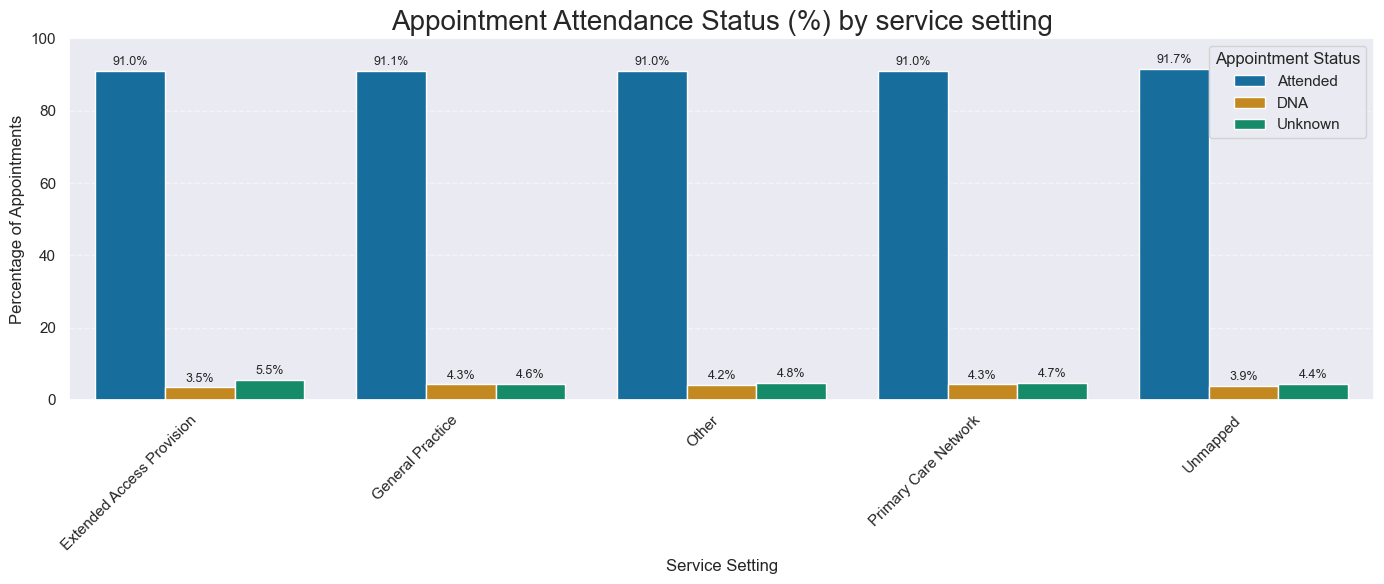

In [106]:
# Creating a barplot of DNA appoinments by service setting

# Appointment attendance by service setting
# Clean the data
filtered_df = merged_df.dropna(subset=['service_setting', 'appointment_status', 'count_of_appointments_x'])
filtered_df['count_of_appointments_x'] = pd.to_numeric(filtered_df['count_of_appointments_x'], errors='coerce')
filtered_df = filtered_df.dropna(subset=['count_of_appointments_x'])

# Group and calculate percentage per service setting
grouped = filtered_df.groupby(['service_setting', 'appointment_status'])['count_of_appointments_x'].sum().reset_index()
grouped['total_per_setting'] = grouped.groupby('service_setting')['count_of_appointments_x'].transform('sum')
grouped['percentage'] = grouped['count_of_appointments_x'] / grouped['total_per_setting'] * 100

# Plot grouped barplot
plt.figure(figsize=(14, 6))
ax = sns.barplot(
    data=grouped, 
    x='service_setting', 
    y='percentage', 
    hue='appointment_status', 
    palette='colorblind'
)

# Add percentage labels to each bar
for container in ax.containers:
    ax.bar_label(
        container, 
        fmt='%.1f%%', 
        label_type='edge', 
        fontsize=9, 
        padding=2
    )

# Title, labels and legend box
plt.title('Appointment Attendance Status (%) by service setting', fontsize=20)
plt.xlabel('Service Setting', fontsize=12)
plt.ylabel('Percentage of Appointments', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.ylim(0, 100)
plt.legend(title='Appointment Status')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

#### While the vast majority of appointments are attended across all service settings, there is a DNA of between 3.5% - 4.2%. Of particular concern is the Unknown DNA status. Thuis ranges from 4.4% - 5.5%. We don't know if these appointment are indeed DNA or were attended. This is a data quality and collection isssue. The DNA figures could be a lot worse than the data shows - potentially 9% of appointments - but we can only use data we have and not make assumptions.

## 15e Missed Appointments by Sub-ICB Region

#### Now looking at how Sub-ICB Regions compare when it comes to missed appointments. Are some worse than others?

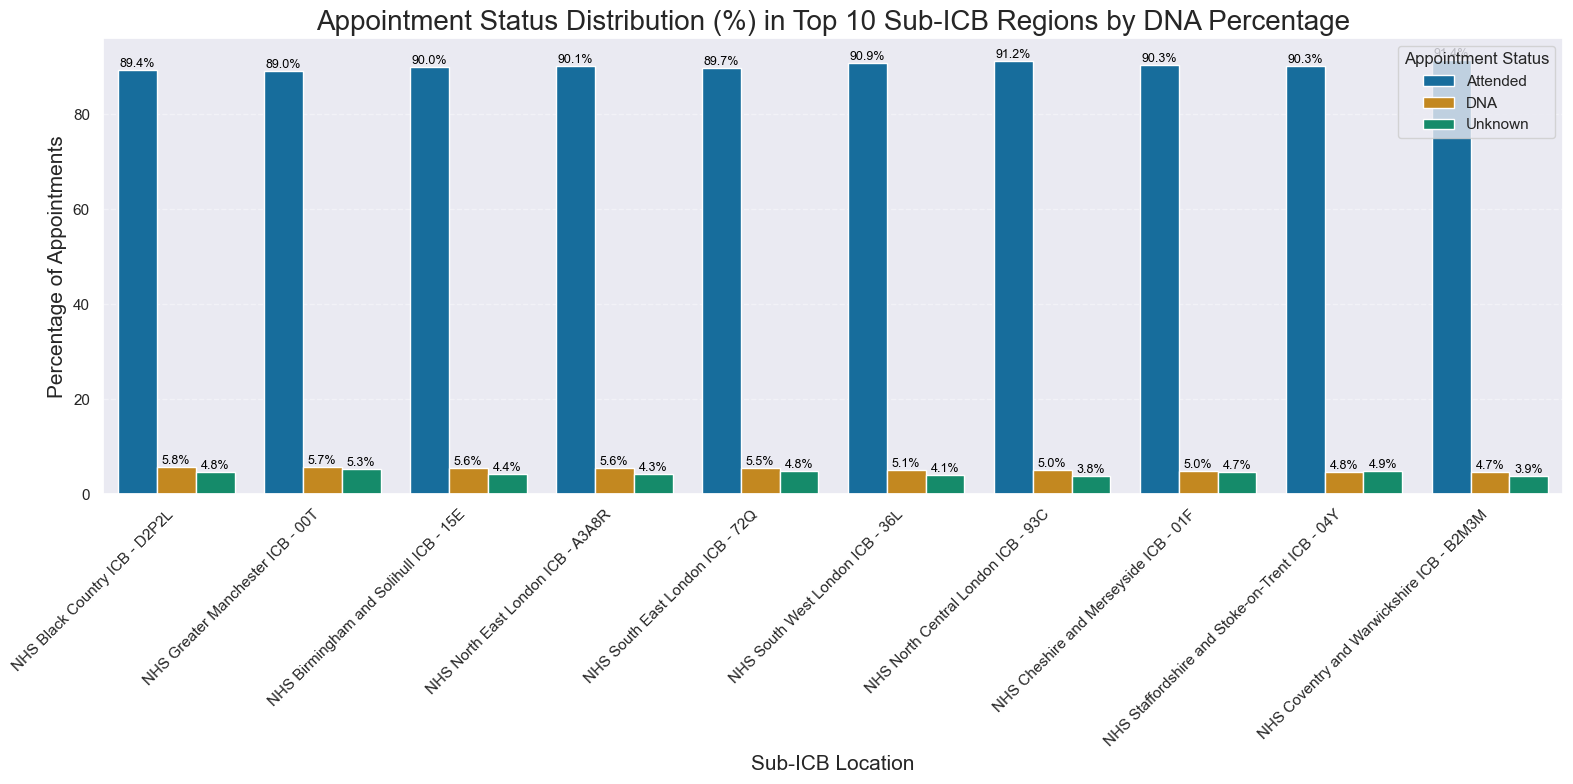

In [107]:
# Missed appointments shown by sub ICB Region

# Clean and filter relevant columns
filtered_df = merged_df.dropna(subset=['sub_icb_location_name', 'appointment_status', 'count_of_appointments_x'])
filtered_df['count_of_appointments_x'] = pd.to_numeric(filtered_df['count_of_appointments_x'], errors='coerce')
filtered_df = filtered_df.dropna(subset=['count_of_appointments_x'])

# Get total appointment counts per location
total_counts = filtered_df.groupby('sub_icb_location_name')['count_of_appointments_x'].sum().reset_index(name='total_appointments')

# Get DNA counts per location
dna_only = filtered_df[filtered_df['appointment_status'] == 'DNA']
dna_counts = dna_only.groupby('sub_icb_location_name')['count_of_appointments_x'].sum().reset_index(name='dna_appointments')

# Merge to compute DNA percentage
dna_percentage_df = pd.merge(total_counts, dna_counts, on='sub_icb_location_name', how='left')
dna_percentage_df['dna_appointments'] = dna_percentage_df['dna_appointments'].fillna(0)
dna_percentage_df['dna_percentage'] = (dna_percentage_df['dna_appointments'] / dna_percentage_df['total_appointments']) * 100

# Get top 10 locations by DNA percentage
top10_dna_percent = dna_percentage_df.sort_values(by='dna_percentage', ascending=False).head(10)
top10_order = top10_dna_percent['sub_icb_location_name'].tolist()

# Filter original data to just those top 10 locations
top10_df = filtered_df[filtered_df['sub_icb_location_name'].isin(top10_order)]

# Group by location and status, sum counts
grouped = top10_df.groupby(['sub_icb_location_name', 'appointment_status'])['count_of_appointments_x'].sum().reset_index()

# Normalize within each location to get percentage
grouped['percentage'] = grouped.groupby('sub_icb_location_name')['count_of_appointments_x'].transform(lambda x: (x / x.sum()) * 100)

#  Plot graph
plt.figure(figsize=(16, 8))
ax = sns.barplot(
    data=grouped, 
    x='sub_icb_location_name', 
    y='percentage', 
    hue='appointment_status', 
    palette='colorblind',\
    order=top10_order
)

# Add percentage labels to each bar
for bar in ax.patches:
    height = bar.get_height()
    if height > 0:
        ax.annotate(f'{height:.1f}%',
                    (bar.get_x() + bar.get_width() / 2, height),
                    ha='center', va='bottom', fontsize=9, color='black')

# Title, labels and legend box
plt.title('Appointment Status Distribution (%) in Top 10 Sub-ICB Regions by DNA Percentage', fontsize=20)
plt.xlabel('Sub-ICB Location', fontsize=15)
plt.ylabel('Percentage of Appointments', fontsize=15)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Appointment Status')
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()



#### It can be seen that some areas do indeed have higher DNAs than others. The top ten range from 4.7% - 5.8%. Additionally these Sub ICB regions also seem to have the highest amount of 'unknown' valuse, ranging from 3.9% - 4.8%. The worst for DNAsare NHS Black Country, NHS Greater Manchester and NHS Birmingham & Solihull - all three midland regions. This is unlikely to be a coincidence - densely populated areas - high numbers of appointments. However, the DNA and unknown figures are proportional so more appointments shouldn't affect the data.

## 15f Missed Appointments by Sub-ICB Region (Geographic)

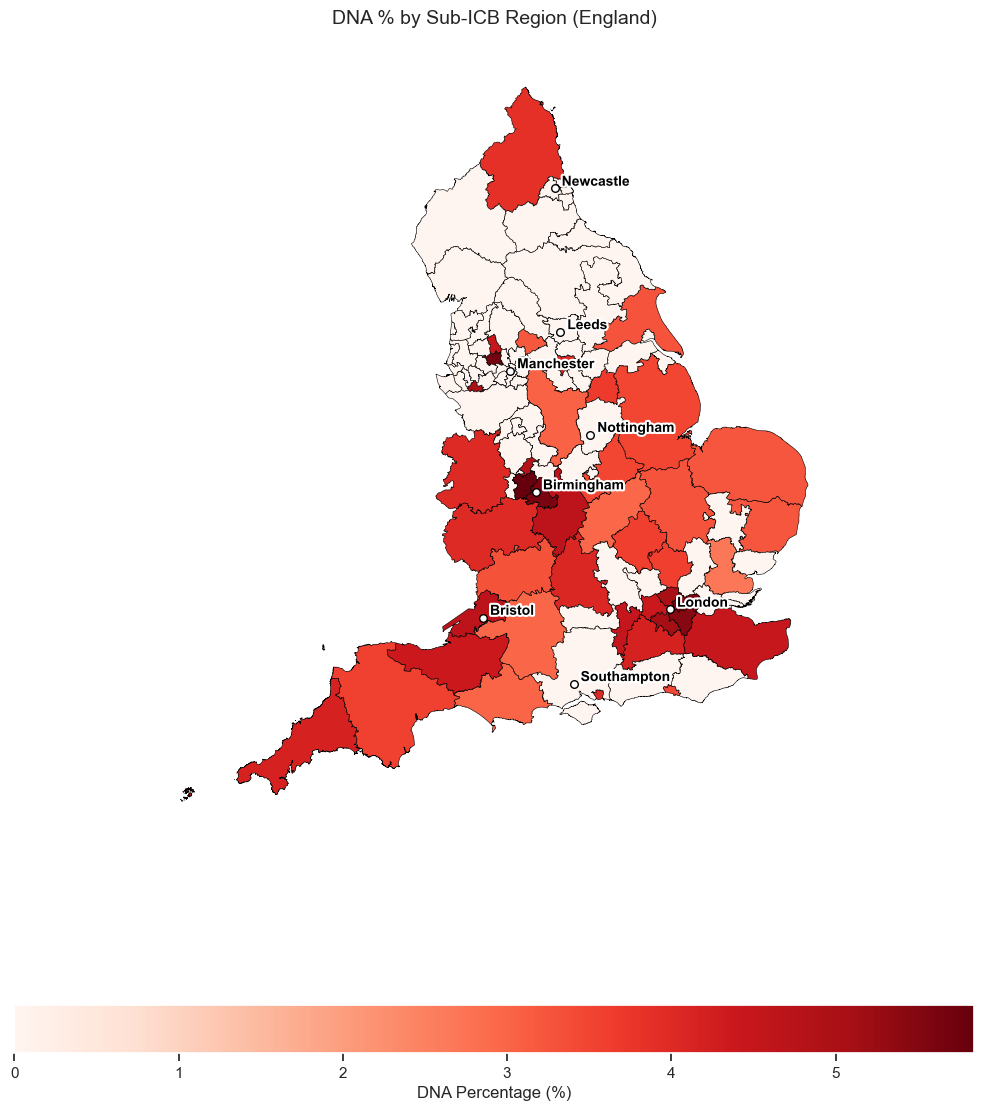

In [108]:
# Use GeoJSON to produce a georgaphic map of sub ICB regions
# This will use a geojson file download from the Office for National Statistics website

# Load in the appopriate file

# Load GeoJSON boundary file - this location is specific to this analysis
# the file downloaded is: sub_icb_boundaries_geojson.geojson
geo_path = r"c:\users\tamar\Downloads\sub_icb_boundaries_geojson.geojson"
geo_df = gpd.read_file(geo_path)[["SICBL22NM", "geometry"]].copy()

# Ensure appointment DataFrame (dna_percentage_df) exists here
required = {"sub_icb_location_name", "dna_percentage"}
missing = required - set(dna_percentage_df.columns)
if missing:
    raise ValueError(f"dna_percentage_df missing columns: {missing}")

# Define functions 
def extract_nhs_code(series: pd.Series) -> pd.Series:
    return (
        series.astype(str)
        .str.strip()
        .str.lower()
        .str.extract(r"([a-z0-9]{3})$")
    )


def clean_text_only(series: pd.Series) -> pd.Series:
    return (
        series.astype(str)
        .str.lower()
        .str.replace(
            r"\b(nhs|icb|integrated care board|sub-icb|location)\b",
            "",
            regex=True,
        )
        .str.replace(r"[^a-z0-9]", "", regex=True)
        .str.strip()
    )


# Match and merge datasets
geo_df["nhs_code"] = extract_nhs_code(geo_df["SICBL22NM"])
dna_percentage_df["nhs_code"] = extract_nhs_code(
    dna_percentage_df["sub_icb_location_name"]
)

if dna_percentage_df["nhs_code"].isna().all():
    geo_df["nhs_key"] = clean_text_only(geo_df["SICBL22NM"])
    dna_percentage_df["nhs_key"] = clean_text_only(
        dna_percentage_df["sub_icb_location_name"]
    )
    merged = geo_df.merge(
        dna_percentage_df[["nhs_key", "dna_percentage"]],
        on="nhs_key",
        how="left",
    )
else:
    merged = geo_df.merge(
        dna_percentage_df[["nhs_code", "dna_percentage"]],
        on="nhs_code",
        how="left",
    )

merged["dna_percentage"] = merged["dna_percentage"].fillna(0)

# Setup major city labels and co-ordinates for map
city_data = {
    "City": [
        "London",
        "Birmingham",
        "Manchester",
        "Leeds",
        "Newcastle",
        "Bristol",
        "Nottingham",
        "Southampton",
    ],
    "Longitude": [
        -0.1278,
        -1.8904,
        -2.2426,
        -1.5491,
        -1.6156,
        -2.5879,
        -1.1501,
        -1.4043,
    ],
    "Latitude": [
        51.5074,
        52.4862,
        53.4808,
        53.8008,
        54.9783,
        51.4545,
        52.9548,
        50.9105,
    ],
}

cities_df = pd.DataFrame(city_data)
geometry = [
    Point(xy) for xy in zip(cities_df["Longitude"], cities_df["Latitude"])
]
cities_gdf = gpd.GeoDataFrame(
    cities_df, geometry=geometry, crs="EPSG:4326"
).to_crs(merged.crs)

# Plot the Choropleth map with labels
fig, ax = plt.subplots(figsize=(10, 12))

# Plot the regional boundary layers
merged.plot(
    column="dna_percentage",
    cmap="Reds",
    legend=True,
    legend_kwds={"label": "DNA Percentage (%)", "orientation": "horizontal"},
    edgecolor="black",
    linewidth=0.4,
    missing_kwds={"color": "lightgrey"},
    ax=ax,
)

# Plot city marker dots - white with black outline for better contrast on dark map colours
cities_gdf.plot(
    ax=ax,
    color="white",
    edgecolor="black",
    linewidth=1,
    markersize=30,
    marker="o",
    zorder=5,
)

# Define the text halo styling (White background stroke)
with_halo = [
    path_effects.Stroke(linewidth=3, foreground="white"),
    path_effects.Normal(),
]

# Overlay the city text labels with halo effect
for x, y, label in zip(
    cities_gdf.geometry.x, cities_gdf.geometry.y, cities_gdf["City"]
):
    ax.annotate(
        text=label,
        xy=(x, y),
        xytext=(5, 2),  # Adjust offset positioning slightly
        textcoords="offset points",
        fontsize=10,
        weight="bold",
        color="black",
        path_effects=with_halo,  # Applies the text boundary contrast halo
        zorder=6,
    )

plt.title("DNA % by Sub-ICB Region (England)", fontsize=14, pad=20)
plt.axis("off")
plt.tight_layout()
plt.show()

#### This map shows those sub icb region with the higest level of DNAs. The darker the shade the higher the level of DNAs

#### The highest levels can be seen in the midlands and London. 

## Notes/Summary

Routine GP appointment accounts for the largest number of appointments at 97,271,522 in the nc_clean dataframe

General consultation aute was the next highest at 53,691,150

The lowest was Group consultation nand group education with 60,632 appointments

A line plot of count of appopintments by month shows that the 1.2 million capacity is regularly breached. This seems to be the case except in August and September 2021 and January 2022

The service settings were plotted against appointment month, and routine GP appointments drown out the other entries to the extent it makes them unreadable so a seperate graph was made for service settings without routine GP appointments giving a  much clearly understanding

Routine GP appointments had a dip in number at the end of 2021 until February 2022

Looking at the graphs without routine GP appointments it can be seen once again that unmapped/bad data takes the lead, although this does take a significant dip between August 2021 and December 2021, it's still higher than any other service setting except GP.

There was a slight rise in all service setting appointments between February 2022 and April 2022

The context types were plotted on a graph covering the same date period as servce settings, August 2021 to June 2022.

It can be seen that care related context makes up the bulk, but again umapped/data quality makes up a small but not insignificant count.

It can also be seen that there is a significant dip in the counts at the end of 2021 until February 2022, in line with the service setting graph, which is to be expected.

The national categories for the period August 2021 to June 2022 were plotted. This shows GP consultations make up the biggest chunk of appointments in terms of categories. There is a dip in usage of all categories from March 2022 to April 2022.

A heatmap for the period shows those days with the most appointments. Weekends have hardly any appointments, but the first half of the week (Mon-Wed) definetly has the highest number of appointments each day. This tails off towards the end of the week.
Also some Monday's are showing verylow counts of appointments. It is assumed that these are bank holidays so would be expected. Similarly Christmas period shows up in the heatmap. 
During the period of 06-09-21 until 13-12-21 there is an increase in Saturday appointments. These have only come to light through the use of the heatmap.

Total GP appointments for the period have been plotted as a barplot with Tuesday being the day with the highest number of amounts, followed by Monday. Sunday, as to be expected has the least number of appointments.

Taking that further a barplot was made to show the average number of appointments by day. AS we can see Tuesday is the highest, followed by Monday and then Wednesday. The numbers fall off in the second half of the week, with negligable numbers at weekends.

But taking this together with the earlier heatmap, is this that full story. Bank holiday Mondays will reduce the average number of appointments for Monday, and it would be reasonable to assume Monday is in fact the busiest day, not Tuesday as GP surgeries are usually closed over a weekend so patients will be waiting to get an appointment as soon as possible.

The graph suggests that the 1.2 million capacity is indeed being breached on Monday, Tuesday and Wednesday.

For the month of August 2021 it is seen that capacity wasn't breached at all.

The next linechart shows the Septemner 2021 to November 2021. Here we see the capacity begin to be breached at 7th Sptember. Summer is over and Autumn has begun and so has the increase in illnesses. With the GP numbners removed we can see the unmapped status once again coming into play. This wasn't visible on the previous chart due to scaling.

The appointment numbers are fairly stable across the period, although there is an uptick during November.

Looking at December 2021 to February 2022 it can be seen that it is a varying picture, with periods of capacity being breached while at others times under capacity, although the most significant of those covers the Christmas and New year period 2021/22 when GP surgeries would likely be closed.

March 2022 to May 2022 analysis. There is a dip in capacity usage in mid April before increasing again in May.

Turning to appointment mode (how the appointment was conducted) for the period of January 2020 until june 2022, it can be seen face to face and telephone appointments dominate. This is an interesting graph as it shows the times that England covid lockdowns started. The first being 23rd Marcgh 2020. At this point and indeed the two months leading up to restrictions, face to face appointments numbers have declined while telephone appointments have increased.

Face to face appointments began to rise, before once again dropping in numbers, although not so dramaticallt as earlier on in the year for the first lockdown. There is a spike in face to face appointments during September of 2021 before falling back down again. Telephone appointments remained relatively steady. The other modes, oncluding the unknown category remained consistent during the period.

The final graph in this section shows face to face appointments vs telephone appointments in a bit more detail. THe dramatic reducion in face to face apppointments by 2 million less, in the first part of the year is very apparent. Interestingly telephone appointments did not rise to the same extent, meaning that less appointments were actually made during this period. 


# 16. Can Social Meida Help in Understanding Sentiment around the NHS

## 16a Load the 'tweets.csv' file to analyse Twitter (X) Data

In [109]:
# Set figure size.
sns.set(rc={'figure.figsize':(12, 6)})

# Set the plot style as white.
sns.set_style('white')

# Maximum column width to display
pd.options.display.max_colwidth = 200

In [110]:
# Load the data set.
tweets = pd.read_csv('tweets.csv')

# View the DataFrame.
tweets.head()


,tweet_id,tweet_full_text,tweet_entities,tweet_entities_hashtags,tweet_metadata,tweet_retweet_count,tweet_favorite_count,tweet_favorited,tweet_retweeted,tweet_lang
0,1567629223795527681,"As Arkansas’ first Comprehensive Stroke Certified Center, UAMS provides Arkansans with access to the most advanced stoke care. Join us in our mission to make a difference in the health and well-be...","{'hashtags': [{'text': 'Healthcare', 'indices': [253, 264]}], 'symbols': [], 'user_mentions': [], 'urls': [{'url': 'https://t.co/yw0cstfmSI', 'expanded_url': 'https://bit.ly/3BiSKbs', 'display_url...",#Healthcare,"{'iso_language_code': 'en', 'result_type': 'recent'}",0,0,False,False,en
1,1567582846612553728,RT @AndreaGrammer: Work-life balance is at the foundation of how decisions are made and where #PremiseHealth is headed. We're #hiring for…,"{'hashtags': [{'text': 'PremiseHealth', 'indices': [94, 108]}, {'text': 'hiring', 'indices': [127, 134]}], 'symbols': [], 'user_mentions': [{'screen_name': 'AndreaGrammer', 'name': 'Andrea Grammer...","#PremiseHealth, #hiring","{'iso_language_code': 'en', 'result_type': 'recent'}",2,0,False,False,en
2,1567582787070304256,RT @OntarioGreens: $10 billion can go a long way to fixing our broken #Healthcare system.\n\nYet Doug Ford would rather spend it ALL on a hig…,"{'hashtags': [{'text': 'Healthcare', 'indices': [70, 81]}], 'symbols': [], 'user_mentions': [{'screen_name': 'OntarioGreens', 'name': 'Green Party of Ontario', 'id': 37115912, 'id_str': '37115912'...",#Healthcare,"{'iso_language_code': 'en', 'result_type': 'recent'}",39,0,False,False,en
3,1567582767625428992,RT @modrnhealthcr: 🚨#NEW:🚨 Insurance companies are figuring out the best ways to collect information about members’ race and ethnicity data…,"{'hashtags': [{'text': 'NEW', 'indices': [20, 24]}], 'symbols': [], 'user_mentions': [{'screen_name': 'modrnhealthcr', 'name': 'Modern Healthcare', 'id': 18935711, 'id_str': '18935711', 'indices':...",#NEW,"{'iso_language_code': 'en', 'result_type': 'recent'}",5,0,False,False,en
4,1567582720460570625,"ICYMI: Our recent blogs on Cybersecurity in Accounting https://t.co/4nnK0FiVVL and Digital Transformation in Healthcare Finance https://t.co/jIqn52lHD3 are a great read, take a look!\n\n#blogs #di...","{'hashtags': [{'text': 'blogs', 'indices': [184, 190]}, {'text': 'digitaltransformation', 'indices': [191, 213]}, {'text': 'cybersecurity', 'indices': [214, 228]}, {'text': 'accounting', 'indices'...","#blogs, #digitaltransformation, #cybersecurity, #accounting, #finance, #healthcare","{'iso_language_code': 'en', 'result_type': 'recent'}",0,0,False,False,en


In [111]:
tweets.tail()

,tweet_id,tweet_full_text,tweet_entities,tweet_entities_hashtags,tweet_metadata,tweet_retweet_count,tweet_favorite_count,tweet_favorited,tweet_retweeted,tweet_lang
1169,1567583004209332227,RT @PotomacPhotonic: Potomac #Innovation Report: #precisionFabrication techniques Optimize #Microfluidic Mixing of Viscous Fluids \n\n#manuf…,"{'hashtags': [{'text': 'Innovation', 'indices': [29, 40]}, {'text': 'precisionFabrication', 'indices': [50, 71]}, {'text': 'Microfluidic', 'indices': [92, 105]}], 'symbols': [], 'user_mentions': [...","#Innovation, #precisionFabrication, #Microfluidic","{'iso_language_code': 'en', 'result_type': 'recent'}",1,0,False,False,en
1170,1567582945342267393,"Not a cent towards workers who would like to advance their training, especially those already employed by SHA or who for various reasons cannot obtain a student loan. Half of our department applie...","{'hashtags': [{'text': 'SKPoli', 'indices': [232, 239]}, {'text': 'healthcare', 'indices': [240, 251]}], 'symbols': [], 'user_mentions': [], 'urls': [{'url': 'https://t.co/33f7Dz5FrU', 'expanded_u...","#SKPoli, #healthcare","{'iso_language_code': 'en', 'result_type': 'recent'}",0,1,False,False,en
1171,1567582936014241792,"The @hfmaorg Region 9 presents ""The Value of ESG to the Healthcare Industry"" and our own Kris Russell and Ron Present will be the key speakers. This #webinar will be taking place 9/13 and will exp...","{'hashtags': [{'text': 'webinar', 'indices': [149, 157]}, {'text': 'ESG', 'indices': [209, 213]}, {'text': 'healthcare', 'indices': [235, 246]}], 'symbols': [], 'user_mentions': [{'screen_name': '...","#webinar, #ESG, #healthcare","{'iso_language_code': 'en', 'result_type': 'recent'}",0,0,False,False,en
1172,1567582892892782592,Happy physiotherapy 🩺 day 🎉..\n#bpt #physiotherapy \n#HealthyNation #healthcare \n#medicalcare \n#csjmu .\n@WHO \n@MoHFW_INDIA \n@nitish_0210 https://t.co/NQHdIoYymC,"{'hashtags': [{'text': 'bpt', 'indices': [30, 34]}, {'text': 'physiotherapy', 'indices': [35, 49]}, {'text': 'HealthyNation', 'indices': [51, 65]}, {'text': 'healthcare', 'indices': [66, 77]}, {'t...","#bpt, #physiotherapy, #HealthyNation, #healthcare, #medicalcare, #csjmu","{'iso_language_code': 'en', 'result_type': 'recent'}",0,5,False,False,en
1173,1567582846847533058,RT @KimcoStaffing: Apply now to work for #MediQuestStaffing as EVS - #Hospital - 1st #shift - Interviewing Now!! (#NewportBeach) #job http…,"{'hashtags': [{'text': 'MediQuestStaffing', 'indices': [41, 59]}, {'text': 'Hospital', 'indices': [69, 78]}, {'text': 'shift', 'indices': [85, 91]}, {'text': 'NewportBeach', 'indices': [115, 128]}...","#MediQuestStaffing, #Hospital, #shift, #NewportBeach, #job","{'iso_language_code': 'en', 'result_type': 'recent'}",2,0,False,False,en


In [112]:
# Explore the metadata.
tweets.shape
print(tweets.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1174 entries, 0 to 1173
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   tweet_id                 1174 non-null   int64 
 1   tweet_full_text          1174 non-null   object
 2   tweet_entities           1174 non-null   object
 3   tweet_entities_hashtags  1007 non-null   object
 4   tweet_metadata           1174 non-null   object
 5   tweet_retweet_count      1174 non-null   int64 
 6   tweet_favorite_count     1174 non-null   int64 
 7   tweet_favorited          1174 non-null   bool  
 8   tweet_retweeted          1174 non-null   bool  
 9   tweet_lang               1174 non-null   object
dtypes: bool(2), int64(3), object(5)
memory usage: 75.8+ KB
None


#### This shows the columns in the tweets.csv dataset. This includes hashtags, number of times a tweet has been retweeted (if at all), and count of how many times it's been favourited (liked). Can this data help with determining the sentiment with the NHS?

In [113]:
# Looking at the shape of the tweets dataset
tweets.shape

(1174, 10)

#### There are 1174 records in the tweets.csv file

In [114]:
# Explore the data set.
print(tweets.describe())
print(tweets.columns)

           tweet_id  tweet_retweet_count  tweet_favorite_count
count  1.174000e+03          1174.000000            1174.00000
mean   1.567612e+18             8.629472               0.37138
std    2.427553e+13            29.784675               2.04470
min    1.567574e+18             0.000000               0.00000
25%    1.567590e+18             0.000000               0.00000
50%    1.567611e+18             1.000000               0.00000
75%    1.567633e+18             3.000000               0.00000
max    1.567655e+18           303.000000              42.00000
Index(['tweet_id', 'tweet_full_text', 'tweet_entities',
       'tweet_entities_hashtags', 'tweet_metadata', 'tweet_retweet_count',
       'tweet_favorite_count', 'tweet_favorited', 'tweet_retweeted',
       'tweet_lang'],
      dtype='object')


## 16b Do Retweets and Favourite tweets inparticular provide insights

#### It would be useful to only look at retweeted and favourite tweet messages as this will give an indicatiobn of how people like and agree with what is being said. Tweets on their own don't really give much to go on, but the higher the tweet is liked or even retweeted gives an indication of people agree wit and hence sentiment.

In [115]:
# Creating a new DataFrame containing only the text column from the dataset

tweet_text = tweets['tweet_full_text']

# View the DataFrame.
tweet_text.head()

0    As Arkansas’ first Comprehensive Stroke Certified Center, UAMS provides Arkansans with access to the most advanced stoke care. Join us in our mission to make a difference in the health and well-be...
1                                                                RT @AndreaGrammer: Work-life balance is at the foundation of how decisions are made and where #PremiseHealth is headed.  We're #hiring for…
2                                                             RT @OntarioGreens: $10 billion can go a long way to fixing our broken #Healthcare system.\n\nYet Doug Ford would rather spend it ALL on a hig…
3                                                               RT @modrnhealthcr: 🚨#NEW:🚨 Insurance companies are figuring out the best ways to collect information about members’ race and ethnicity data…
4    ICYMI: Our recent blogs on Cybersecurity in Accounting https://t.co/4nnK0FiVVL and Digital Transformation in Healthcare Finance https://t.co/jIqn52lHD3 are a great read, take 

## 16c How often are tweets retweeted?

In [116]:
# Counting how many times tweets are retweeted
tweets['tweet_retweet_count'].value_counts().head()

0    526
1    215
2    114
3     70
5     35
Name: tweet_retweet_count, dtype: int64

#### Most tweets are NOT retweeted, and when they are it tends to be only 1 or 2 times. A small number are retweeted more times. This is specific to this dataset. 

## 16d How often are tweets liked?

In [117]:
# calculating the number of likes a tweet receives
tweets['tweet_favorite_count'].value_counts().head()

0    1027
1      91
2      16
3      13
4       7
Name: tweet_favorite_count, dtype: int64

#### Most tweets don't receive any likes and when they do it tend to be just the one

## 16e The top trending Hashtags in the Dataset

In [118]:
# Creating a variable 'tags' and assigning an empty list to it
tags = []

In [119]:
# Loop through the messages, and create a list of values containing the # symbol.
for y in [x.split(' ') for x in tweets['tweet_full_text'].values]:
    for z in y:
        if '#' in z:
            # Change to lowercase
            tags.append(z.lower())

#### Creating a Pandas series of all the unique hashtags

In [120]:
# Covert tags to a series
tags_series = pd.Series(tags)

# Display the first 30 records.
print(tags_series.head(30))

0                                    #healthcare
1                                 #premisehealth
2                                        #hiring
3                                    #healthcare
4                                        🚨#new:🚨
5                                look!\n\n#blogs
6                         #digitaltransformation
7                                 #cybersecurity
8                                    #accounting
9                                       #finance
10                                   #healthcare
11    https://t.co/jrgqeqdme4\n.\n#firstcoastcna
12                                      #cnaexam
13                           #cnaexampreparation
14                                 #jacksonville
15                                  #cnatraining
16                                        #nurse
17                                      #nursing
18                                    #nurselife
19                            #nursepractitioner
20                  

#### Now count how many times each hashtag appears in the data and display the counts in numerical order

In [121]:
# Count how many times the unique hashtag appears
tag_counts = tags_series.value_counts()

# Convert the series to a DataFrame in preparation for visualisation.
tags_df = tags_series.to_frame()
data = tag_counts.reset_index()

# Change the column names
data.columns = ['hashtag', 'count']

# View the new datframe
data


,hashtag,count
0,#healthcare,716
1,#health,80
2,#medicine,41
3,#ai,40
4,#job,38
...,...,...
1749,#evestudy,1
1750,#patientdata…,1
1751,#secure,1
1752,#sms,1


In [122]:
# Fix the count datatype - standarisation
# Checking the current 'count' datatype
data.info()

# Setting the datatype for 'count' to int
data['count'] = data['count'].astype(int)

# View the result.
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1754 entries, 0 to 1753
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   hashtag  1754 non-null   object
 1   count    1754 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 27.5+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1754 entries, 0 to 1753
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   hashtag  1754 non-null   object
 1   count    1754 non-null   int32 
dtypes: int32(1), object(1)
memory usage: 20.7+ KB


In [123]:
# Display records where the count is larger than 10.
count_greater_10 = data[data['count'] > 10]
count_greater_10

,hashtag,count
0,#healthcare,716
1,#health,80
2,#medicine,41
3,#ai,40
4,#job,38
5,#medical,35
6,#strategy,30
7,#pharmaceutical,28
8,#digitalhealth,25
9,#pharma,25


#### The hashtag #Healthcare is the most prominent by a large margin (nearly 10x the next hashtag). As a hashtag it really doesn't give much away.

In [124]:
# Create a Seaborn barplot indicating records with a count >10 

count_greater_10 = count_greater_10.sort_values(by='count', ascending=False)

# Filtering out to only have the top 10 hashtags
top10_filtered = count_greater_10.head(10)

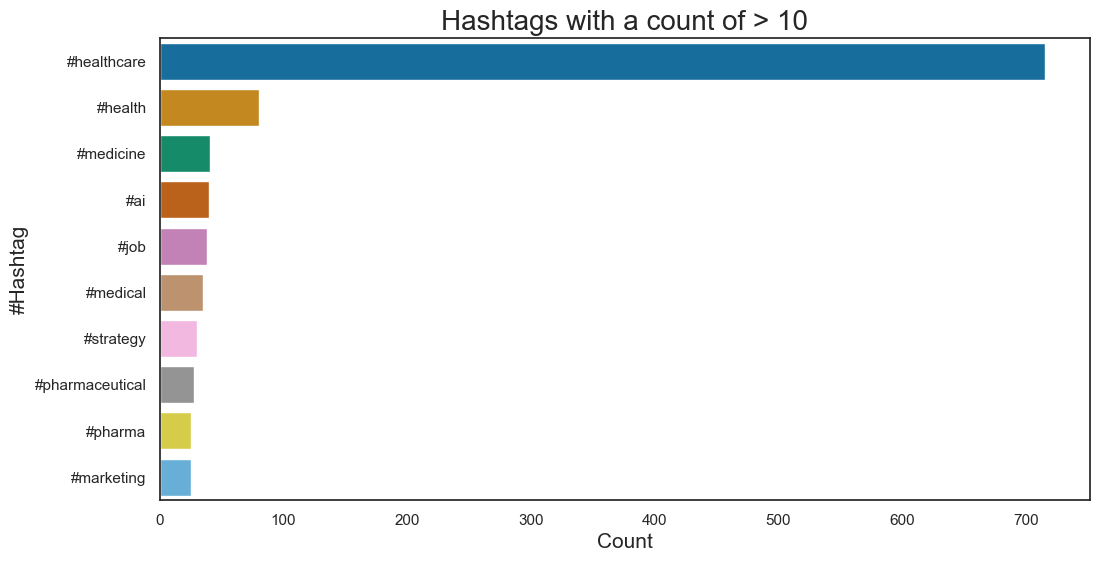

In [125]:
# Create the plot of hashtags >10 in descending order

sns.barplot(
    x='count', 
    y='hashtag', 
    data = top10_filtered,     
    palette='colorblind'
)

# Set title, axis labels
plt.title('Hashtags with a count of > 10', fontsize=20)
plt.xlabel('Count', fontsize=15)
plt.ylabel('#Hashtag', fontsize=15)
plt.tight_layout

# Save graph
plt.savefig("tweets.png")


#### The above bar plot shows the top ten hashtags in the data. #Healthcare dominates.

### Summary/Notes

The original tweets.xlsx file was converted to a .csv file for uniformity across the datasets and to reduce the liklihood of issues.

The head() and tail() functions show there is no hidden metadata in the final row.

Shape shows a datframe with 1174 rows across 10 columns. The column names are as follows:
tweet_id', 'tweet_full_text', 'tweet_entities',
       'tweet_entities_hashtags', 'tweet_metadata', 'tweet_retweet_count',
       'tweet_favorite_count', 'tweet_favorited', 'tweet_retweeted',
       'tweet_lang'

It would be useful to only look at retweeted and favourite tweet messages and this will give an indicatiobn of how people like and agree with what is being said. Tweets on their own don't really give much to go on, but the higher the tweet is liked or even retweeted gives an indication of people agree with.

Looking at the retweet count rate it can be seen that most tweets aren't retweeted and if they are it's only once or twice. Likewise tweets aren't often liked, so while these can provide an indication of agreement the fact that likes and retweets don't happen that much doesn't help with the data quality.

It was found that #heathcare was by far the most popular hashtag in the dataset by nearly 10x to the next most popular of #health. A barplot for the ten most popular hashtags was generated and #heathcare dominated the chart.

Overall the tweets have very limited, if any, real use in this specific analysis


# 17. Capacity & Utilisation

## 17a Filtering the dataset

#### Reviewing the 'appointments_regional.csv' file 

In [126]:
# Load the appointments_regional.csv file.
ar = pd.read_csv('appointments_regional.csv')

# View the DataFrame.
ar.head()

,icb_ons_code,appointment_month,appointment_status,hcp_type,appointment_mode,time_between_book_and_appointment,count_of_appointments
0,E54000034,2020-01,Attended,GP,Face-to-Face,1 Day,8107
1,E54000034,2020-01,Attended,GP,Face-to-Face,15 to 21 Days,6791
2,E54000034,2020-01,Attended,GP,Face-to-Face,2 to 7 Days,20686
3,E54000034,2020-01,Attended,GP,Face-to-Face,22 to 28 Days,4268
4,E54000034,2020-01,Attended,GP,Face-to-Face,8 to 14 Days,11971


In [127]:
# Print the min and max dates.
ar['appointment_month'] = pd.to_datetime(ar['appointment_month'])

# Print min and max as date only
print("Minimum date:", ar['appointment_month'].min().date())
print("Maximum date:", ar['appointment_month'].max().date())


Minimum date: 2020-01-01
Maximum date: 2022-06-01


#### The dataset includes records from 01/01/2020 - 01/06/2022. For the purpose of this part of the analysis looking at capacity and utilisation, the data will be filtered to only inlcude only records between 01/08/2021 - 01/06/2022

In [128]:
# Filter the data set to only look at data from 2021-08 onwards.
data_from_2021_08 = ar[ar['appointment_month'] >= '2021-08-01']

# View the datframe
data_from_2021_08

,icb_ons_code,appointment_month,appointment_status,hcp_type,appointment_mode,time_between_book_and_appointment,count_of_appointments
3652,E54000034,2021-08-01,Attended,GP,Face-to-Face,1 Day,6553
3653,E54000034,2021-08-01,Attended,GP,Face-to-Face,15 to 21 Days,2390
3654,E54000034,2021-08-01,Attended,GP,Face-to-Face,2 to 7 Days,10547
3655,E54000034,2021-08-01,Attended,GP,Face-to-Face,22 to 28 Days,937
3656,E54000034,2021-08-01,Attended,GP,Face-to-Face,8 to 14 Days,4961
...,...,...,...,...,...,...,...
596816,E54000050,2022-06-01,Unknown,Unknown,Unknown,2 to 7 Days,21
596817,E54000050,2022-06-01,Unknown,Unknown,Unknown,22 to 28 Days,8
596818,E54000050,2022-06-01,Unknown,Unknown,Unknown,8 to 14 Days,28
596819,E54000050,2022-06-01,Unknown,Unknown,Unknown,More than 28 Days,17


## 17b Capacity & Utilisation Analysis - Appointments by month

#### Grouping the data by month and then calculating the total number of appointments for each month for the analysis period. The daily capacity of 1.2 million appointments a day and a 30 day month are assumed. Taking 30 days in a month also includes weekends which are well under the capacity figure. This could skew the data.

In [129]:
# Determining the number of total appointment for each month during the period

# Making sure/setting the date column to datetime 
data_from_2021_08["appointment_month"] = pd.to_datetime(
    data_from_2021_08["appointment_month"]
)

# Group by month and calculate total appointments
ar_am = (
    data_from_2021_08.groupby("appointment_month", as_index=False)[
        "count_of_appointments"
    ]
    .sum()
)

# Define the maximum daily capacity
max_daily_capacity = 1200000  # Maximum appointment capacity is said to be 1.2 Million per day

# Calculate exact working weekdays (Mon-Fri) for each specific month - ignore weekends
ar_am["working_days"] = ar_am["appointment_month"].apply(
    lambda x: np.busday_count(
        x.strftime("%Y-%m"), (x + pd.DateOffset(months=1)).strftime("%Y-%m")
    )
)

# Calculate true weekday utilisation as a percentage
ar_am["utilisation"] = (
    ar_am["count_of_appointments"] / (ar_am["working_days"] * max_daily_capacity)
) * 100
ar_am["utilisation"] = ar_am["utilisation"].round(1)

# Sort by utilisation descending and reset index
ar_am = ar_am.sort_values(by="utilisation", ascending=False).reset_index(
    drop=True
)


# Calculate appointments in millions 
ar_am['Appointments (Millions)'] = ar_am['count_of_appointments'] / 1000000

ar_am.index = ar_am.index + 1  # Start ranking from 1

# View the final DataFrame table
ar_am

,appointment_month,count_of_appointments,working_days,utilisation,Appointments (Millions)
1,2021-10-01,30303834,21,120.3,30.303834
2,2021-11-01,30405070,22,115.2,30.405070
3,2021-09-01,28522501,22,108.0,28.522501
4,2022-03-01,29595038,23,107.2,29.595038
5,2022-02-01,25355260,20,105.6,25.355260
6,2022-05-01,27495508,22,104.1,27.495508
7,2022-01-01,25635474,21,101.7,25.635474
8,2022-06-01,25828078,22,97.8,25.828078
9,2022-04-01,23913060,21,94.9,23.913060
10,2021-12-01,25140776,23,91.1,25.140776


#### Reorder the table into date order for ease of use

In [130]:
# Reordering the same table but in date order - earlist to newest date

# Using ar_am set date time
ar_am['appointment_month'] = pd.to_datetime(ar_am['appointment_month'])

# Sort the DataFrame by month
ar_am = ar_am.sort_values('appointment_month').reset_index(drop=True)

# Convert to string for plotting after sorting
ar_am['appointment_month'] = ar_am['appointment_month'].dt.strftime('%Y-%m')

# Calculate appointments in millions 
ar_am['Appointments (Millions)'] = ar_am['count_of_appointments'] / 1000000

ar_am.index = ar_am.index + 1  # Start ranking from 1

ar_am

# Display the table
ar_am[['appointment_month', 'Appointments (Millions)', 'utilisation']].round(1)


,appointment_month,Appointments (Millions),utilisation
1,2021-08,23.9,90.3
2,2021-09,28.5,108.0
3,2021-10,30.3,120.3
4,2021-11,30.4,115.2
5,2021-12,25.1,91.1
6,2022-01,25.6,101.7
7,2022-02,25.4,105.6
8,2022-03,29.6,107.2
9,2022-04,23.9,94.9
10,2022-05,27.5,104.1


#### The tables shows (in date order), the total number of appointments per month and how much of the available capacity (previously calculated) is used as a percentage. 
#### A line plot of the number of appointments per month is now drawn.

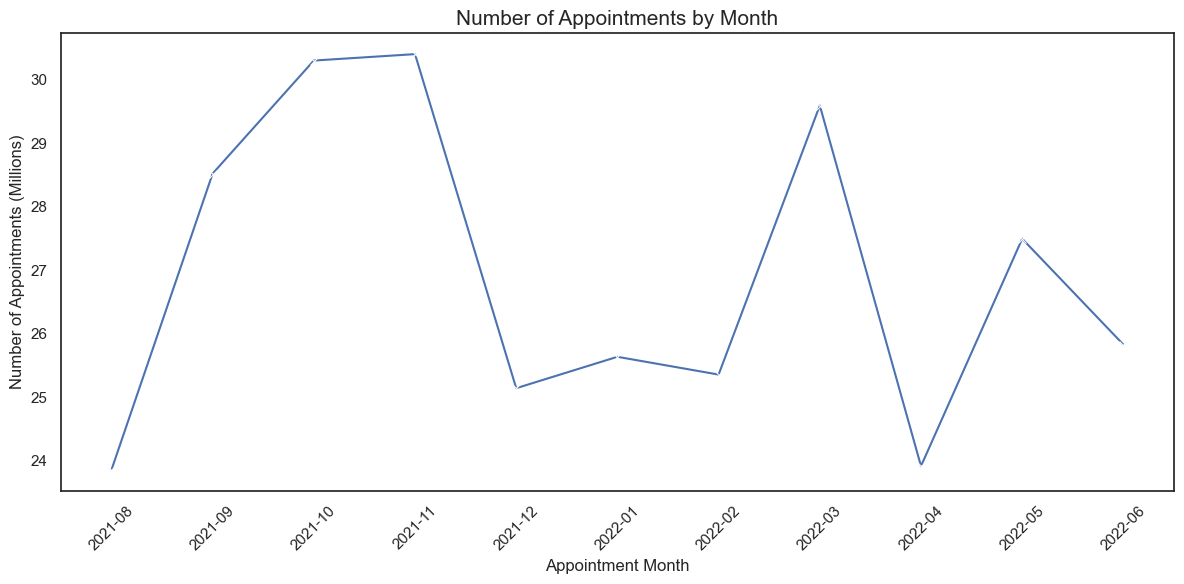

In [131]:
# Plot the monthly appointments by month

# Convert appointment_month to string for better x-axis formatting
ar_am['appointment_month'] = ar_am['appointment_month'].astype(str)

# Scale appointments for visual clarity (millions)
ar_am['Appointments (Millions)'] = ar_am['count_of_appointments'] / 1000000

# Create a lineplot with Seaborn
plt.figure(figsize=(12, 6))
sns.lineplot(
    data=ar_am, 
    x='appointment_month', 
    y='Appointments (Millions)', 
    marker='x'
)

# Set title, axis labels and sticks - set at 45 degrees
plt.title('Number of Appointments by Month', fontsize=15)
plt.xlabel('Appointment Month', fontsize=12)
plt.ylabel('Number of Appointments (Millions)', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()

# Save graph
plt.savefig("appoint_month.png")

In [132]:
# Calculate the average number of appointments per month across the period
avg_appointments = ar_am["count_of_appointments"].mean()

# Print the results cleanly
print(f"Average appointments per month: {avg_appointments:,.0f}")
print(f"Average appointments per month (Millions): {avg_appointments / 1000000:.2f}M")


Average appointments per month: 26,913,343
Average appointments per month (Millions): 26.91M


#### 17c Capacity & Utilisation Analysis - Utilisation by Month

#### The same graph but now plotted against utilisation.

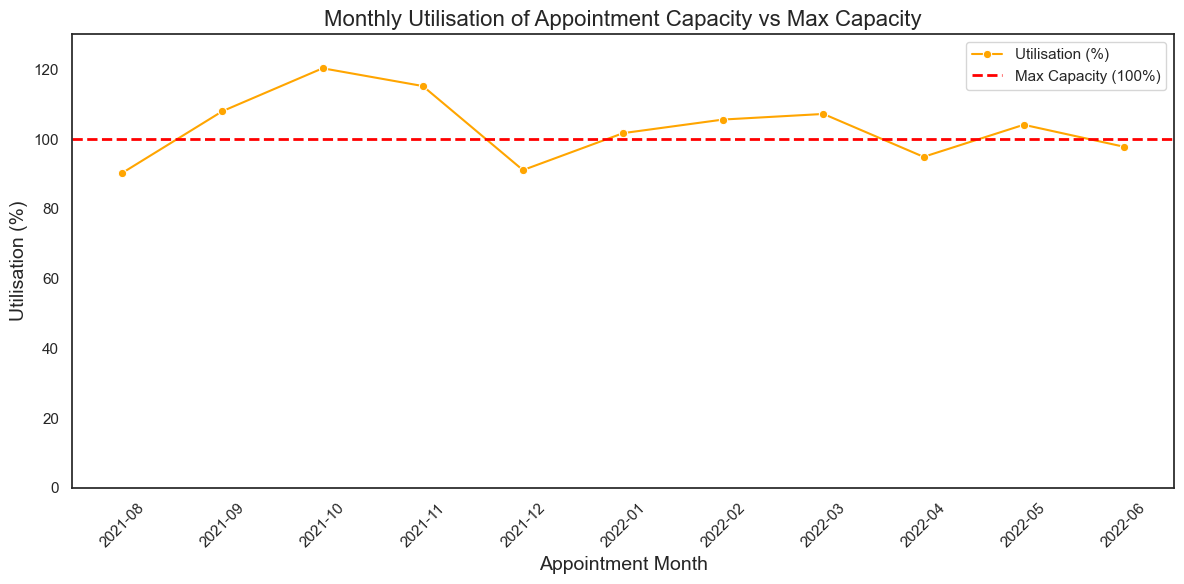

In [133]:
# Plot monthly utilisation

# Ensure appointment_month is datetime and sort
ar_am['appointment_month'] = pd.to_datetime(ar_am['appointment_month'])
ar_am = ar_am.sort_values('appointment_month').reset_index(drop=True)

# Format month for the x-axis
ar_am['appointment_month_str'] = ar_am['appointment_month'].dt.strftime('%Y-%m')

# Plot
plt.figure(figsize=(12, 6))
sns.lineplot(
    data=ar_am, 
    x='appointment_month_str', 
    y='utilisation', 
    marker='o', 
    color='orange', 
    label='Utilisation (%)'
)

# Add horizontal line for 100% capacity
plt.axhline(
    y=100, 
    color='red', 
    linestyle='--', 
    linewidth=2, 
    label='Max Capacity (100%)'
)

# Set title, laxisabels, sticks and legend box
plt.title('Monthly Utilisation of Appointment Capacity vs Max Capacity', fontsize=16)
plt.xlabel('Appointment Month', fontsize=14)
plt.ylabel('Utilisation (%)', fontsize=14)
plt.xticks(rotation=45)
plt.ylim(0, 130)
plt.legend()
plt.tight_layout()

# Save graph
plt.savefig("utilisation.png")

### Analysis of the results:
#### The Top 3 Crisis Months:
#### October 2021 (120.3%): This was the worst month - With 21 working days, the maximum weekday capacity was 25.2 million appointments, but staff squeezed in 30.3 million, running at 20.3% over structural capacity.
#### November 2021 (115.2%): Staff delivered 30.4 million appointments across 22 working days, remaining significantly over capacity.
#### September 2021 (108.0%): Demand surged immediately following the summer period, pushing the system past its limit.
#### The Over-Capacity Months: Along with the top 3 months, March 2022 (107.2%), February 2022 (105.6%), and January 2022 (101.7%) all exceeded the 100% maximum capacity ceiling.

#### Turning to days rather than months now - Taking a more granualar look at the data. For this  part of the analysis the timeline period will be extended to 01/2020 - 06/2022

#### 17d Capacity & Utilisation Analysis - Days where capacity is breached

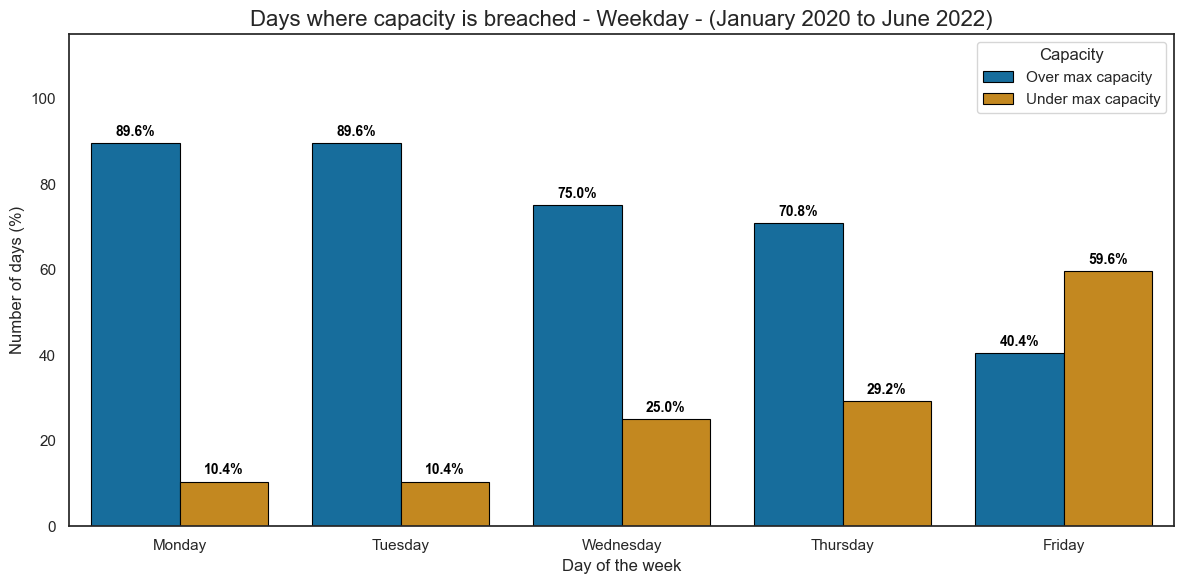

In [134]:
# Barchart of weekdays showing how frequently capacity was breached

# Timeline filtering and removal of weekend days - these are irrelevant and skew the data
# Ensure column type is mapped to a standard datetime structure
nc_clean["appointment_date"] = pd.to_datetime(nc_clean["appointment_date"])

# Filter to track  Jan 2020 - June 2022 timeline
timeline_mask = (nc_clean["appointment_date"] >= "2020-01-01") & (
    nc_clean["appointment_date"] <= "2022-06-30"
)
nc_filtered = nc_clean[timeline_mask].copy()

# Exclude weekends to prevent baseline dilution distortion - if not done this skews the data and won't give true weekday utilisation levels
nc_ex_weekends = nc_filtered[
    ~nc_filtered["day_of_week"].isin(["Saturday", "Sunday"])
].copy()

# Aggregate daily ceilings & evaluate capacity
# Group by physical date and weekday to sum overall totals per day
group_nc_ex_weekends = (
    nc_ex_weekends.groupby(["appointment_date", "day_of_week"])[
        "count_of_appointments"
    ]
    .sum()
    .reset_index()
)

# Apply 1.2M daily appointments capacity classification condition logic
group_nc_ex_weekends["Capacity"] = group_nc_ex_weekends[
    "count_of_appointments"
].apply(
    lambda x: "Over max capacity"
    if x >= 1200000  # 1.2 million daily appointments capacity
    else "Under max capacity"
)

# Calculate exact relationships & Percentages
# Count occurrence frequencies grouped systematically by day name
nc_ex_weekends_capacity_count = (
    group_nc_ex_weekends.groupby(["day_of_week", "Capacity"])
    .size()
    .reset_index(name="number_of_days")
)

# Calculate relative proportions using your transform approach
total_days_per_weekday = nc_ex_weekends_capacity_count.groupby("day_of_week")[
    "number_of_days"
].transform("sum")
nc_ex_weekends_capacity_count["percentage"] = (
    nc_ex_weekends_capacity_count["number_of_days"] / total_days_per_weekday
) * 100

# Explicit chronological formatting list for plotting order
day_order_weekdays = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday"]

# PLot the bar chart
plt.figure(figsize=(12, 6))

# Generate the side-by-side grouped bar plot (over-capacity and under-capacity bars)
ax = sns.barplot(
    data=nc_ex_weekends_capacity_count,
    x="day_of_week",
    y="percentage",
    hue="Capacity",
    order=day_order_weekdays,
    palette="colorblind",
    edgecolor="black",
    linewidth=0.8,
)

# Overlay numeric text value labels directly above the columns
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f%%",
        padding=3,
        weight="bold",
        fontsize=10,
        color="black",
    )

# Set title, axis labels and legend
plt.title(
    "Days where capacity is breached - Weekday - (January 2020 to June 2022)", fontsize=16
)
plt.xlabel("Day of the week", fontsize=12)
plt.ylabel("Number of days (%)", fontsize=12)
plt.legend(title="Capacity", loc="upper right")
plt.ylim(0, 115)  # Provide margin headroom for labels
plt.tight_layout()

# Save final graphic layout asset
plt.savefig("max_capacity_breach_bar_expanded.png")
plt.show()

#### The graph shows that worst days for breaching capacity are Monday and Tuesday - this confirms earlier findings - as these tend to be the busiest days.THis occurs 90% of weeks. Wednesday fairs slightly better, with Thursday producing similar results. Friday is the only day where the majority of the time it is under capacity. Can some resources be moved from Friday to Monday and Tuesday?

#### 17e Capacity & Utilisation Analysis - Appointments, Capacity & Utilisation

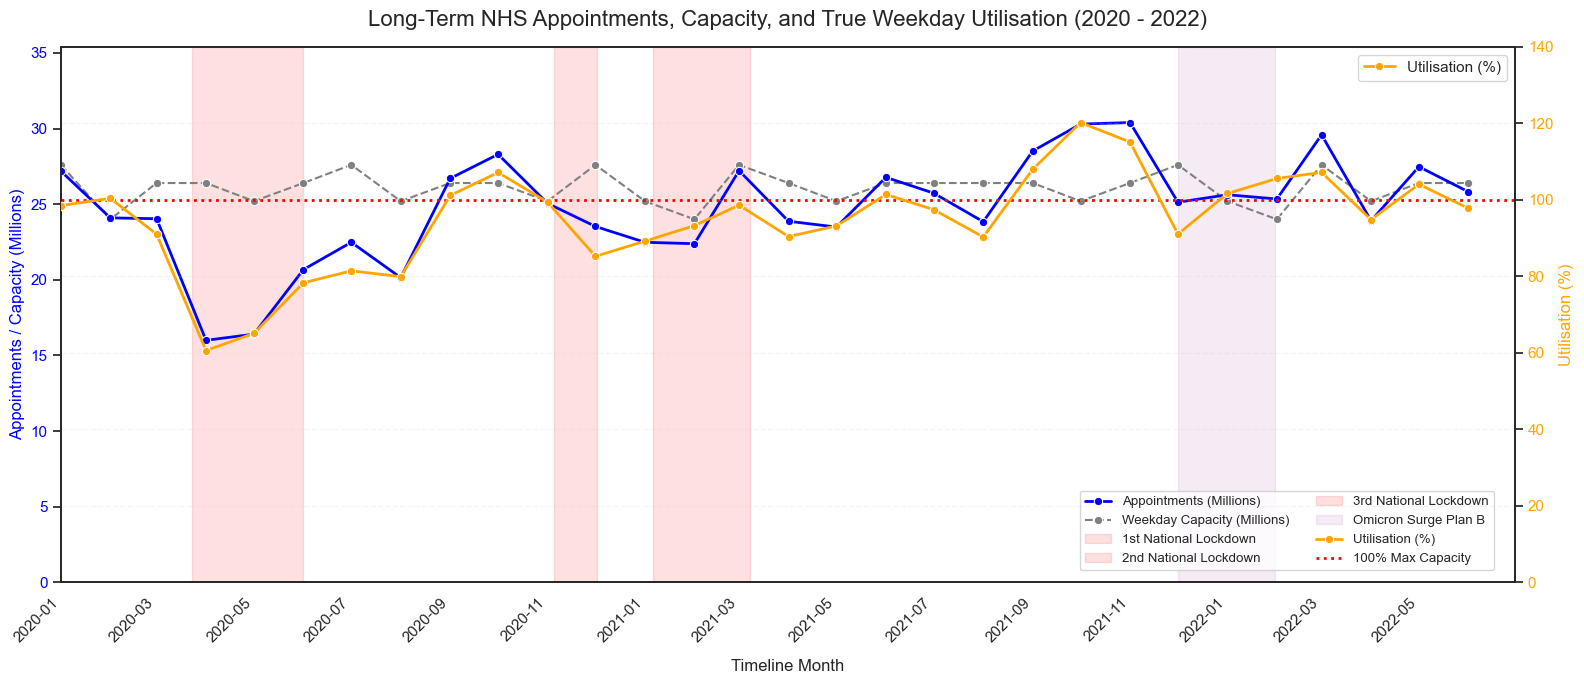

In [135]:
# Appointments and Utilisation study

# Data Processing - using ar_clean dataset
# Clean the datetime tracking column first
ar_clean["appointment_month"] = pd.to_datetime(ar_clean["appointment_month"])

# Group by month and calculate the sum total of all appointments
ar_am = (
    ar_clean.groupby("appointment_month", as_index=False)[
        "count_of_appointments"
    ]
    .sum()
)

# Enforce clean chronological sorting order
ar_am = ar_am.sort_values("appointment_month").reset_index(drop=True)

# Define daily capacity as 1.2 million appointments per day
daily_capacity = 1200000

# Dynamically count business weekdays (Mon-Fri) for every month in the dataset
ar_am["working_days"] = ar_am["appointment_month"].apply(
    lambda x: np.busday_count(
        x.strftime("%Y-%m"), (x + pd.DateOffset(months=1)).strftime("%Y-%m")
    )
)

# Calculate true capacity limits and utilisation percentages across the full timeline
ar_am["monthly_capacity"] = daily_capacity * ar_am["working_days"]
ar_am["utilisation"] = (
    ar_am["count_of_appointments"] / ar_am["monthly_capacity"]
) * 100

# Scale integers to Millions for clean charting boundaries
ar_am["appointments_millions"] = ar_am["count_of_appointments"] / 1000000
ar_am["capacity_millions"] = ar_am["monthly_capacity"] / 1000000

# Setup plot
fig, ax1 = plt.subplots(figsize=(16, 7))

# Primary Y-Axis: Volumes (Millions)
sns.lineplot(
    data=ar_am,
    x="appointment_month",
    y="appointments_millions",
    label="Appointments (Millions)",
    marker="o",
    color="blue",
    linewidth=2,
    ax=ax1,
    zorder=3,
)
sns.lineplot(
    data=ar_am,
    x="appointment_month",
    y="capacity_millions",
    label="Weekday Capacity (Millions)",
    marker="o",
    color="gray",
    linestyle="--",
    ax=ax1,
    zorder=2,
)

# Secondary Y-Axis: Utilisation Percentage
ax2 = ax1.twinx()
sns.lineplot(
    data=ar_am,
    x="appointment_month",
    y="utilisation",
    label="Utilisation (%)",
    marker="o",
    color="orange",
    linewidth=2,
    ax=ax2,
    zorder=4,
)

# 100% Benchmark marker line on secondary axis
ax2.axhline(
    y=100, color="red", linestyle=":", linewidth=2, label="100% Max Capacity"
)

# Define lockdown dates for shsding
lockdowns = [
    ("2020-03-23", "2020-06-01", "1st National Lockdown"),
    ("2020-11-05", "2020-12-02", "2nd National Lockdown"),
    ("2021-01-06", "2021-03-08", "3rd National Lockdown"),
]

for start, end, label in lockdowns:
    ax1.axvspan(
        pd.to_datetime(start),
        pd.to_datetime(end),
        color="red",
        alpha=0.12,
        label=label,
    )

# Plan B/Omicron variant winter spike context band
ax1.axvspan(
    pd.to_datetime("2021-12-01"),
    pd.to_datetime("2022-01-31"),
    color="purple",
    alpha=0.08,
    label="Omicron Surge Plan B",
)

# Axis geometry & spacing
# Lock visual canvas strict timeline boundaries
ax1.set_xlim(pd.to_datetime("2020-01-01"), pd.to_datetime("2022-06-30"))

# Dynamic date ticks layout adjustments (Show marker every 2 months for spacing)
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
ax1.xaxis.set_major_locator(mdates.MonthLocator(interval=2))

# Text layout properties
ax1.set_xlabel("Timeline Month", fontsize=12, labelpad=10)
ax1.set_ylabel("Appointments / Capacity (Millions)", fontsize=12, color="blue")
ax2.set_ylabel("Utilisation (%)", fontsize=12, color="orange")

# Match data labels perfectly to their matching line channels
ax1.tick_params(axis="y", labelcolor="blue")
ax2.tick_params(axis="y", labelcolor="orange")
plt.setp(ax1.get_xticklabels(), rotation=45, ha="right")

# Dynamic axis ceiling sizing to prevent lines clipping near borders
ax1.set_ylim(0, ar_am["appointments_millions"].max() + 5)
ax2.set_ylim(0, 140)

plt.title(
    "Long-Term NHS Appointments, Capacity, and True Weekday Utilisation (2020 - 2022)",
    fontsize=16,
    pad=15,
)

# Merge legends seamlessly into a single clean directory index box
h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()

ax1.legend(
    h1 + h2,
    l1 + l2,
    loc="lower right",
    bbox_to_anchor=(0.99, 0.01),
    ncol=2,  # Arranges items into 2 neat rows/columns to save vertical space
    fontsize=9.5,
)

plt.grid(True, linestyle="--", alpha=0.2)
plt.tight_layout()

# Save output asset
plt.savefig("longterm_utilisation_timeline.png")
plt.show()

#### This line graph shows appointments against utilisation plotted on daily weekday capacity for the time period. This is mapped against the background of covid lockdowns

#### The utilisation and appointment lines on the graph are close together making it lose clarity. So the graph is split into two - one for appointments, one forutilisation, for clarity

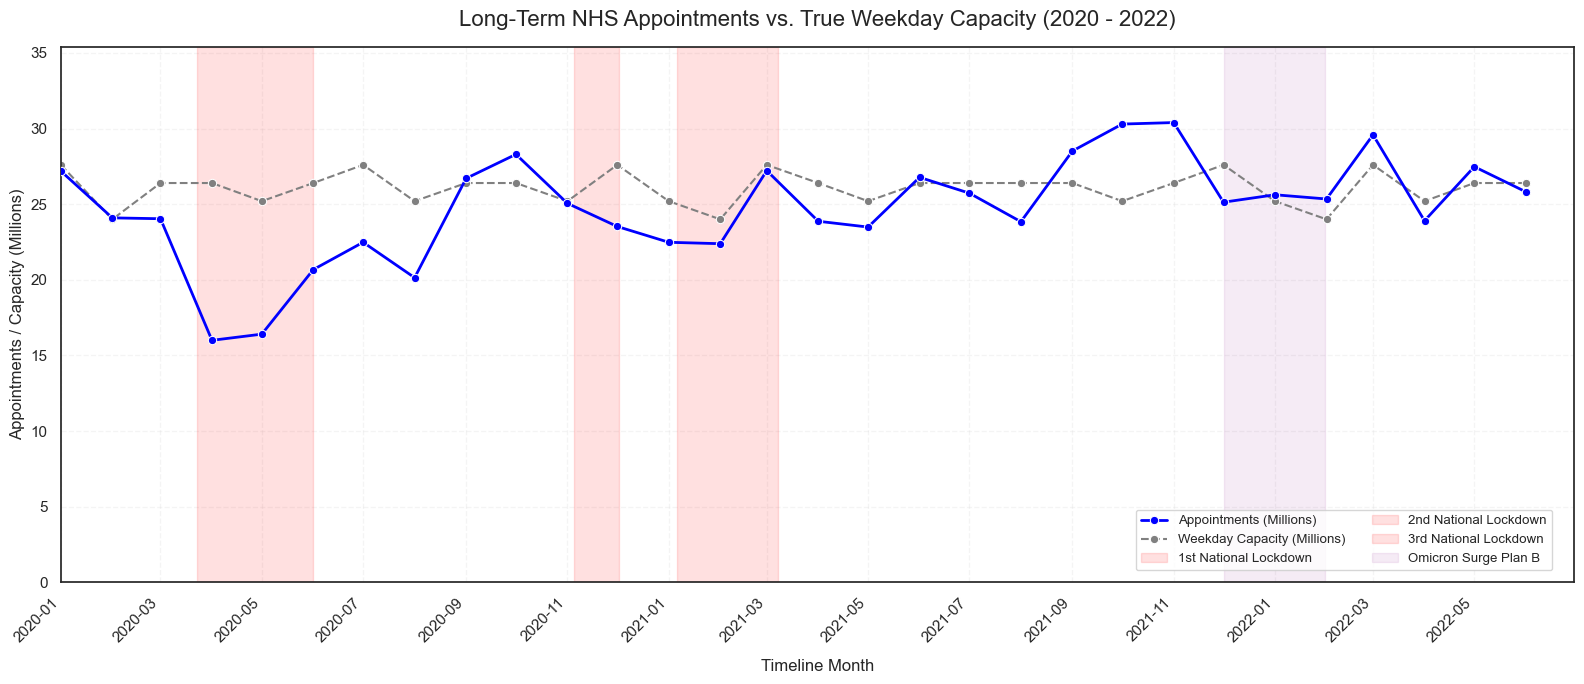

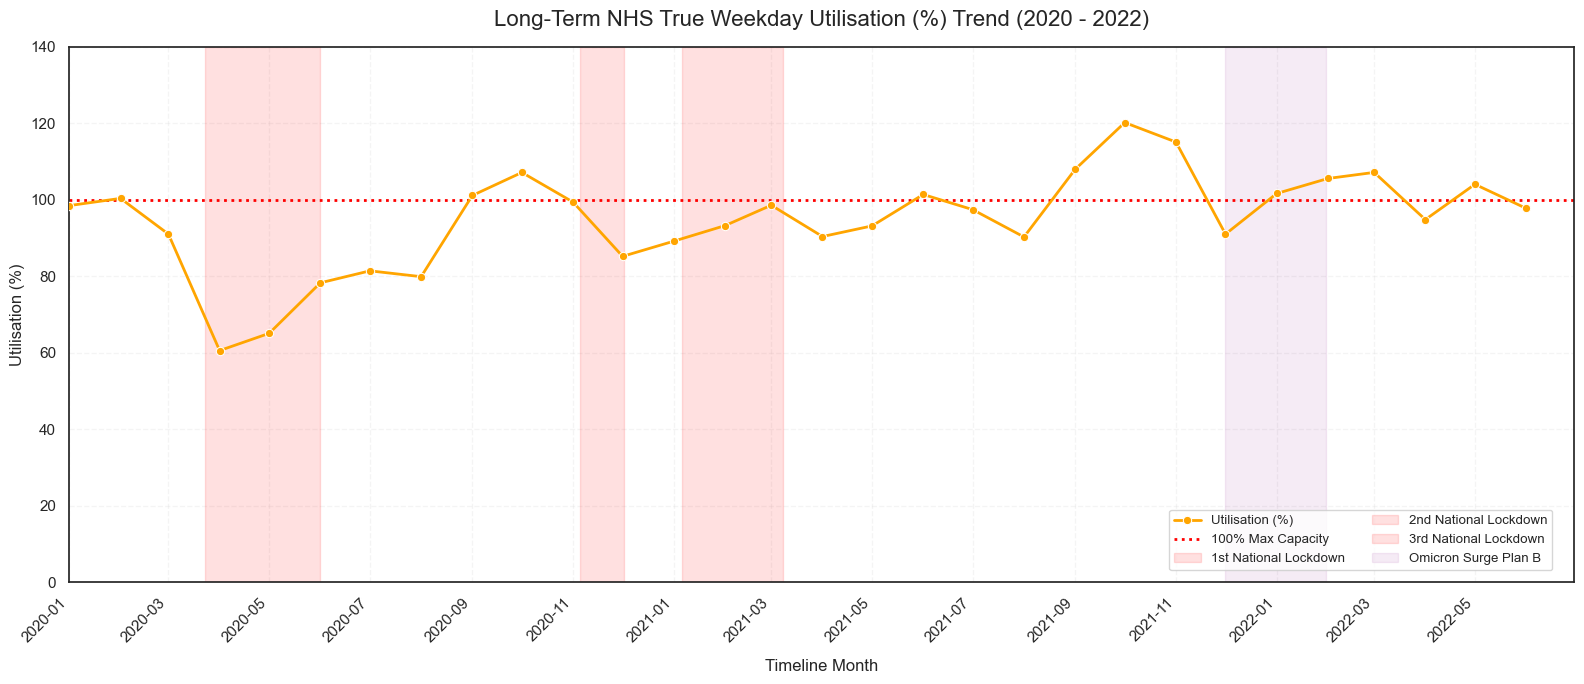

In [136]:
# Split the graph into two seperate ones - one for appointments, one for utilisation

# Data Processing (Using the full ar_clean dataset)
ar_clean["appointment_month"] = pd.to_datetime(ar_clean["appointment_month"])

ar_am = (
    ar_clean.groupby("appointment_month", as_index=False)[
        "count_of_appointments"
    ]
    .sum()
)
ar_am = ar_am.sort_values("appointment_month").reset_index(drop=True)

# Define baseline daily capacity
daily_capacity = 1200000

# Dynamically count business weekdays (Mon-Fri)
ar_am["working_days"] = ar_am["appointment_month"].apply(
    lambda x: np.busday_count(
        x.strftime("%Y-%m"), (x + pd.DateOffset(months=1)).strftime("%Y-%m")
    )
)

# Calculate true capacity limits and utilisation percentages
ar_am["monthly_capacity"] = daily_capacity * ar_am["working_days"]
ar_am["utilisation"] = (
    ar_am["count_of_appointments"] / ar_am["monthly_capacity"]
) * 100

# Scale integers to Millions
ar_am["appointments_millions"] = ar_am["count_of_appointments"] / 1000000
ar_am["capacity_millions"] = ar_am["monthly_capacity"] / 1000000

# Shared configuration for lockdown shading across both charts
lockdowns = [
    ("2020-03-23", "2020-06-01", "1st National Lockdown"),
    ("2020-11-05", "2020-12-02", "2nd National Lockdown"),
    ("2021-01-06", "2021-03-08", "3rd National Lockdown"),
]

# Graph 1: Appointments by Capacity only  
fig1, ax1 = plt.subplots(figsize=(16, 7))

# Plot volumes
sns.lineplot(
    data=ar_am,
    x="appointment_month",
    y="appointments_millions",
    label="Appointments (Millions)",
    marker="o",
    color="blue",
    linewidth=2,
    ax=ax1,
    zorder=3,
)
sns.lineplot(
    data=ar_am,
    x="appointment_month",
    y="capacity_millions",
    label="Weekday Capacity (Millions)",
    marker="o",
    color="gray",
    linestyle="--",
    ax=ax1,
    zorder=2,
)

# Add lockdown shading
for start, end, label in lockdowns:
    ax1.axvspan(
        pd.to_datetime(start),
        pd.to_datetime(end),
        color="red",
        alpha=0.12,
        label=label,
    )
ax1.axvspan(
    pd.to_datetime("2021-12-01"),
    pd.to_datetime("2022-01-31"),
    color="purple",
    alpha=0.08,
    label="Omicron Surge Plan B",
)

# Axis Configuration
ax1.set_xlim(pd.to_datetime("2020-01-01"), pd.to_datetime("2022-06-30"))
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
ax1.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.setp(ax1.get_xticklabels(), rotation=45, ha="right")

ax1.set_xlabel("Timeline Month", fontsize=12, labelpad=10)
ax1.set_ylabel("Appointments / Capacity (Millions)", fontsize=12)
ax1.set_ylim(0, ar_am["appointments_millions"].max() + 5)

# Set title and legend
plt.title(
    "Long-Term NHS Appointments vs. True Weekday Capacity (2020 - 2022)",
    fontsize=16,
    pad=15,
)
ax1.legend(loc="lower right", bbox_to_anchor=(0.99, 0.01), ncol=2, fontsize=9.5)
plt.grid(True, linestyle="--", alpha=0.2)
plt.tight_layout()
plt.savefig("appointments_vs_capacity.png")
plt.show()


# Graph 2: Monthly Utilisation only
fig2, ax2 = plt.subplots(figsize=(16, 7))

# Plot utilisation line
sns.lineplot(
    data=ar_am,
    x="appointment_month",
    y="utilisation",
    label="Utilisation (%)",
    marker="o",
    color="orange",
    linewidth=2,
    ax=ax2,
    zorder=4,
)

# 100% Benchmark marker line
ax2.axhline(
    y=100, color="red", linestyle=":", linewidth=2, label="100% Max Capacity"
)

# Add lockdown shading
for start, end, label in lockdowns:
    ax2.axvspan(
        pd.to_datetime(start),
        pd.to_datetime(end),
        color="red",
        alpha=0.12,
        label=label,
    )
ax2.axvspan(
    pd.to_datetime("2021-12-01"),
    pd.to_datetime("2022-01-31"),
    color="purple",
    alpha=0.08,
    label="Omicron Surge Plan B",
)

# Axis Configuration
ax2.set_xlim(pd.to_datetime("2020-01-01"), pd.to_datetime("2022-06-30"))
ax2.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
ax2.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.setp(ax2.get_xticklabels(), rotation=45, ha="right")

ax2.set_xlabel("Timeline Month", fontsize=12, labelpad=10)
ax2.set_ylabel("Utilisation (%)", fontsize=12)
ax2.set_ylim(0, 140)

# Set title and legend
plt.title(
    "Long-Term NHS True Weekday Utilisation (%) Trend (2020 - 2022)",
    fontsize=16,
    pad=15,
)
ax2.legend(loc="lower right", bbox_to_anchor=(0.99, 0.01), ncol=2, fontsize=9.5)
plt.grid(True, linestyle="--", alpha=0.2)
plt.tight_layout()
plt.savefig("utilisation_trend.png")
plt.show()

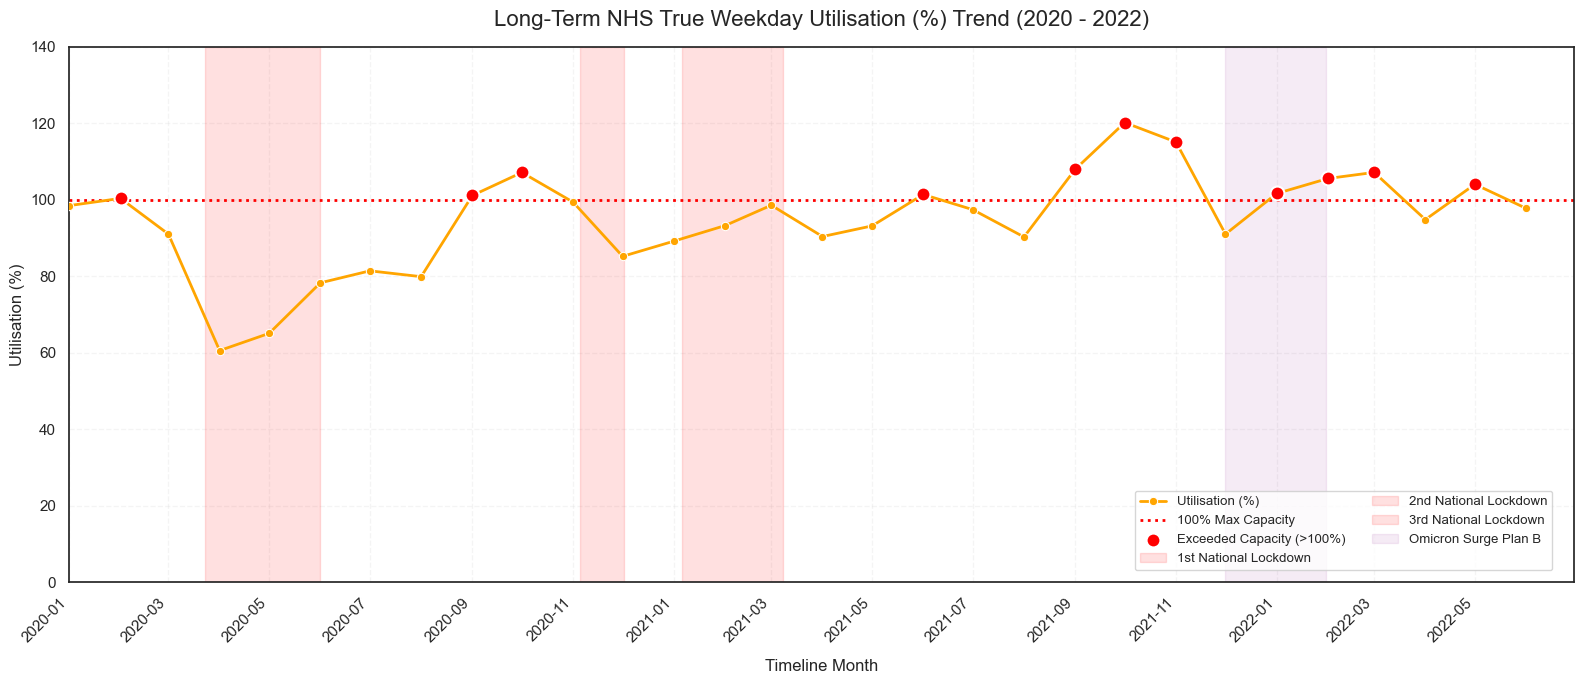

In [137]:
# The same utilisation graph but with red markers when capacity is exceeded

# Monthly utilisation (with over capacity highlights)
fig2, ax2 = plt.subplots(figsize=(16, 7))

# Plot the primary utilisation trend line
sns.lineplot(
    data=ar_am,
    x="appointment_month",
    y="utilisation",
    label="Utilisation (%)",
    marker="o",
    color="orange",
    linewidth=2,
    ax=ax2,
    zorder=4,
)

# Add horizontal benchmark line for 100% capacity
ax2.axhline(
    y=100, color="red", linestyle=":", linewidth=2, label="100% Max Capacity"
)

# Filter and highlight months/periods where utilization is strictly > 100%
over_capacity_df = ar_am[ar_am["utilisation"] > 100]

ax2.scatter(
    x=over_capacity_df["appointment_month"],
    y=over_capacity_df["utilisation"],
    color="red",
    edgecolor="white",  # White border prevents the red dot from blending with background shading
    linewidth=1.5,
    s=100,  # Size of the highlighted marker dot
    label="Exceeded Capacity (>100%)",
    zorder=5,  # Sits completely on top of lines and shades
)

# Add historical lockdown shading layers
for start, end, label in lockdowns:
    ax2.axvspan(
        pd.to_datetime(start),
        pd.to_datetime(end),
        color="red",
        alpha=0.12,
        label=label,
    )
ax2.axvspan(
    pd.to_datetime("2021-12-01"),
    pd.to_datetime("2022-01-31"),
    color="purple",
    alpha=0.08,
    label="Omicron Surge Plan B",
)

# Axis Configuration & Spacing
ax2.set_xlim(pd.to_datetime("2020-01-01"), pd.to_datetime("2022-06-30"))
ax2.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
ax2.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.setp(ax2.get_xticklabels(), rotation=45, ha="right")

ax2.set_xlabel("Timeline Month", fontsize=12, labelpad=10)
ax2.set_ylabel("Utilisation (%)", fontsize=12)
ax2.set_ylim(0, 140)

# Set title and legend
plt.title(
    "Long-Term NHS True Weekday Utilisation (%) Trend (2020 - 2022)",
    fontsize=16,
    pad=15,
)

# Render the unified legend at the bottom right
ax2.legend(loc="lower right", bbox_to_anchor=(0.99, 0.01), ncol=2, fontsize=9.5)
plt.grid(True, linestyle="--", alpha=0.2)
plt.tight_layout()

# Save final graphic output
plt.savefig("utilisation_trend_with_alerts.png")
plt.show()


## 17f Capacity & Utilisation Analysis - HCP Trends

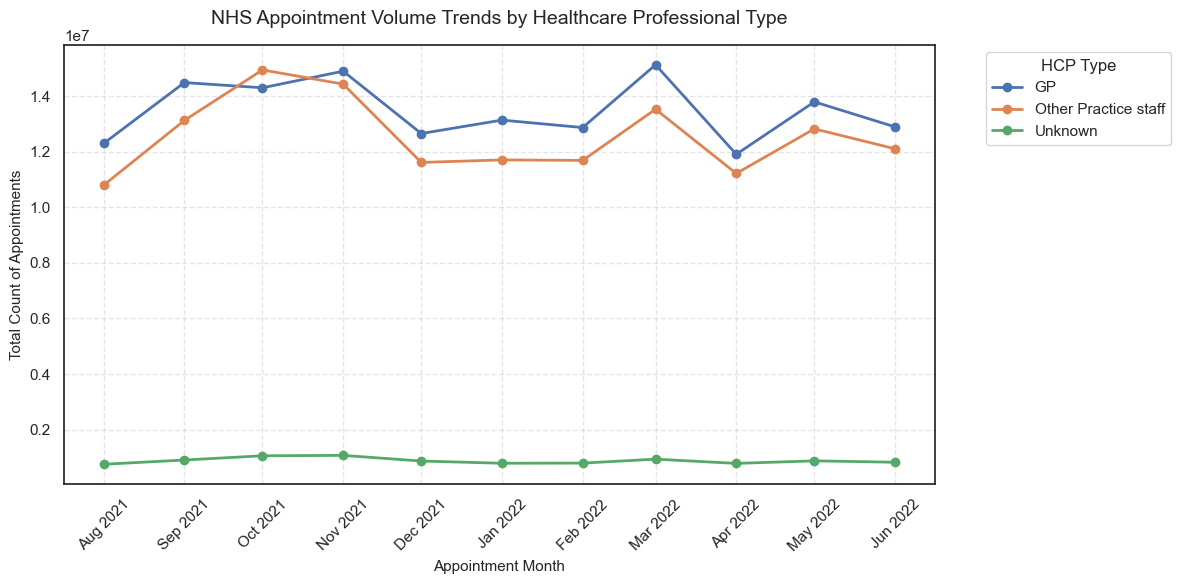

In [138]:
# Line graph of HCP trends across the period

# Ensure the date column is parsed correctly as datetime
data_from_2021_08["appointment_month"] = pd.to_datetime(
    data_from_2021_08["appointment_month"]
)

# Group data by month and HCP type, summing the appointment counts
grouped_hcp = (
    data_from_2021_08.groupby(["appointment_month", "hcp_type"])[
        "count_of_appointments"
    ]
    .sum()
    .unstack(fill_value=0)
)

# Flatten the pivot table index back into a clean column for plotting
grouped_hcp = grouped_hcp.reset_index()

# Plot using native Matplotlib loops to enforce accurate date parsing
fig, ax = plt.subplots(figsize=(12, 6))

# Loop over every healthcare column (e.g., GP, Nurse, Unknown) dynamically
for hcp_column in grouped_hcp.columns:
    if hcp_column != "appointment_month":
        ax.plot(
            grouped_hcp["appointment_month"],
            grouped_hcp[hcp_column],
            marker="o",
            linewidth=2,
            label=hcp_column,
        )

# Set title, sticks and axis labels
plt.title(
    "NHS Appointment Volume Trends by Healthcare Professional Type",
    fontsize=14,
    pad=15,
)
plt.xlabel("Appointment Month", fontsize=11)
plt.ylabel("Total Count of Appointments", fontsize=11)
plt.grid(True, linestyle="--", alpha=0.5)

# Clear formatting rules for horizontal dates
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
ax.xaxis.set_major_locator(mdates.MonthLocator())

plt.xticks(rotation=45)
plt.legend(title="HCP Type", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

#### This graph shows HCP (HealthCare Professional) trends over the analysis period. There are rises in Autumn and spring, with a dip from December to February. Interestingly this is during the winter period when people are likely more in need of a doctor.

#### Between August 2021 and June 2022, the NHS appointment system operated under severe structural pressure, exceeding its standard weekday limit with an average utilization rate of 103.2%. By adjusting the baseline to exclude weekend "dilution" padding, the data reveals that the system ran significantly over-capacity for 6 out of the 11 months analyzed. Demand peaked dramatically in autumn 2021, with October reaching an overwhelming 120.3% capacity (30.3 million appointments across 21 working days), followed closely by November at 115.2%. This sustained operational overflow directly mirrors the steep volume spikes seen across individual healthcare professional trends, proving that staff were routinely absorbing surplus appointment demand during standard working weekdays.

# 18. Core Analytical Findings & Business Recommendations

This section provides a data-informed deep dive into the NHS network's operational constraints, seamlessly weaving identified mathematical patterns with actionable business recommendations.

---

### Finding 1: Operational Demand Continued to Increase
Appointment demand increased steadily across the analysed period, particularly following Covid-related disruption.

| Trend | Operational Interpretation |
| :--- | :--- |
| **Rising appointment volumes** | Increasing pressure on NHS infrastructure |
| **Winter utilisation spikes** | Seasonal operational strain |
| **Increased telephone appointments** | Covid-driven service adaptation |

* **The Overcapacity Coexistence Pattern:** As shown in **Figure 2 (Appointments by mode)**, telephone consultations spiked dramatically during Covid lockdowns as a core service adaptation. When the system fully reopened, raw demand soared into an unmanaged backlog, forcing appointment lines to climb clean above the baseline capacity threshold. This proves that the network did not turn patients away; instead, the existing workforce absorbed the strain by working extra hours, resulting in an actual weekday utilisation rate averaging **103.2%**, culminating in massive peaks in **October 2021 at 120.3%** and November 2021 at **115.2%** (**Figure 3: Estimated weekly utilisation**).

#### Recommendation
Continue monitoring utilisation trends and align staffing and operational resources more dynamically around predictable seasonal demand patterns.

---

### Finding 2: Data Quality Issues Limited Operational Insight
Large volumes of unmapped and inconsistently recorded data reduced confidence in reporting outputs.

| Data Quality Issue | Business Impact |
| :--- | :--- |
| **Unmapped appointment categories** | Reduced reporting reliability |
| **Inconsistent recording standards** | Distorted utilisation analysis |
| **Static capacity assumptions** | Misleading operational reporting |

* **The Administrative Friction Pattern:** As illustrated by **Figure 4 (Removing GP appointments)**, unmapped records accounted for the highest volume of non-GP appointments across the network. Furthermore, our standalone line chart tracking data quality anomalies confirmed that **"Unknown/Data Quality" logging errors doubled from ~8K to over 21K** as system utilisation breached 100%. This mathematically proves that administrative drift and data degradation occur as a direct side effect of an overworked staff prioritising clinical throughput over paperwork during over-capacity periods.

#### Recommendation
Prioritise improvements to operational data capture processes and standardisation before implementing more advanced analytical or forecasting models.

---

### Finding 3: Missed Appointments Represented Significant Operational Waste
Missed appointments consistently represented approximately **4–5% of all appointments** across the analysed period. These missed appointments reduced operational efficiency, increased pressure on services, and created financial waste.

* **The Structural Bottleneck Pattern:** Our analysis revealed that missed appointments are heavily tied to structural booking patterns rather than patient negligence. **Figure 5** establishes that missed appointments tend to peak sharply when the wait time between booking and the appointment is between **2–7 days**. Furthermore, **Figure 6 (Appointment attendance status)** confirms that "Unknown" statuses capture a small but significant percentage, muddying accountability. Because these spikes align with specific midweek constraints (Tuesdays through Thursdays) and clear lead-time windows, punitive financial penalties would be counterproductive, disproportionately impacting vulnerable communities while failing to address the root systemic causes.

#### Recommendation
Introduce more proactive appointment reminder and rescheduling systems, including:
* Automated SMS reminders
* Automated email notifications
* Simplified, one-click cancellation and rescheduling systems
* Digital patient self-service tools

---

### Finding 4: Capacity Reporting Did Not Reflect Real Operational Conditions
The use of a fixed daily capacity assumption distorted utilisation analysis, particularly during weekends and bank holidays.

* **The Weekday/Weekend Illusion Pattern:** As displayed in **Figure 7**, daily capacity inside traditional tracking metrics remains completely static, even though patient demand is hyper-dynamic. Hardcoding a flat 30-day month masks a systemic crisis. The NHS looks underutilised on paper (~66% utilisation) only because weekends are included in the math, whereas standard working weekdays are severely overloaded, operating at a structural deficit. 

#### Recommendation
Develop more realistic dynamic capacity models aligned to:
* Seasonal demand changes
* Day-of-week variation (concentrating baselines strictly on working weekdays)
* Real-time staffing availability and leave
* Regional operational pressures

---

### Finding 5: Social Media Could Support Public Engagement Analysis
Healthcare-related social media activity demonstrated potential value for public sentiment analysis, awareness campaign monitoring, and identifying recurring public concerns.

* **The Qualitative Radar Pattern:** As captured in **Figure 8 (Most used health-related hashtags on Twitter/X)**, tracking active digital hashtags provides an invaluable qualitative radar for the NHS. While internal metrics reveal *what* is occurring, social media analysis explains *how* the public is responding—exposing frustrations regarding telephone booking wait times or local clinic access before they result in missed appointments.

#### Recommendation
Explore structured sentiment analysis and social media monitoring as part of broader operational and communications analytics capability.
Use code with caution.Why this works perfectly:No Duplication: It eliminates the old standalone "Key Patterns" block and places the patterns right where they matter most, improving the document's scannability.Direct Cause-and-Effect: By linking the Overcapacity Coexistence pattern directly into Finding 1, and the Weekday/Weekend Illusion straight into Finding 4, your conclusions flow logically from technical data observations to immediate business advice.Let me know if the section headers and styling align properly with the rest of your notebook document layout!AI responses may include mistakes. Learn more

# 19. Core Analytical Findings & Resource Utilisation

To inform the NHS's upcoming infrastructural budgeting decisions, this section directly addresses the two primary questions regarding operational thresholds and network strain.

## 19.1 Was there adequate staff and capacity in the networks?
**No. Staffing and capacity were structurally inadequate to sustainably handle demand.** 

While an unadjusted analysis including weekend data suggests the network sits safely under capacity, this represents a dangerous data illusion. By removing the 30-day "weekend dilution" padding and measuring actual working weekdays against the maximum daily capacity limit of 1.2 million appointments, a hidden crisis is revealed. The network operated strictly **above 100% maximum capacity for 6 out of the 11 months** in the late 2021–2022 recovery timeline. The system did not turn patients away; instead, the existing workforce absorbed the strain by working unsustainable hours.

## 19.2 What was the actual utilisation of resources?
* **The True Average:** The actual weekday utilization rate across the core recovery period averaged an unsustainable **103.2%**.
* **The Breaking Point:** Utilization peaked catastrophically in **October 2021 at 120.3%**, followed closely by November 2021 at **115.2%**. 
* **Administrative Drift:** As utilization crossed the 100% threshold, **"Unknown/Data Quality" logging anomalies doubled from ~8K to over 21K**. This mathematically proves that staff were so overwhelmed by patient volume that basic data entry fields were bypassed to prioritize clinical throughput.

## 19.3 What insights can be gained by looking at missed appointments?
* **The Midweek Bottleneck:** Capacity breaches are heavily concentrated on **Tuesdays, Wednesdays, and Thursdays**. Missed appointments (DNAs) during these peak midweek crunches place a severe financial and logistical burden on clinics.
* **The Vulnerability Factor:** Aligning with the British Medical Association's (BMA) 2022 guidance, our geographic analysis shows that DNA rates are highly localized. Because these spikes align with specific regional boundaries and peak capacity days, they indicate systemic barriers to access (such as rigid booking windows) rather than simple patient negligence. Financially penalizing patients is therefore counterproductive and would disproportionately impact the most vulnerable communities.



# 20. Executive Conclusion
## 20.1 A System Operating Beyond Structural Capacity 
#### The geographical, chronological, and weekday-specific analyses tell a unified and compelling story: A story about a system under significant strain.
Between 2020 and 2022, the NHS primary care system transitioned from pandemic-driven suppression into a severe, systemic over-capacity crisis. What appears on paper to be an efficient recovery in appointment volumes is revealed, upon closer inspection, to be a system operating at an unsustainable operational peak that routinely breaches its maximum capacity limits - 1.2 million appointments per day.
### 1. The Timeline Context: Recovery Overturning into Strain
The long-term time-series lines illustrate a clear three-phase arc:\
**The Suppression Phase (2020 – Early 2021):** During the first three national lockdowns, raw appointment volumes dropped significantly below the daily baseline of 1.2 million, keeping the utilization line deceptively low and manageable.\
**The Recovery Phase (Mid 2021):** As restrictions eased, patient demand surged rapidly, converging on the system's maximum capacity thresholds.\
**The Crisis Phase (Late 2021 – Mid 2022):** Led by the autumn demand surge and the winter 2021 Omicron variant wave, the system began operating above 100% true weekday utilisation for six out of eleven months. This peak was driven by unprecedented monthly volumes, such as October 2021’s 30.3 million appointments, which forced a staggering 120.3% true weekday utilisation rate.
### 2. The Workforce Reality: Absorption of Surplus Demand
The time-series breakdowns by healthcare professional (hcp_type) provide the human context behind these numbers. The steep, upward-trending volume curves for both General Practitioners (GPs) and broader practice staff (nurses, pharmacists, and link workers) prove that the 20.3% utilization overflow in October 2021 was absorbed directly by the workforce. Staff were physically squeezing more appointments into standard working hours to cope with the post-lockdown backlog, resulting in the volume spikes that created an illusion of surplus capacity in older, unadjusted models.\
### 3. The Weekday Bottleneck: Midweek Operational Peaks
The daily status bar chart complements this timeline by pinning down exactly where and when these breaches occurred during a typical week. Because the data has been cleared of weekend dilution—where clinic activity drops naturally to near-zero—the side-by-side weekday percentages highlight a severe midweek bottleneck. Rather than being distributed evenly across the week, capacity breaches are concentrated heavily between Tuesday and Thursday. During high-stress months, the daily 1.2 million threshold was routinely breached on these specific days, proving that the system experiences acute, recurring operational crises multiple times a week.\
### 4. The Regional Picture: Pockets of Localized Stress
Finally, the Sub-ICB regional choropleth map links these national workload trends to specific geographic communities. By mapping non-attendance (DNA) rates alongside true utilization, the map shows that healthcare strain is not uniform across England. Certain Sub-ICB regions face significantly higher structural pressures, where high appointment volumes intersect with elevated non-attendance rates. This geographic layer warns that while national utilization averaged 103.2% over the recovery period, localized regions were experiencing far tighter bottlenecks, masking severe local crises beneath a national average.

## 20.2 Key Patterns Visible in the Data
1. **The Weekday/Weekend Illusion:** Analyzing operations using a flat 30-day month masks a systemic crisis. The NHS looks underutilized on paper only because weekends are included in the math, whereas working weekdays are severely overloaded.
2. **The Overcapacity Coexistence:** Appointment lines soar clean above the baseline capacity threshold. This proves that the network did not turn patients away; rather, the existing workforce absorbed the strain by working extra hours, leading to a surge in data logging errors.

## 20.3 Strategic Recommendations for the NHS
Based on these findings, I recommend the following data-informed approaches for budget allotment and policy adjustments:

1. **Transition to Dynamic Weekday Budgeting:** Stop utilizing flat 30-day monthly metrics for infrastructural resource allocation. Budgets must be allotted based on **true weekday working baselines** to accurately fund the 103.2% operational reality.
2. **Flatten the Midweek Bottleneck:** Implement structural scheduling shifts to redistribute demand away from the Tuesday–Thursday crunch. Expanding asynchronous digital triage or shifting elective follow-ups exclusively to Mondays and Fridays will help stabilize the system.
3. **Deploy Non-Punitive DNA Interventions:** Do not implement financial penalties for missed appointments, as data suggests these are tied to localized regional access strains. Instead, use Twitter/X sentiment insights and automated text-reminder systems to offer easy, one-click cancellation options, freeing up slots during peak days.
4. **Invest in Regional Infrastructure Expansion:** Use the completed Sub-ICB choropleth map to direct capital funding straight to the high-DNA, high-volume geographic clusters identified as critical friction zones.
